In [13]:
#Testes
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import math
import pyart
from metpy.plots import SkewT, Hodograph
from metpy.units import units
import metpy.calc as mpcalc
import geopandas as gpd
from datetime import datetime, timedelta
from netCDF4 import Dataset

netcdf_file = '/home/jovyan/compartilhado/Paulo/20230811.2/wrfout_d02_2023-08-11_18:00:00'
#radar_file = 'C:/Users/Paulo/Documents/INPE/Radar 202308/share/radar/sdcsc/chapeco/cappi/cappi15l/2023/08/recorte/R13132245_202308120006.nc'
xrds = xr.open_dataset(netcdf_file)
#xrds1 = xr.open_dataset(radar_file)
#xrds1
xrds

<xarray.Dataset> Size: 3GB
Dimensions:                (Time: 1, south_north: 654, west_east: 792,
                            bottom_top: 49, bottom_top_stag: 50,
                            soil_layers_stag: 4, west_east_stag: 793,
                            south_north_stag: 655, seed_dim_stag: 8,
                            snow_layers_stag: 3, snso_layers_stag: 7)
Coordinates:
    XTIME                  (Time) datetime64[ns] 8B ...
    XLAT                   (Time, south_north, west_east) float32 2MB ...
    XLONG                  (Time, south_north, west_east) float32 2MB ...
    XLAT_V                 (Time, south_north_stag, west_east) float32 2MB ...
    XLONG_V                (Time, south_north_stag, west_east) float32 2MB ...
    XLAT_U                 (Time, south_north, west_east_stag) float32 2MB ...
    XLONG_U                (Time, south_north, west_east_stag) float32 2MB ...
Dimensions without coordinates: Time, south_north, west_east, bottom_top,
                                bottom_top_stag, soil_layers_stag,
                                west_east_stag, south_north_stag,
                                seed_dim_stag, snow_layers_stag,
                                snso_layers_stag
Data variables: (12/361)
    Times                  (Time) |S19 19B ...
    LU_INDEX               (Time, south_north, west_east) float32 2MB ...
    ZNU                    (Time, bottom_top) float32 196B ...
    ZNW                    (Time, bottom_top_stag) float32 200B ...
    ZS                     (Time, soil_layers_stag) float32 16B ...
    DZS                    (Time, soil_layers_stag) float32 16B ...
    ...                     ...
    PCB                    (Time, south_north, west_east) float32 2MB ...
    PC                     (Time, south_north, west_east) float32 2MB ...
    LANDMASK               (Time, south_north, west_east) float32 2MB ...
    LAKEMASK               (Time, south_north, west_east) float32 2MB ...
    SST                    (Time, south_north, west_east) float32 2MB ...
    SST_INPUT              (Time, south_north, west_east) float32 2MB ...
Attributes: (12/155)
    TITLE:                            OUTPUT FROM WRF V4.6.1 MODEL
    START_DATE:                      2023-08-11_00:00:00
    SIMULATION_START_DATE:           2023-08-11_00:00:00
    WEST-EAST_GRID_DIMENSION:        793
    SOUTH-NORTH_GRID_DIMENSION:      655
    BOTTOM-TOP_GRID_DIMENSION:       50
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2

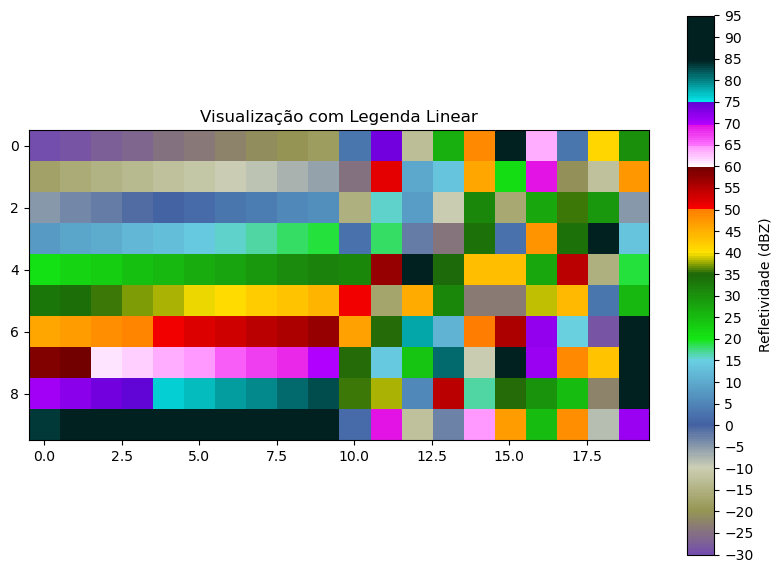

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 1. Seus dados de exemplo com o ajuste mais recente
colors_rgb = [
    [116, 78, 173],   # -30
    [150, 150, 83],   # -20
    [204, 207, 180],  # -10
    [67, 97, 162],    # 0
    [106, 208, 228],  # 15
    [20, 230, 20],    # 20
    [29, 104, 9],     # 35
    [255, 225, 0],    # 40
    [255, 128, 0],    # 49.9
    [255, 0, 0],      # 50
    [113, 0, 0],      # 59.9
    [255, 255, 255],  # 60
    [255, 146, 255],  # 64.9
    [255, 117, 255],  # 65
    [225, 11, 227],   # 69.9
    [178, 0, 255],    # 70
    [99, 0, 214],     # 74.9
    [5, 236, 240],    # 75
    [1, 32, 32],      # 84.9
    [1, 32, 32],      # 85
    [1, 32, 32],      # 95
]

dbz_levels = [-30, -20, -10, 0, 15, 20, 35, 40, 49.9, 50, 59.9, 60, 64.9, 65, 69.9, 70, 74.9, 75, 84.9, 85, 95]


# 2. Normalizar os valores RGB para a escala 0-1
normalized_colors = np.array(colors_rgb) / 255.0

# 3. Normalizar os níveis de dBZ para a escala 0-1
vmin = dbz_levels[0]
vmax = dbz_levels[-1]
norm_levels = (np.array(dbz_levels) - vmin) / (vmax - vmin)

# 4. Criar a lista de tuplas (posição_normalizada, cor)
color_pos_list = list(zip(norm_levels, normalized_colors))

# 5. Criar o colormap segmentado a partir de todos os pontos
final_cmap = LinearSegmentedColormap.from_list('custom_cmap_final_v2', color_pos_list)

# Gerar dados de exemplo para visualização
data = np.zeros((10, 20))
data[0:10,0:10] = np.linspace(vmin, vmax, 100).reshape(10,10)
data[0:10,10:20] = np.random.uniform(vmin, vmax, (10, 10))


# Plotar os dados
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(data, cmap=final_cmap, vmin=vmin, vmax=vmax)
ax.set_title('Visualização com Legenda Linear')

# --- MODIFICAÇÃO AQUI ---
# Adicionar a barra de cores com ticks lineares de 10 em 10

# 1. Criar a lista de ticks desejados
linear_ticks = np.arange(-30, 100, 5)

# 2. Usar a nova lista de ticks na barra de cores
cbar = fig.colorbar(im, ax=ax, ticks=linear_ticks)
cbar.set_label('Refletividade (dBZ)')

plt.savefig("colormap_legenda_linear.png")

In [24]:
# Refletividade WRF
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import geopandas as gpd
import warnings
from matplotlib.cm import get_cmap

# Suprime avisos
warnings.filterwarnings("ignore", category=UserWarning, module='matplotlib')

# --- CONFIGURAÇÕES GERAIS ---
PASTA_WRFOUT = '/home/jovyan/compartilhado/Paulo/20230811.2'
PASTA_SAIDA = '/home/jovyan/privado/Saidas/2023/RefleWRF'
SHP_PATH = '/home/jovyan/privado/SC_Municipios_2023.shp'

# Coordenadas do Radar (Centro do Zoom)
RADAR_LAT = -27.0972
RADAR_LON = -52.6791

# Cria diretório de saída
os.makedirs(PASTA_SAIDA, exist_ok=True)

# Definição de Colormap
try:
    cmap_plot = final_cmap
except ValueError:
    cmap_plot = 'jet' # Fallback

# Carregamento do Shapefile
try:
    gdf_sc = gpd.read_file(SHP_PATH)
except Exception as e:
    print(f"Aviso: Não foi possível carregar o shapefile. Erro: {e}")
    gdf_sc = None

# Limites Globais
vmin_global = -30 
vmax_global = 95

print(f"Iniciando processamento na pasta: {PASTA_WRFOUT}")

for arquivo in os.listdir(PASTA_WRFOUT):
    if arquivo.startswith('wrfout_d02'):
        caminho_arquivo = os.path.join(PASTA_WRFOUT, arquivo)
        print(f"Processando: {arquivo}")

        try:
            xrds = xr.open_dataset(caminho_arquivo)
            
            # --- EXTRAÇÃO DE DATA/HORA ---
            nome_base = os.path.basename(arquivo)
            try:
                parts = nome_base.split('_')
                data_iso = parts[2]
                hora_iso = parts[3]
                data_hora_titulo = f"{hora_iso} UTC {data_iso}"
                timestamp_save = f"{data_iso.replace('-','')}{hora_iso.replace(':','')[0:4]}"
            except IndexError:
                data_hora_titulo = "Data Desconhecida"
                timestamp_save = "unknown"

            # --- LEITURA DAS VARIÁVEIS WRF ---
            # Tempo=0, Nível=20
            refl = xrds['REFL_10CM'][0,10, :, :]
            lat = xrds['XLAT'][0, :, :]
            lon = xrds['XLONG'][0, :, :]
            data_plot = np.ma.masked_less(refl, 0) 

            # --- PLOTAGEM ---
            fig = plt.figure(figsize=(10, 8))
            ax = plt.axes(projection=ccrs.PlateCarree())

            # Plot principal
            mesh = ax.pcolormesh(lon, lat, data_plot, 
                                 transform=ccrs.PlateCarree(),
                                 cmap=cmap_plot, 
                                 vmin=vmin_global, 
                                 vmax=vmax_global,
                                 shading='nearest')

            # --- GEOGRAFIAS ---
            states = cfeature.NaturalEarthFeature(
                category='cultural', name='admin_1_states_provinces_lines',
                scale='10m', facecolor='none'
            )
            ax.add_feature(states, edgecolor='gray', linewidth=0.8, alpha=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.8)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

            if gdf_sc is not None:
                gdf_sc.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)

            # --- PONTO DO RADAR ---
            ax.scatter(RADAR_LON, RADAR_LAT, color='black', s=15, marker='o', 
                       edgecolor='white', linewidth=1.5, zorder=10, 
                       transform=ccrs.PlateCarree())

            # --- ZOOM ---
            ax.set_extent([RADAR_LON - 1, RADAR_LON + 1, 
                           RADAR_LAT - 1, RADAR_LAT + 1], crs=ccrs.PlateCarree())

            # --- COLORBAR ---
            cb = plt.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.9, pad=0.02)
            cb.set_label("Reflectivity (dBZ)")
            cb.set_ticks(np.arange(-30, 95, 10))
            gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.9)
            gl.top_labels = False
            gl.right_labels = False
            # Título
            plt.title(f"WRF Simulated Reflectivity (dBZ)\nArquivo: {nome_base}\nData: {data_hora_titulo}", fontsize=10)

            # Salvar
            output_filename = os.path.join(PASTA_SAIDA, f'WRF_Refl_{timestamp_save}.png')
            plt.savefig(output_filename, dpi=300, bbox_inches='tight')
            plt.close()

            xrds.close()

        except Exception as e:
            print(f"Erro ao processar {arquivo}: {e}")
            import traceback
            traceback.print_exc()

print("\nProcessamento concluído!")

Iniciando processamento na pasta: /home/jovyan/compartilhado/Paulo/20230811.2
Processando: wrfout_d02_2023-08-11_11:00:00
Processando: wrfout_d02_2023-08-12_00:00:00
Processando: wrfout_d02_2023-08-11_07:00:00
Processando: wrfout_d02_2023-08-12_16:00:00
Processando: wrfout_d02_2023-08-11_10:00:00
Processando: wrfout_d02_2023-08-12_01:00:00
Processando: wrfout_d02_2023-08-11_06:00:00
Processando: wrfout_d02_2023-08-12_17:00:00
Processando: wrfout_d02_2023-08-11_13:00:00
Processando: wrfout_d02_2023-08-12_02:00:00
Processando: wrfout_d02_2023-08-12_18:00:00
Processando: wrfout_d02_2023-08-11_05:00:00
Processando: wrfout_d02_2023-08-11_09:00:00
Processando: wrfout_d02_2023-08-12_14:00:00
Processando: wrfout_d02_2023-08-11_12:00:00
Processando: wrfout_d02_2023-08-12_03:00:00
Processando: wrfout_d02_2023-08-11_04:00:00
Processando: wrfout_d02_2023-08-12_15:00:00
Processando: wrfout_d02_2023-08-11_08:00:00
Processando: wrfout_d02_2023-08-12_04:00:00
Processando: wrfout_d02_2023-08-11_19:00:0

In [18]:
import os
import sys
from datetime import datetime
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from netCDF4 import Dataset
import pyart

# --- 1. CONFIGURAÇÕES ---
FRONTEIRAS_DIR = "/home/jovyan/arquivos/"
WRF_DATA_DIR = '/home/jovyan/arquivos/Saidas/20230811.2/'
SHAPE_SC_MUNICIPIOS = os.path.join(FRONTEIRAS_DIR, "SC_Municipios_2023.shp")
OUTPUT_DIR = os.path.join(WRF_DATA_DIR, "precipitacao")
OUTPUT_IMAGE_NAME = "precipitacao_acumulada24-11.png"
#SC_ESTADO_EXTENT = [-54.5, -48.0, -29.5, -25.5], LITORAL_SC_EXTENT = [-50.5, -47.5, -30.0, -25.5]

SC_ESTADO_EXTENT =[-54.5, -48.0, -29.5, -25.5]
CMAP_CHUVA = 'Theodore16'
VMIN = 0
VMAX = 100 

# Período
start_date = datetime(2023, 8, 11, 0, 0, 0)
end_date = datetime(2023, 8, 12, 0, 0, 0)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2. LEITURA DOS DADOS (WRF) ---
print("\n--- Calculando precipitação acumulada ---")
try:
    start_wrf_file_path = os.path.join(WRF_DATA_DIR, f"wrfout_d02_{start_date.strftime('%Y-%m-%d_%H:%M:%S')}")
    end_wrf_file_path = os.path.join(WRF_DATA_DIR, f"wrfout_d02_{end_date.strftime('%Y-%m-%d_%H:%M:%S')}")

    print(f"Lendo inicial: {os.path.basename(start_wrf_file_path)}")
    print(f"Lendo final:   {os.path.basename(end_wrf_file_path)}")

    wrf_start = Dataset(start_wrf_file_path)
    wrf_end = Dataset(end_wrf_file_path)

    # Extrai RAINNC + RAINC (Convectiva + Não Convectiva)
    def get_total_precip(wrf_ds):
        rainnc = wrf_ds.variables['RAINNC'][0, :, :]
        try:
            rainc = wrf_ds.variables['RAINC'][0, :, :]
        except KeyError:
            rainc = np.zeros_like(rainnc)
        return rainnc + rainc

    total_start = get_total_precip(wrf_start)
    total_end = get_total_precip(wrf_end)

    # Acumulado = Final - Inicial
    accum_precip = total_end - total_start
    
    # Coordenadas
    lats = wrf_end.variables['XLAT'][0, :, :]
    lons = wrf_end.variables['XLONG'][0, :, :]
    
    wrf_start.close()
    wrf_end.close()

except Exception as e:
    print(f"Erro fatal na leitura dos dados: {e}")
    sys.exit()

# --- 3. CÁLCULO DO MÁXIMO NA ÁREA DE ZOOM (NP.WHERE) ---
print("--- Calculando máximo na área visível ---")
lon_min, lon_max, lat_min, lat_max = SC_ESTADO_EXTENT

# Cria uma máscara booleana para os pontos dentro do quadrado
mask = (lons >= lon_min) & (lons <= lon_max) & (lats >= lat_min) & (lats <= lat_max)

# Se houver dados dentro do recorte, calcula o max, senão pega o global ou 0
if np.any(mask):
    max_prec_zoom = np.max(accum_precip[mask])
else:
    max_prec_zoom = np.max(accum_precip)

print(f"Máximo no zoom: {max_prec_zoom:.2f} mm")

# --- 4. PLOTAGEM (PADRÃO REQUISITADO) ---
print("--- Gerando o mapa ---")
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent(SC_ESTADO_EXTENT, crs=ccrs.PlateCarree())

# Elementos Geográficos Padronizados
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1.2)
ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor='black', linewidth=1.5, facecolor='none', zorder=5)
ax.add_feature(cfeature.OCEAN, facecolor='#e6f2ff', zorder=0) 

# Shapefile de Municípios (Opcional, mantido do seu código original)
if os.path.exists(SHAPE_SC_MUNICIPIOS):
    try:
        municipios_sc = gpd.read_file(SHAPE_SC_MUNICIPIOS)
        municipios_feature = cfeature.ShapelyFeature(
            municipios_sc.geometry, ccrs.PlateCarree(),
            edgecolor='gray', facecolor='none', linewidth=0.5
        )
        ax.add_feature(municipios_feature, zorder=4)
    except Exception as e:
        print(f"Aviso: Não foi possível carregar shapefile municípios: {e}")

# Mascarar valores baixos para limpeza visual
precip_masked = np.ma.masked_where(accum_precip <= 0.5, accum_precip)

# Plotagem
mapa = ax.pcolormesh(
    lons, lats, precip_masked,
    cmap=CMAP_CHUVA, 
    vmin=VMIN, 
    vmax=VMAX,
    transform=ccrs.PlateCarree(),
    zorder=2,
    shading='nearest'
)

# Grades
gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.6, linewidth=1.2)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 11, "color": "black", "weight": "bold"}
gl.ylabel_style = {"size": 11, "color": "black", "weight": "bold"}

# Barra de Cores
cbar = plt.colorbar(mapa, ax=ax, orientation='vertical', shrink=0.56, pad=0.03)
cbar.set_label('Precipitação Acumulada (mm)', fontsize=12, weight='bold')

# Texto do Valor Máximo (Canto Inferior Direito)
ax.text(0.98, 0.03, f"Máx na área: {max_prec_zoom:.1f} mm", transform=ax.transAxes,
        ha='right', va='bottom', fontsize=12, fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))

# Título
titulo_data = f"De: {start_date.strftime('%d/%m %Hh')} até {end_date.strftime('%d/%m %Hh')}"
ax.set_title(f'Acumulado WRF\n{titulo_data}', fontsize=14, loc='left', weight='bold')

# Salvar
output_path = os.path.join(OUTPUT_DIR, OUTPUT_IMAGE_NAME)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.close(fig)

print(f"--- Salvo em: {output_path} ---")


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119


--- Calculando precipitação acumulada ---
Lendo inicial: wrfout_d02_2023-08-11_00:00:00
Lendo final:   wrfout_d02_2023-08-12_00:00:00
--- Calculando máximo na área visível ---
Máximo no zoom: 81.92 mm
--- Gerando o mapa ---
--- Salvo em: /home/jovyan/arquivos/Saidas/20230811.2/precipitacao/precipitacao_acumulada24-11.png ---


/tmp/ipykernel_935878/1365996744.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=get_cmap("nipy_spectral"), # Um colormap bem colorido para destacar núcleos
/opt/conda/envs/wrf_env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/envs/wrf_env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/envs/wrf_env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultur

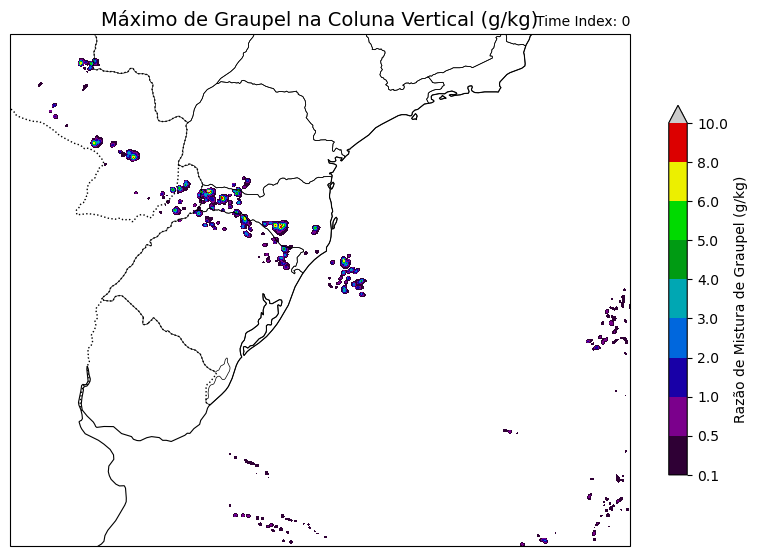

In [8]:
#Graupel
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import cartopy.crs as ccrs
from wrf import (to_np, getvar, latlon_coords, get_cartopy, 
                 cartopy_xlim, cartopy_ylim)
import numpy as np
import pyart

# --- CONFIGURAÇÕES ---
# Caminho do seu arquivo WRF
arquivo_wrf = '/home/jovyan/arquivos/Saidas/20230811.2/wrfout_d02_2023-08-12_07:00:00' 
indice_tempo = 0  # 0 para o primeiro passo de tempo do arquivo

# --- LEITURA DOS DADOS ---
ncfile = Dataset(arquivo_wrf)

# 1. Extrair QGRAUP (Graupel Mixing Ratio)
# A unidade original é kg/kg
qgraup = getvar(ncfile, "QGRAUP", timeidx=indice_tempo)

# 2. Conversão para g/kg (facilita a leitura)
# Valores típicos de tempestade: 1 a 10 g/kg. Abaixo disso é muito pouco.
qgraup_gkg = qgraup * 1000 

# 3. Calcular o MÁXIMO na coluna vertical
# O WRF salva (bottom_top, south_north, west_east). 
# O axis=0 "esmaga" a dimensão vertical pegando o maior valor encontrado.
qgraup_max = np.max(to_np(qgraup_gkg), axis=0)

# 4. Pegar coordenadas para o mapa
lats, lons = latlon_coords(qgraup)
cart_proj = get_cartopy(qgraup)

# --- PLOTAGEM ---
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=cart_proj)

# Adicionar contornos dos estados/países
ax.coastlines(linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, linestyle=':')
ax.add_feature(cartopy.feature.STATES, linewidth=0.5)

# Criar os contornos preenchidos (shading)
# Níveis manuais ajudam a destacar apenas o que importa (ignorando o "ruído" perto de 0)
niveis = [0.1, 0.5, 1, 2, 3, 4, 5, 6, 8, 10]

plt.contourf(to_np(lons), to_np(lats), qgraup_max, 
             levels=niveis,
             transform=ccrs.PlateCarree(),
             cmap=get_cmap("nipy_spectral"), # Um colormap bem colorido para destacar núcleos
             extend='max')

# Barra de cores
plt.colorbar(ax=ax, shrink=.6, label="Razão de Mistura de Graupel (g/kg)")

# Ajustar limites do mapa para o domínio do WRF
ax.set_xlim(cartopy_xlim(qgraup))
ax.set_ylim(cartopy_ylim(qgraup))

# Títulos
plt.title(f"Máximo de Graupel na Coluna Vertical (g/kg)", fontsize=14)
plt.title(f"Time Index: {indice_tempo}", loc='right', fontsize=10)

plt.show()

In [27]:
# CAPE e Cisalhamento (Wind Shear) - Padrão WRF
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import numpy as np
from netCDF4 import Dataset
from wrf import getvar, interplevel, to_np, latlon_coords, get_cartopy, cartopy_xlim, cartopy_ylim
import warnings

# Suprimir avisos de depreciação do Matplotlib/Cartopy
warnings.filterwarnings("ignore")

# --- Configurações de Caminhos ---
pasta = '/home/jovyan/arquivos/Saidas/20230811.2/' 
output_path = '/home/jovyan/arquivos/Saidas/20230811.2/CAPE_WindShear_Zoom/'
shp_path = '/home/jovyan/arquivos/SC_Municipios_2023.shp' # Ajuste o caminho do shapefile se necessário

os.makedirs(output_path, exist_ok=True)

# --- Configurações de Zoom e Localização (Iguais ao código 1) ---
delta = 1.5  
site_lon, site_lat = -52.6791, -27.0972

# --- Carregamento do Shapefile ---
try:
    municipios_reader = shpreader.Reader(shp_path)
    municipios_feature = ShapelyFeature(
        municipios_reader.geometries(),
        ccrs.PlateCarree(),
        edgecolor='black',
        facecolor='none',
        linewidth=0.5,
        alpha=0.8
    )
    print("Shapefile carregado com sucesso.")
except Exception as e:
    print(f"Aviso: Não foi possível carregar o shapefile ({e}). O plot seguirá sem ele.")
    municipios_feature = None

print("Iniciando processamento WRF (Padrão Zoom)...")

for arquivo in sorted(os.listdir(pasta)):
    if arquivo.startswith('wrfout') and not arquivo.endswith('.png'):
        caminho_arquivo = os.path.join(pasta, arquivo)
        print(f"Processando: {arquivo}")

        try:
            ncfile = Dataset(caminho_arquivo)

            # --- 1. Extração de Dados WRF ---
            
            # CAPE 2D (Índice 0 = MCAPE)
            cape_data = getvar(ncfile, "cape_2d", timeidx=0)
            cape = cape_data[0] # MCAPE
            
            # Variáveis para Cisalhamento (Vento e Pressão)
            p = getvar(ncfile, "pressure")
            # 'ua' e 'va' já retornam vento na grade da terra (Earth-relative) em m/s
            ua = getvar(ncfile, "ua", units="kt") # Já pedindo em nós (kt)
            va = getvar(ncfile, "va", units="kt")

            # --- 2. Cálculo do Cisalhamento (Shear) ---
            # Interpolação para níveis de pressão (925 e 700 hPa)
            u_925 = interplevel(ua, p, 925)
            v_925 = interplevel(va, p, 925)
            
            u_700 = interplevel(ua, p, 700)
            v_700 = interplevel(va, p, 700)

            # Cálculo da diferença (Shear 0-3km aprox / 925-700hPa)
            u_shear = u_700 - u_925
            v_shear = v_700 - v_925

            # Coordenadas (Latitude e Longitude)
            lats, lons = latlon_coords(cape)
            
            # Obter projeção do WRF para o mapa
            cart_proj = get_cartopy(cape)
            
            # Extrair data/hora para o título/nome
            # Formato WRF: 2023-08-11_12:00:00
            data_hora_raw = str(cape.Time.values) 
            # Formatação limpa para nome do arquivo
            data_hora_file = data_hora_raw.replace(':', '').replace('-', '').replace('_', '') # Ex: 20230811120000
            
            
            # --- 3. Plotagem (Estilo do Código 1) ---
            fig = plt.figure(figsize=(12, 10))
            ax = plt.axes(projection=cart_proj) # Usa projeção nativa do WRF

            # Definir níveis de CAPE iguais ao código anterior
            levels = np.arange(100, 4200, 100)
            
            # Tenta usar colormap parecido, se 'pyart_LangRainbow12' não existir, usa 'nipy_spectral'
            try:
                cmap = plt.get_cmap('LangRainbow12')
            except ValueError:
                cmap = plt.get_cmap('nipy_spectral') # Fallback colorido

            # Plot Contorno Preenchido (CAPE)
            cape_plot = plt.contourf(to_np(lons), to_np(lats), to_np(cape),
                                     levels=levels,
                                     transform=ccrs.PlateCarree(),
                                     cmap=cmap,
                                     extend='max')
            
            # Barra de cores
            plt.colorbar(cape_plot, ax=ax, label='MCAPE (J/kg)', shrink=0.8)

            # Vetores de Cisalhamento (Barbs)
            # step para não poluir o mapa
            step = 8 
            ax.barbs(to_np(lons)[::step, ::step], to_np(lats)[::step, ::step],
                     to_np(u_shear)[::step, ::step], to_np(v_shear)[::step, ::step],
                     transform=ccrs.PlateCarree(),
                     length=6, color='black', linewidth=0.5)

            # --- 4. Elementos Visuais e Zoom ---
            
            # Shapefile
            if municipios_feature:
                ax.add_feature(municipios_feature)
            else:
                # Fallback se não tiver shapefile
                ax.add_feature(cfeature.COASTLINE)
                ax.add_feature(cfeature.BORDERS)

            # Zoom Específico (Centralizado no radar com delta)
            ax.set_extent([site_lon - delta, site_lon + delta,
                           site_lat - delta, site_lat + delta],
                          crs=ccrs.PlateCarree())

            # Marcador do Local (Estrela Branca)
            ax.plot(site_lon, site_lat, marker='*', markersize=15,
                    color='white', markeredgecolor='black',
                    transform=ccrs.PlateCarree(), zorder=10)

            # Gridlines
            gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.8)
            gl.top_labels = gl.right_labels = False
            gl.xlabel_style = {'size': 10}
            gl.ylabel_style = {'size': 10}

            # Título e Salvamento
            plt.title(f'WRF MCAPE & Shear (700-925hPa) \n {data_hora_raw}')
            
            nome_saida = f'WRF_CAPE_Shear_Zoom_{data_hora_file}.png'
            plt.savefig(os.path.join(output_path, nome_saida), dpi=300, bbox_inches='tight')
            plt.close(fig)

            ncfile.close()

        except Exception as e:
            print(f"Erro ao processar {arquivo}: {e}")
            import traceback
            traceback.print_exc()

print("Processamento concluído.")

ModuleNotFoundError: No module named 'wrf'

In [39]:
#Sondagem Geral
import matplotlib.pyplot as plt
import numpy as np
import metpy.calc as mpcalc
from metpy.units import units
from metpy.plots import SkewT, Hodograph
from netCDF4 import Dataset
import glob
import os
import sys

# ######################################################################
# ### CONFIGURAÇÃO DO USUÁRIO ###
# ######################################################################

# 1. Diretório onde estão os arquivos WRF
INPUT_DIR = '/home/jovyan/privado/Saidas/WRF/20210209 Maravilha/'
# Padrão do nome dos arquivos (ex: wrfout_d02*)
FILE_PATTERN = 'wrfout_d02*'

# 2. Diretório onde as imagens serão salvas
OUTPUT_DIR = '/home/jovyan/privado/Saidas/WRF/Sondagens/20210209 Maravilha'

# 3. Defina a coordenada para a sondagem
TARGET_LAT = -26.4612
TARGET_LON = -53.13

# Cria a pasta de saída se não existir
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ######################################################################

# Listar todos os arquivos e ordenar
files_list = sorted(glob.glob(os.path.join(INPUT_DIR, FILE_PATTERN)))

if not files_list:
    print(f"Nenhum arquivo encontrado em {INPUT_DIR} com o padrão {FILE_PATTERN}")
    sys.exit()

print(f"Encontrados {len(files_list)} arquivos para processar.")

# --- INÍCIO DO LOOP ---
for wrf_file_path in files_list:
    try:
        print(f"\n>>> Processando: {os.path.basename(wrf_file_path)}")
        
        wrf_file = Dataset(wrf_file_path)
        
        # Extrair string de tempo para usar no nome do arquivo
        sim_time_bytes = wrf_file.variables['Times'][0].tobytes()
        sim_time_str = sim_time_bytes.decode().replace("_", " ")
        # Formato seguro para nome de arquivo (sem espaços ou dois pontos)
        file_time_suffix = sim_time_str.replace(" ", "_").replace(":", "-")
        
        # Definir nome de saída dinâmico
        OUTPUT_IMAGE_NAME = os.path.join(OUTPUT_DIR, f"sondagem_{file_time_suffix}.png")

        # --- Encontrando o ponto de grade mais próximo ---
        lats = wrf_file.variables['XLAT'][0, :, :]
        lons = wrf_file.variables['XLONG'][0, :, :]
        dist_sq = (lats - TARGET_LAT)**2 + (lons - TARGET_LON)**2
        min_dist_idx = dist_sq.argmin()
        iy, ix = np.unravel_index(min_dist_idx, lats.shape)
        
        # --- Extraindo os perfis verticais no ponto (iy, ix) ---
        p_base = wrf_file.variables['PB'][0, :, iy, ix]
        p_pert = wrf_file.variables['P'][0, :, iy, ix]
        pressure_np = p_base + p_pert                           # Pa
        theta = wrf_file.variables['T'][0, :, iy, ix] + 300     # potential temperature (K)
        qvapor = wrf_file.variables['QVAPOR'][0, :, iy, ix]
        ph_base = wrf_file.variables['PHB'][0, :, iy, ix]
        ph_pert = wrf_file.variables['PH'][0, :, iy, ix]
        geopotential = ph_base + ph_pert
        height_staggered_agl = (geopotential / 9.81) - (geopotential[0] / 9.81)
        height_mass_agl_np = 0.5 * (height_staggered_agl[:-1] + height_staggered_agl[1:])

        # --- Montando u/v em níveis de massa ---
        u_stag = wrf_file.variables['U'][0, :, iy, ix]
        u_stag_right = wrf_file.variables['U'][0, :, iy, min(ix+1, wrf_file.variables['U'].shape[-1]-1)]
        u_wind_np = 0.5 * (u_stag + u_stag_right)

        v_stag = wrf_file.variables['V'][0, :, iy, ix]
        v_stag_north = wrf_file.variables['V'][0, :, min(iy+1, wrf_file.variables['V'].shape[-2]-1), ix]
        v_wind_np = 0.5 * (v_stag + v_stag_north)

        # --- Adicionando unidades ---
        pressure = units.Quantity(pressure_np, "Pa")
        theta = units.Quantity(theta, "kelvin")
        qvapor = units.Quantity(qvapor, "dimensionless")
        height_mass_agl = units.Quantity(height_mass_agl_np, "m")

        # Temperatura e Ponto de Orvalho
        temperature = mpcalc.temperature_from_potential_temperature(pressure, theta)
        try:
            vapor_pressure = mpcalc.vapor_pressure_from_specific_humidity(pressure, qvapor)
            dewpoint = mpcalc.dewpoint(vapor_pressure)
        except Exception:
            try:
                vapor_pressure = mpcalc.vapor_pressure(pressure, qvapor)
                dewpoint = mpcalc.dewpoint(vapor_pressure)
            except Exception:
                dewpoint = temperature - 10 * units.degC

        u_wind = units.Quantity(u_wind_np, "m/s")
        v_wind = units.Quantity(v_wind_np, "m/s")
        u_wind_kt = u_wind.to('knots')
        v_wind_kt = v_wind.to('knots')

        # Parcel profile
        parcel_prof = mpcalc.parcel_profile(pressure, temperature[0], dewpoint[0])

        # --- Cálculos de Parâmetros (CAPE, CIN, etc) ---
        sbcape, sbcin = mpcalc.cape_cin(pressure, temperature, dewpoint, parcel_prof)
        mlcape, mlcin = mpcalc.mixed_layer_cape_cin(pressure, temperature, dewpoint)
        mucape, mucin = mpcalc.most_unstable_cape_cin(pressure, temperature, dewpoint)

        try:
            ncl_pressure_cape, _ = mpcalc.lfc(pressure, temperature, dewpoint)
            p_3km = np.interp(3000, height_mass_agl.m, pressure.m) * units.Pa
            cape_3km_mask = (pressure <= ncl_pressure_cape) & (pressure >= p_3km)
            if np.any(cape_3km_mask):
                cape_0_3km, _ = mpcalc.cape_cin(pressure[cape_3km_mask], temperature[cape_3km_mask], dewpoint[cape_3km_mask], parcel_prof[cape_3km_mask])
            else:
                cape_0_3km = 0 * units('J/kg')
        except Exception:
            cape_0_3km = 0 * units('J/kg')

        # --- Funções Auxiliares (Lapse Rate, Freezing Level, BWD) ---
        def manual_lapse_rate_pressure(p_prof, t_prof, h_prof, p_bottom, p_top):
            try:
                t_bottom = np.interp(p_bottom, p_prof, t_prof); h_bottom = np.interp(p_bottom, p_prof, h_prof)
                t_top = np.interp(p_top, p_prof, t_prof); h_top = np.interp(p_top, p_prof, h_prof)
                delta_t = t_top - t_bottom; delta_z_km = (h_top - h_bottom) / 1000.0;
                return (-delta_t / delta_z_km) if delta_z_km > 0 else np.nan
            except: return np.nan

        def manual_lapse_rate_height(temperature_q, height_q, h_bottom_m, h_top_m):
            try:
                temp_c = temperature_q.to('degC').m; h_m = height_q.to('m').m
                order = np.argsort(h_m); h_sorted = h_m[order]; t_sorted = temp_c[order]
                t_bottom = np.interp(h_bottom_m, h_sorted, t_sorted)
                t_top = np.interp(h_top_m, h_sorted, t_sorted)
                delta_t = t_top - t_bottom; delta_z_km = (h_top_m - h_bottom_m) / 1000.0
                return (-delta_t / delta_z_km) if delta_z_km > 0 else np.nan
            except Exception: return np.nan

        p_prof_asc = pressure_np[::-1]
        t_prof_asc = temperature.to('degC').m[::-1]
        h_prof_asc = height_mass_agl_np[::-1]
        lr_700_500 = manual_lapse_rate_pressure(p_prof_asc, t_prof_asc, h_prof_asc, 70000, 50000)
        lr_850_500 = manual_lapse_rate_pressure(p_prof_asc, t_prof_asc, h_prof_asc, 85000, 50000)
        lr_0_3km = manual_lapse_rate_height(temperature, height_mass_agl, 0, 3000)
        lr_3_6km = manual_lapse_rate_height(temperature, height_mass_agl, 3000, 6000)

        pw = mpcalc.precipitable_water(pressure, dewpoint).to('mm')

        def compute_freezing_level(temperature_q, heights):
            try:
                t_c = temperature_q.to('degC').m; h_m = heights.to('m').m
                if not np.all(np.diff(h_m) > 0):
                    order = np.argsort(h_m); h_m = h_m[order]; t_c = t_c[order]
                if np.any(np.isclose(t_c, 0.0)): return units.Quantity(h_m[np.where(np.isclose(t_c, 0.0))[0][0]], 'm')
                sign = np.sign(t_c); crossings = np.where(np.diff(sign) != 0)[0]
                if len(crossings) == 0: return np.nan * units.m
                i = crossings[0]; t1, t2 = t_c[i], t_c[i+1]; h1, h2 = h_m[i], h_m[i+1]
                frac = (0.0 - t1) / (t2 - t1); h0 = h1 + frac * (h2 - h1)
                return units.Quantity(h0, 'm')
            except Exception: return np.nan * units.m

        freezing_level_h = compute_freezing_level(temperature, height_mass_agl)

        def interp_scalar_to_height(scalar_q, heights_q, target_h_m):
            try:
                scalar = scalar_q.m; h = heights_q.to('m').m
                if not np.all(np.diff(h) > 0): order = np.argsort(h); h = h[order]; scalar = scalar[order]
                val = np.interp(target_h_m, h, scalar)
                return units.Quantity(val, scalar_q.units)
            except Exception: return np.nan * scalar_q.units

        def compute_bwd(u_q, v_q, heights_q, depth_m):
            try:
                u_sfc = interp_scalar_to_height(u_q, heights_q, 0.0); v_sfc = interp_scalar_to_height(v_q, heights_q, 0.0)
                u_top = interp_scalar_to_height(u_q, heights_q, depth_m); v_top = interp_scalar_to_height(v_q, heights_q, depth_m)
                du = (u_top - u_sfc).to('m/s'); dv = (v_top - v_sfc).to('m/s')
                return mpcalc.wind_speed(du, dv).to('knots')
            except Exception: return np.nan * units.knots

        try: bwd_0_1km = compute_bwd(u_wind, v_wind, height_mass_agl, 1000.0)
        except: bwd_0_1km = np.nan * units.knots
        try: bwd_0_3km = compute_bwd(u_wind, v_wind, height_mass_agl, 3000.0)
        except: bwd_0_3km = np.nan * units.knots
        try: bwd_0_6km = compute_bwd(u_wind, v_wind, height_mass_agl, 6000.0)
        except: bwd_0_6km = np.nan * units.knots

        # --- PLOTAGEM ---
        fig = plt.figure(figsize=(17, 11))
        skew = SkewT(fig, subplot=(1, 2, 1), rotation=35)
        hodo_ax = fig.add_subplot(1, 2, 2)
        fig.subplots_adjust(bottom=0.25)

        # Skew-T
        skew.plot(pressure, temperature, 'r', linewidth=2, label='Temperatura')
        skew.plot(pressure, dewpoint, 'g', linewidth=2, label='Ponto de Orvalho')
        skew.plot_barbs(pressure[::2], u_wind_kt[::2], v_wind_kt[::2])
        skew.plot_dry_adiabats(t0=np.arange(233, 533, 5) * units.K, color='gray', linestyle='-', linewidth=0.5)
        skew.plot_moist_adiabats(color='gray', linestyle='-', linewidth=0.5)
        skew.ax.axvline(0, color='blue', linestyle='--', linewidth=1.2)
        skew.ax.axvline(-20, color='blue', linestyle='--', linewidth=1.2)
        skew.plot(pressure, parcel_prof, 'k', linestyle='--', label='Perfil da Parcela')
        try: ncl_pressure, _ = mpcalc.lfc(pressure, temperature, dewpoint)
        except: ncl_pressure = 0 * units.hPa
        skew.shade_cape(pressure, temperature, parcel_prof, alpha=0.25)
        skew.ax.fill_betweenx(pressure, temperature, parcel_prof, where=pressure >= ncl_pressure, facecolor='blue', alpha=0.25)

        sfc_pressure = pressure[0].to('hPa'); sfc_temperature = temperature[0].to('degC'); sfc_dewpoint = dewpoint[0].to('degC')
        skew.ax.text(sfc_temperature.m + 1, sfc_pressure.m, f'{sfc_temperature.m:.1f}', color='red', fontsize=10, ha='left', va='center_baseline')
        skew.ax.text(sfc_dewpoint.m - 1, sfc_pressure.m, f'{sfc_dewpoint.m:.1f}', color='green', fontsize=10, ha='right', va='center_baseline')
        skew.ax.set_ylim(1000, 100)
        skew.ax.set_xlabel('Temperatura (°C)')
        skew.ax.set_ylabel('Pressão (hPa)')
        skew.ax.set_title(f'Sondagem Vertical - WRF\nLat: {lats[iy, ix]:.2f}, Lon: {lons[iy, ix]:.2f}\n{sim_time_str}', loc='center')
        skew.ax.legend(loc='upper left')
        
        # Labels altitude Skew-T
        target_altitudes_m = np.array([0, 1000, 3000, 6000, 9000, 12000])
        altitude_labels = ['Sfc', '1 km', '3 km', '6 km', '9 km', '12 km']
        pressure_at_altitudes = np.interp(target_altitudes_m, height_mass_agl.m, pressure.m)
        for i, p_level in enumerate(pressure_at_altitudes):
            p_hpa = p_level / 100.
            skew.ax.text(0.01, p_hpa, altitude_labels[i], transform=skew.ax.get_yaxis_transform(), fontsize='small', color='red', ha='left', va='center')

        # Hodógrafa
        mask_10km = height_mass_agl <= 10000 * units.m
        u_10km, v_10km = u_wind[mask_10km], v_wind[mask_10km]
        height_10km = height_mass_agl[mask_10km]
        h = Hodograph(hodo_ax, component_range=60.)
        h.add_grid(increment=10, color='gray', linestyle='--')
        hodo_ax.set_title('Hodógrafa (0-10 km AGL)', loc='center')
        hodo_ax.set_xlabel('Componente U do Vento (m/s)')
        hodo_ax.set_ylabel('Componente V do Vento (m/s)')

        height_levels = [0, 500, 3000, 6000, 10000] * units.m
        colors = ['#FF00FF', '#FF0000', '#00FF00', '#0000FF']
        labels_h = ['0-0.5 km', '0.5-3 km', '3-6 km', '6-10 km']
        for i in range(len(height_levels) - 1):
            lower_bound, upper_bound = height_levels[i], height_levels[i+1]
            current_mask = (height_10km >= lower_bound) & (height_10km <= upper_bound)
            indices = np.where(current_mask)[0]
            if len(indices) == 0: continue
            start_index = max(0, indices[0] - 1)
            plot_indices = range(start_index, indices[-1] + 1)
            h.plot(u_10km[plot_indices], v_10km[plot_indices], color=colors[i], label=labels_h[i], linewidth=2)

        # Bunkers e SRH
        left_mover = None; right_mover = None; mean_wind = None
        try:
            right_mover, left_mover, mean_wind = mpcalc.bunkers_storm_motion(pressure, u_wind, v_wind, height_mass_agl)
            h.plot(right_mover[0], right_mover[1], marker='o', color='blue', markersize=8, label='Right-Mover (RM)')
            h.plot(left_mover[0], left_mover[1], marker='o', color='red', markersize=8, label='Left-Mover (LM)')
            h.plot(mean_wind[0], mean_wind[1], marker='s', color='gray', markersize=8, label='Storm Motion (SM)')
        except Exception: pass

        # SRH calculation and shading (Left Mover logic from your code)
        srh_0_500 = srh_0_1km = srh_0_3km = np.nan * units('m**2 / s**2')
        def _extract_srh_value(res):
            try:
                val = res[0] if isinstance(res, (tuple, list)) else res
                if hasattr(val, 'm') and np.shape(val.m) != (): return units.Quantity(val.m.flatten()[0], val.units)
                return val
            except: return np.nan * units('m**2/s**2')

        if left_mover is not None:
            try:
                lm_u = left_mover[0]; lm_v = left_mover[1]
                h_all = height_mass_agl.to('m').m; u_all = u_wind.to('m/s').m; v_all = v_wind.to('m/s').m
                top_available = float(np.nanmax(h_all))
                depths = [500.0, 1000.0, 3000.0]
                srh_list = []
                for depth_m in depths:
                    use_depth = min(depth_m, top_available)
                    try:
                        res = mpcalc.storm_relative_helicity(height_mass_agl, u_wind, v_wind, bottom=0*units.m, depth=use_depth*units.m, storm_u=lm_u, storm_v=lm_v)
                        srh_list.append(_extract_srh_value(res).to('m**2/s**2'))
                    except: srh_list.append(np.nan * units('m**2/s**2'))
                srh_0_500, srh_0_1km, srh_0_3km = srh_list

                # Shading
                shade_top = min(3000.0, top_available)
                if shade_top > 0:
                    npoints = 120
                    interp_h = np.linspace(0.0, shade_top, npoints)
                    interp_u = np.interp(interp_h, h_all, u_all); interp_v = np.interp(interp_h, h_all, v_all)
                    lm_u_val = lm_u.to('m/s').m; lm_v_val = lm_v.to('m/s').m
                    u_rel = interp_u - lm_u_val; v_rel = interp_v - lm_v_val
                    poly_x = np.concatenate(([0.0], u_rel, [0.0])); poly_y = np.concatenate(([0.0], v_rel, [0.0]))
                    h.plot(units.Quantity(u_rel, 'm/s'), units.Quantity(v_rel, 'm/s'), color='red', linewidth=1.5, alpha=0.9)
                    hodo_ax.fill(poly_x, poly_y, color='red', alpha=0.15, label=f'SRH 0-{int(round(shade_top))} m (LM)')
            except Exception as e: print(f"Aviso: SRH calc falhou: {e}")

        # Storm Motion Text
        try:
            sm_speed = mpcalc.wind_speed(mean_wind[0], mean_wind[1]) if mean_wind is not None else np.nan
            sm_dir = mpcalc.wind_direction(mean_wind[0], mean_wind[1]) if mean_wind is not None else np.nan
            rm_speed = mpcalc.wind_speed(right_mover[0], right_mover[1]) if right_mover is not None else np.nan
            rm_dir = mpcalc.wind_direction(right_mover[0], right_mover[1]) if right_mover is not None else np.nan
            lm_speed = mpcalc.wind_speed(left_mover[0], left_mover[1]) if left_mover is not None else np.nan
            lm_dir = mpcalc.wind_direction(left_mover[0], left_mover[1]) if left_mover is not None else np.nan
            
            # Helper seguro para string formatting
            def safe_val(val): return f"{val.m:.0f}" if hasattr(val, 'm') and not np.isnan(val.m) else "--"
            
            storm_motion_text = (f"SM: {safe_val(sm_dir)}° / {safe_val(sm_speed.to('knots'))} kt\n"
                                 f"RM: {safe_val(rm_dir)}° / {safe_val(rm_speed.to('knots'))} kt\n"
                                 f"LM: {safe_val(lm_dir)}° / {safe_val(lm_speed.to('knots'))} kt")
            hodo_ax.text(0.02, 0.98, storm_motion_text, transform=hodo_ax.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        except: pass
        
        hodo_ax.legend()

        # Texto Final (Params)
        def format_srh_val(srh_q):
            try: return f"{srh_q.to('m**2/s**2').m:.0f}" if (hasattr(srh_q, 'to') and not np.isnan(srh_q.m)) else 'N/A'
            except: return 'N/A'
        
        try:
            params_col1 = (f"SBCAPE: {sbcape.m:.0f} J/kg\nSBCIN: {sbcin.m:.0f} J/kg\nMLCAPE: {mlcape.m:.0f} J/kg\nMLCIN: {mlcin.m:.0f} J/kg\nMUCAPE: {mucape.m:.0f} J/kg\nMUCIN: {mucin.m:.0f} J/kg\nCAPE 0-3km: {cape_0_3km.m:.0f} J/kg")
            params_col2 = (f"PW: {pw.m:.1f} mm\nNível Cong.: {int(round(freezing_level_h.to('m').m)) if hasattr(freezing_level_h, 'm') else 'N/A'} m\nLR 700-500: {lr_700_500:.2f} °C/km\nLR 850-500: {lr_850_500:.2f} °C/km\nLR 0-3km: {lr_0_3km:.2f} °C/km\nLR 3-6km: {lr_3_6km:.2f} °C/km")
            params_col3 = (f"BWD 0-1km: {bwd_0_1km.m:.1f} kt\nBWD 0-3km: {bwd_0_3km.m:.1f} kt\nBWD 0-6km: {bwd_0_6km.m:.1f} kt\n")
            params_col4 = (f"SRH LM 0-500m: {format_srh_val(srh_0_500)} m²/s²\nSRH LM 0-1km:  {format_srh_val(srh_0_1km)} m²/s²\nSRH LM 0-3km:  {format_srh_val(srh_0_3km)} m²/s²\n")

            fig.text(0.5, 0.18, "Parâmetros de Tempestade", ha='center', va='top', fontsize=12, weight='bold')
            fig.text(0.1, 0.02, params_col1, ha='left', va='bottom', fontsize=9, fontfamily='monospace')
            fig.text(0.4, 0.02, params_col2, ha='left', va='bottom', fontsize=9, fontfamily='monospace')
            fig.text(0.7, 0.02, params_col3, ha='left', va='bottom', fontsize=9, fontfamily='monospace')
            fig.text(0.9, 0.02, params_col4, ha='left', va='bottom', fontsize=9, fontfamily='monospace')
        except Exception: pass

        # Salvar e Fechar
        print(f"Salvas em: {OUTPUT_IMAGE_NAME}")
        plt.savefig(OUTPUT_IMAGE_NAME, dpi=300, bbox_inches='tight')
        plt.close(fig) # Importante fechar para liberar memória
        
        wrf_file.close()

    except Exception as e:
        print(f"ERRO ao processar {wrf_file_path}: {e}")
        plt.close('all') # Garante que fecha figuras em caso de erro

print("\n--- Todos os arquivos processados! ---")

Encontrados 19 arquivos para processar.

>>> Processando: wrfout_d02_2021-02-09_00:00:00
Salvas em: /home/jovyan/privado/Saidas/WRF/Sondagens/20210209 Maravilha/sondagem_2021-02-09_00-00-00.png

>>> Processando: wrfout_d02_2021-02-09_01:00:00
Salvas em: /home/jovyan/privado/Saidas/WRF/Sondagens/20210209 Maravilha/sondagem_2021-02-09_01-00-00.png

>>> Processando: wrfout_d02_2021-02-09_02:00:00
Salvas em: /home/jovyan/privado/Saidas/WRF/Sondagens/20210209 Maravilha/sondagem_2021-02-09_02-00-00.png

>>> Processando: wrfout_d02_2021-02-09_03:00:00
Salvas em: /home/jovyan/privado/Saidas/WRF/Sondagens/20210209 Maravilha/sondagem_2021-02-09_03-00-00.png

>>> Processando: wrfout_d02_2021-02-09_04:00:00
Salvas em: /home/jovyan/privado/Saidas/WRF/Sondagens/20210209 Maravilha/sondagem_2021-02-09_04-00-00.png

>>> Processando: wrfout_d02_2021-02-09_05:00:00
Salvas em: /home/jovyan/privado/Saidas/WRF/Sondagens/20210209 Maravilha/sondagem_2021-02-09_05-00-00.png

>>> Processando: wrfout_d02_2021-02

In [ ]:
#Sondagem Unitária
# ######################################################################
# ### CONFIGURAÇÃO DO USUÁRIO ###
# ######################################################################
# 1. Especifique o caminho para o arquivo WRF que você quer analisar
WRF_FILE_PATH = '/home/jovyan/arquivos/Saidas/Muri/wrfout_d02_2025-01-16_10:00:00'

# 2. Defina a coordenada para a sondagem
TARGET_LAT = -27.56
TARGET_LON = -48.71

# 3. Nome do arquivo de saída
OUTPUT_IMAGE_NAME = "/home/jovyan/arquivos/Saidas/Muri/Sondagens/sondagem_e_hodografa_final.png"
# ######################################################################


print(f"--- Abrindo arquivo WRF: {WRF_FILE_PATH} ---")
try:
    wrf_file = Dataset(WRF_FILE_PATH)
except FileNotFoundError:
    print(f"ERRO: Arquivo não encontrado em '{WRF_FILE_PATH}'")
    sys.exit()

# --- Encontrando o ponto de grade mais próximo ---
print(f"--- Encontrando ponto de grade mais próximo de Lat: {TARGET_LAT}, Lon: {TARGET_LON} ---")
lats = wrf_file.variables['XLAT'][0, :, :]
lons = wrf_file.variables['XLONG'][0, :, :]
dist_sq = (lats - TARGET_LAT)**2 + (lons - TARGET_LON)**2
min_dist_idx = dist_sq.argmin()
iy, ix = np.unravel_index(min_dist_idx, lats.shape)
print(f"Ponto de grade mais próximo encontrado em (iy, ix) = ({iy}, {ix})")
print(f"Lat/Lon real do ponto: {lats[iy, ix]:.4f}, {lons[iy, ix]:.4f}")


# --- Extraindo os perfis verticais no ponto (iy, ix) ---
print("--- Extraindo perfis verticais ---")
p_base = wrf_file.variables['PB'][0, :, iy, ix]
p_pert = wrf_file.variables['P'][0, :, iy, ix]
pressure_np = p_base + p_pert                         # Pa
theta = wrf_file.variables['T'][0, :, iy, ix] + 300   # potential temperature (K)
qvapor = wrf_file.variables['QVAPOR'][0, :, iy, ix]
ph_base = wrf_file.variables['PHB'][0, :, iy, ix]
ph_pert = wrf_file.variables['PH'][0, :, iy, ix]
geopotential = ph_base + ph_pert
height_staggered_agl = (geopotential / 9.81) - (geopotential[0] / 9.81)
height_mass_agl_np = 0.5 * (height_staggered_agl[:-1] + height_staggered_agl[1:])

# --- Montando u/v em níveis de massa (interpolação horizontal de pontos staggered) ---
# Observação: U tem dimensão west_east_stag; V tem dimensão south_north_stag.
# Aqui fazemos a média horizontal apropriada para obter vento em pontos de massa.
u_stag = wrf_file.variables['U'][0, :, iy, ix]           # U no ponto (staggered in x)
u_stag_right = wrf_file.variables['U'][0, :, iy, min(ix+1, wrf_file.variables['U'].shape[-1]-1)]
u_wind_np = 0.5 * (u_stag + u_stag_right)

v_stag = wrf_file.variables['V'][0, :, iy, ix]           # V no ponto (staggered in y)
v_stag_north = wrf_file.variables['V'][0, :, min(iy+1, wrf_file.variables['V'].shape[-2]-1), ix]
v_wind_np = 0.5 * (v_stag + v_stag_north)

# --- Adicionando unidades com MetPy/Pint para cálculos e plotagem ---
print("--- Calculando variáveis meteorológicas (T, Td, CAPE) ---")
pressure = units.Quantity(pressure_np, "Pa")
theta = units.Quantity(theta, "kelvin")
qvapor = units.Quantity(qvapor, "dimensionless")
height_mass_agl = units.Quantity(height_mass_agl_np, "m")

# temperatura e ponto de orvalho
temperature = mpcalc.temperature_from_potential_temperature(pressure, theta)
# Cuidado: mpcalc.vapor_pressure espera mixing ratio or similar. Se qvapor é mistura (kg/kg), usamos:
# se qvapor já for mixing ratio (kg/kg) -> e = mpcalc.vapor_pressure_from_mixing_ratio(...)
# Aqui tentamos usar mpcalc.vapor_pressure_from_specific_humidity se disponível; caso contrário usamos aproximação.
try:
    # MetPy possui vapor_pressure_from_specific_humidity em versões recentes
    vapor_pressure = mpcalc.vapor_pressure_from_specific_humidity(pressure, qvapor)
    dewpoint = mpcalc.dewpoint(vapor_pressure)
except Exception:
    # fallback aproximado (se qvapor for mixing ratio kg/kg):
    try:
        vapor_pressure = mpcalc.vapor_pressure(pressure, qvapor)  # tenta a função que você usou originalmente
        dewpoint = mpcalc.dewpoint(vapor_pressure)
    except Exception:
        # último recurso: calcula ponto de orvalho via relação aproximada (não ideal, mas evita crash)
        rh = np.minimum(np.maximum(0.01, 0.5), 1.0)  # placeholder se falhar; mas normalmente não cai aqui
        dewpoint = temperature - 10 * units.degC

u_wind = units.Quantity(u_wind_np, "m/s")
v_wind = units.Quantity(v_wind_np, "m/s")
u_wind_kt = u_wind.to('knots')
v_wind_kt = v_wind.to('knots')

# Parcel profile (parcel from surface)
parcel_prof = mpcalc.parcel_profile(pressure, temperature[0], dewpoint[0])


# --- Bloco de Cálculo de Parâmetros Adicionais ---
print("--- Calculando parâmetros de tempestade ---")
sbcape, sbcin = mpcalc.cape_cin(pressure, temperature, dewpoint, parcel_prof)
mlcape, mlcin = mpcalc.mixed_layer_cape_cin(pressure, temperature, dewpoint)
mucape, mucin = mpcalc.most_unstable_cape_cin(pressure, temperature, dewpoint)

# Cálculo CAPE 0-3 km (garantindo máscaras seguras)
try:
    ncl_pressure_cape, _ = mpcalc.lfc(pressure, temperature, dewpoint)
    p_3km = np.interp(3000, height_mass_agl.m, pressure.m) * units.Pa
    cape_3km_mask = (pressure <= ncl_pressure_cape) & (pressure >= p_3km)
    if np.any(cape_3km_mask):
        cape_0_3km, _ = mpcalc.cape_cin(pressure[cape_3km_mask], temperature[cape_3km_mask], dewpoint[cape_3km_mask], parcel_prof[cape_3km_mask])
    else:
        cape_0_3km = 0 * units('J/kg')
except Exception:
    cape_0_3km = 0 * units('J/kg')


# --- Funções utilitárias para lapse rate, nível de congelamento e interpolação de vento ---
def manual_lapse_rate_pressure(p_prof, t_prof, h_prof, p_bottom, p_top):
    try:
        t_bottom = np.interp(p_bottom, p_prof, t_prof); h_bottom = np.interp(p_bottom, p_prof, h_prof)
        t_top = np.interp(p_top, p_prof, t_prof); h_top = np.interp(p_top, p_prof, h_prof)
        delta_t = t_top - t_bottom; delta_z_km = (h_top - h_bottom) / 1000.0;
        return (-delta_t / delta_z_km) if delta_z_km > 0 else np.nan
    except:
        return np.nan

def manual_lapse_rate_height(temperature_q, height_q, h_bottom_m, h_top_m):
    try:
        temp_c = temperature_q.to('degC').m
        h_m = height_q.to('m').m

        # Ordenar por altura crescente
        order = np.argsort(h_m)
        h_sorted = h_m[order]
        t_sorted = temp_c[order]

        # Interpolação de temperatura nos níveis desejados
        t_bottom = np.interp(h_bottom_m, h_sorted, t_sorted)
        t_top = np.interp(h_top_m, h_sorted, t_sorted)

        delta_t = t_top - t_bottom
        delta_z_km = (h_top_m - h_bottom_m) / 1000.0

        return (-delta_t / delta_z_km) if delta_z_km > 0 else np.nan
    except Exception:
        return np.nan

# --- Lapse rates (mantive seu fluxo) ---
p_prof_asc = pressure_np[::-1]
t_prof_asc = temperature.to('degC').m[::-1]
h_prof_asc = height_mass_agl_np[::-1]
lr_700_500 = manual_lapse_rate_pressure(p_prof_asc, t_prof_asc, h_prof_asc, 70000, 50000)
lr_850_500 = manual_lapse_rate_pressure(p_prof_asc, t_prof_asc, h_prof_asc, 85000, 50000)
lr_0_3km = manual_lapse_rate_height(temperature, height_mass_agl, 0, 3000)
lr_3_6km = manual_lapse_rate_height(temperature, height_mass_agl, 3000, 6000)

pw = mpcalc.precipitable_water(pressure, dewpoint).to('mm')

# --- Cálculo robusto do nível de congelamento ---
def compute_freezing_level(temperature_q, heights):
    """
    temperature_q : Quantity (temperature)
    heights       : Quantity (m) same length as temperature_q
    Returns freezing level in meters (Quantity) or np.nan * units.m se não encontrado/interpolar falhar.
    """
    try:
        t_c = temperature_q.to('degC').m
        h_m = heights.to('m').m
        # garantir monotonicidade crescente em h_m
        if not np.all(np.diff(h_m) > 0):
            # ordenar por altura ascendente
            order = np.argsort(h_m)
            h_m = h_m[order]
            t_c = t_c[order]
        # procurar cruzamento de 0°C
        # se algum ponto exatamente 0:
        if np.any(np.isclose(t_c, 0.0)):
            idx = np.where(np.isclose(t_c, 0.0))[0][0]
            return units.Quantity(h_m[idx], 'm')
        # encontrar índice onde temperatura cruza de positiva para negativa (ou vice-versa)
        sign = np.sign(t_c)
        crossings = np.where(np.diff(sign) != 0)[0]
        if len(crossings) == 0:
            return np.nan * units.m
        i = crossings[0]
        # linear interpolation between i and i+1
        t1, t2 = t_c[i], t_c[i+1]
        h1, h2 = h_m[i], h_m[i+1]
        if (t2 - t1) == 0:
            return units.Quantity((h1+h2)/2.0, 'm')
        frac = (0.0 - t1) / (t2 - t1)
        h0 = h1 + frac * (h2 - h1)
        return units.Quantity(h0, 'm')
    except Exception:
        return np.nan * units.m

freezing_level_h = compute_freezing_level(temperature, height_mass_agl)


# --- Cálculo robusto de Bulk Wind Difference (BWD) por interpolação vertical ---
def interp_scalar_to_height(scalar_q, heights_q, target_h_m):
    """
    Interpola um campo escalar (Quantity) para uma altura target (m). Retorna Quantity com mesma unidade do scalar_q.
    """
    try:
        scalar = scalar_q.m
        h = heights_q.to('m').m
        # garantir monotonicidade em h
        if not np.all(np.diff(h) > 0):
            order = np.argsort(h)
            h = h[order]
            scalar = scalar[order]
        val = np.interp(target_h_m, h, scalar)
        return units.Quantity(val, scalar_q.units)
    except Exception:
        return np.nan * scalar_q.units

def compute_bwd(u_q, v_q, heights_q, depth_m):
    """
    Calcula bulk wind difference (speed) entre superfície (0 m) e depth_m.
    Retorna Quantity em knots.
    """
    try:
        # winds at surface (interpolated at 0 m) and at top (depth_m)
        u_sfc = interp_scalar_to_height(u_q, heights_q, 0.0)
        v_sfc = interp_scalar_to_height(v_q, heights_q, 0.0)
        u_top = interp_scalar_to_height(u_q, heights_q, depth_m)
        v_top = interp_scalar_to_height(v_q, heights_q, depth_m)
        du = (u_top - u_sfc).to('m/s')
        dv = (v_top - v_sfc).to('m/s')
        return mpcalc.wind_speed(du, dv).to('knots')
    except Exception:
        return np.nan * units.knots

# computa BWDs pedidos (0-1km, 0-3km, 0-6km)
try:
    bwd_0_1km = compute_bwd(u_wind, v_wind, height_mass_agl, 1000.0)
except Exception:
    bwd_0_1km = np.nan * units.knots
try:
    bwd_0_3km = compute_bwd(u_wind, v_wind, height_mass_agl, 3000.0)
except Exception:
    bwd_0_3km = np.nan * units.knots
try:
    bwd_0_6km = compute_bwd(u_wind, v_wind, height_mass_agl, 6000.0)
except Exception:
    bwd_0_6km = np.nan * units.knots

# --- Criando a figura (mantive seu layout) ---
fig = plt.figure(figsize=(17, 11))
skew = SkewT(fig, subplot=(1, 2, 1), rotation=35)
hodo_ax = fig.add_subplot(1, 2, 2)
fig.subplots_adjust(bottom=0.25)

# --- Criando o Diagrama Skew-T ---
print("--- Gerando o diagrama Skew-T ---")
skew.plot(pressure, temperature, 'r', linewidth=2, label='Temperatura')
skew.plot(pressure, dewpoint, 'g', linewidth=2, label='Ponto de Orvalho')
wind_skip = 2
skew.plot_barbs(pressure[::wind_skip], u_wind_kt[::wind_skip], v_wind_kt[::wind_skip])
skew.plot_dry_adiabats(t0=np.arange(233, 533, 5) * units.K, color='gray', linestyle='-', linewidth=0.5)
skew.plot_moist_adiabats(color='gray', linestyle='-', linewidth=0.5)
skew.ax.axvline(0, color='blue', linestyle='--', linewidth=1.2)
skew.ax.axvline(-20, color='blue', linestyle='--', linewidth=1.2)
skew.plot(pressure, parcel_prof, 'k', linestyle='--', label='Perfil da Parcela')
try:
    ncl_pressure, _ = mpcalc.lfc(pressure, temperature, dewpoint)
except:
    ncl_pressure = 0 * units.hPa
skew.shade_cape(pressure, temperature, parcel_prof, alpha=0.25)
skew.ax.fill_betweenx(pressure, temperature, parcel_prof, where=pressure >= ncl_pressure, facecolor='blue', alpha=0.25)

sfc_pressure = pressure[0].to('hPa')
sfc_temperature = temperature[0].to('degC')
sfc_dewpoint = dewpoint[0].to('degC')
skew.ax.text(sfc_temperature.m + 1, sfc_pressure.m, f'{sfc_temperature.m:.1f}', color='red', fontsize=10, ha='left', va='center_baseline')
skew.ax.text(sfc_dewpoint.m - 1, sfc_pressure.m, f'{sfc_dewpoint.m:.1f}', color='green', fontsize=10, ha='right', va='center_baseline')
skew.ax.set_ylim(1000, 100)
skew.ax.set_xlabel('Temperatura (°C)')
skew.ax.set_ylabel('Pressão (hPa)')
sim_time_str = wrf_file.variables['Times'][0].tobytes().decode().replace("_", " ")
skew.ax.set_title(f'Sondagem Vertical - WRF\nLat: {lats[iy, ix]:.2f}, Lon: {lons[iy, ix]:.2f}\n{sim_time_str}', loc='center')
skew.ax.legend(loc='upper left')

target_altitudes_m = np.array([0, 1000, 3000, 6000, 9000, 12000])
altitude_labels = ['Sfc', '1 km', '3 km', '6 km', '9 km', '12 km']
pressure_at_altitudes = np.interp(target_altitudes_m, height_mass_agl.m, pressure.m)
for i, p_level in enumerate(pressure_at_altitudes):
    p_hpa = p_level / 100.
    skew.ax.text(0.01, p_hpa, altitude_labels[i], transform=skew.ax.get_yaxis_transform(), fontsize='small', color='red', ha='left', va='center')

# --- Criar a Hodógrafa (corrigido p/ SRH robusto) ---
print("--- Gerando a Hodógrafa ---")
mask_10km = height_mass_agl <= 10000 * units.m
u_10km, v_10km = u_wind[mask_10km], v_wind[mask_10km]
height_10km = height_mass_agl[mask_10km]
h = Hodograph(hodo_ax, component_range=60.)
h.add_grid(increment=10, color='gray', linestyle='--')
hodo_ax.set_title('Hodógrafa (0-10 km AGL)', loc='center')
hodo_ax.set_xlabel('Componente U do Vento (m/s)')
hodo_ax.set_ylabel('Componente V do Vento (m/s)')

# segmentos coloridos por camada (mantive seu estilo)
height_levels = [0, 500, 3000, 6000, 10000] * units.m
colors = ['#FF00FF', '#FF0000', '#00FF00', '#0000FF']
labels = ['0-0.5 km', '0.5-3 km', '3-6 km', '6-10 km']
for i in range(len(height_levels) - 1):
    lower_bound, upper_bound = height_levels[i], height_levels[i+1]
    current_mask = (height_10km >= lower_bound) & (height_10km <= upper_bound)
    indices = np.where(current_mask)[0]
    if len(indices) == 0:
        continue
    start_index = max(0, indices[0] - 1)
    plot_indices = range(start_index, indices[-1] + 1)
    h.plot(u_10km[plot_indices], v_10km[plot_indices],
           color=colors[i], label=labels[i], linewidth=2)

# bunkers (storm motions)
left_mover = None
right_mover = None
mean_wind = None
try:
    right_mover, left_mover, mean_wind = mpcalc.bunkers_storm_motion(pressure, u_wind, v_wind, height_mass_agl)
    h.plot(right_mover[0], right_mover[1], marker='o', color='blue', markersize=8, label='Right-Mover (RM)')
    h.plot(left_mover[0], left_mover[1], marker='o', color='red', markersize=8, label='Left-Mover (LM)')
    h.plot(mean_wind[0], mean_wind[1], marker='s', color='gray', markersize=8, label='Storm Motion (SM)')
except Exception as e:
    print(f"Aviso: bunkers_storm_motion falhou: {e}")

# inicializa variáveis para garantir existência posterior
srh_0_500 = srh_0_1km = srh_0_3km = np.nan * units('m**2 / s**2')

# helper para extrair escalar do retorno de mpcalc.storm_relative_helicity
def _extract_srh_value(res):
    """Res pode ser scalar Quantity ou tuple (srh, ...). Retorna Quantity escalar srh."""
    try:
        if isinstance(res, tuple) or isinstance(res, list):
            val = res[0]
        else:
            val = res
        # se ainda for array, tentamos pegar escalar
        if hasattr(val, 'm') and np.shape(val.m) != ():
            # pega primeiro elemento se for array
            return units.Quantity(val.m.flatten()[0], val.units)
        return val
    except Exception:
        try:
            # último recurso: converter em Quantity (zero)
            return units.Quantity(float(res), 'm**2/s**2')
        except Exception:
            return np.nan * units('m**2/s**2')

if left_mover is not None:
    try:
        lm_u = left_mover[0]
        lm_v = left_mover[1]

        # alturas e winds como arrays float (metros / m/s)
        h_all = height_mass_agl.to('m').m
        u_all = u_wind.to('m/s').m
        v_all = v_wind.to('m/s').m

        # --- calcula SRH até as profundidades requisitadas, mas limitando ao topo disponível ---
        top_available = float(np.nanmax(h_all))
        # depth requests
        depths = [500.0, 1000.0, 3000.0]  # m
        srh_list = []
        for depth_m in depths:
            use_depth = min(depth_m, top_available)
            try:
                res = mpcalc.storm_relative_helicity(height_mass_agl, u_wind, v_wind,
                                                     bottom=0 * units.m, depth=use_depth * units.m,
                                                     storm_u=lm_u, storm_v=lm_v)
                srh_val = _extract_srh_value(res)
                # se depth foi limitado, srh_val é válido para o que foi possível
                srh_list.append(srh_val.to('m**2/s**2'))
            except Exception as e:
                print(f"Aviso: srh depth={depth_m} m falhou: {e}")
                srh_list.append(np.nan * units('m**2/s**2'))

        srh_0_500, srh_0_1km, srh_0_3km = srh_list

        # --- agora faz o sombreamento: usamos o topo realmente disponível (até min(3000, top_available)) ---
        shade_top = min(3000.0, top_available)
        if shade_top > 0:
            # grade fina para polígono
            npoints = 120
            interp_h = np.linspace(0.0, shade_top, npoints)
            interp_u = np.interp(interp_h, h_all, u_all)
            interp_v = np.interp(interp_h, h_all, v_all)

            # subtrai o movimento do left mover (em m/s float)
            lm_u_val = lm_u.to('m/s').m if hasattr(lm_u, 'to') else float(lm_u)
            lm_v_val = lm_v.to('m/s').m if hasattr(lm_v, 'to') else float(lm_v)
            u_rel = interp_u - lm_u_val
            v_rel = interp_v - lm_v_val

            # polígono (fecha no 0,0)
            poly_x = np.concatenate(([0.0], u_rel, [0.0]))
            poly_y = np.concatenate(([0.0], v_rel, [0.0]))

            # desenha a curva storm-relative e preenche polígono
            h.plot(units.Quantity(u_rel, 'm/s'), units.Quantity(v_rel, 'm/s'), color='red', linewidth=1.5, alpha=0.9)
            # ax.fill requer números simples (sem units), convertimos para floats em m/s
            hodo_ax.fill(poly_x, poly_y, color='red', alpha=0.15, label=f'SRH 0-{int(round(shade_top))} m (LM)')
        else:
            print("Aviso: topo do perfil é <= 0 m — não é possível sombrear SRH.")
    except Exception as e:
        print(f"Aviso: cálculo ou plot de SRH falhou: {e}")
else:
    print("Aviso: left_mover não disponível — SRH LM não foi calculado.")

# texto com movimentos (mantive formato)
try:
    if mean_wind is not None:
        sm_speed, sm_dir = mpcalc.wind_speed(mean_wind[0], mean_wind[1]), mpcalc.wind_direction(mean_wind[0], mean_wind[1])
    else:
        sm_speed = sm_dir = units.Quantity(np.nan, 'degree')
    if right_mover is not None:
        rm_speed, rm_dir = mpcalc.wind_speed(right_mover[0], right_mover[1]), mpcalc.wind_direction(right_mover[0], right_mover[1])
    else:
        rm_speed = rm_dir = units.Quantity(np.nan, 'degree')
    if left_mover is not None:
        lm_speed, lm_dir = mpcalc.wind_speed(left_mover[0], left_mover[1]), mpcalc.wind_direction(left_mover[0], left_mover[1])
    else:
        lm_speed = lm_dir = units.Quantity(np.nan, 'degree')

    storm_motion_text = (f"SM: {sm_dir.m:.0f}° / {sm_speed.to('knots').m:.0f} kt\n"
                         f"RM: {rm_dir.m:.0f}° / {rm_speed.to('knots').m:.0f} kt\n"
                         f"LM: {lm_dir.m:.0f}° / {lm_speed.to('knots').m:.0f} kt")
    hodo_ax.text(0.02, 0.98, storm_motion_text, transform=hodo_ax.transAxes,
                 fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
except Exception:
    pass

hodo_ax.legend()

def format_srh_val(srh_q):
    try:
        if srh_q is None:
            return 'N/A'
        # srh_q pode ser Quantity ou np.nan
        if hasattr(srh_q, 'to'):
            val = srh_q.to('m**2/s**2').m
            if np.isnan(val):
                return 'N/A'
            return f"{val:.0f}"
        else:
            # fallback
            return f"{float(srh_q):.0f}"
    except Exception:
        return 'N/A'

# --- Adicionar texto com parâmetros abaixo dos gráficos ---
try:
    params_col1 = (f"SBCAPE: {sbcape.m:.0f} J/kg\n"
                   f"SBCIN: {sbcin.m:.0f} J/kg\n"
                   f"MLCAPE: {mlcape.m:.0f} J/kg\n"
                   f"MLCIN: {mlcin.m:.0f} J/kg\n"
                   f"MUCAPE: {mucape.m:.0f} J/kg\n"
                   f"MUCIN: {mucin.m:.0f} J/kg\n"
                   f"CAPE 0-3km: {cape_0_3km.m:.0f} J/kg")

    params_col2 = (f"PW: {pw.m:.1f} mm\n"
                   f"Nível Cong.: {int(round(freezing_level_h.to('m').m)) if hasattr(freezing_level_h, 'm') else 'N/A'} m\n"
                   f"LR 700-500: {lr_700_500:.2f} °C/km\n"
                   f"LR 850-500: {lr_850_500:.2f} °C/km\n"
                   f"LR 0-3km: {lr_0_3km:.2f} °C/km\n"
                   f"LR 3-6km: {lr_3_6km:.2f} °C/km")

    params_col3 = (f"BWD 0-1km: {bwd_0_1km.m:.1f} kt\n"
                   f"BWD 0-3km: {bwd_0_3km.m:.1f} kt\n"
                   f"BWD 0-6km: {bwd_0_6km.m:.1f} kt\n")
    
    params_col4 = (f"SRH LM 0-500m: {format_srh_val(srh_0_500)} m²/s²\n"
                   f"SRH LM 0-1km:  {format_srh_val(srh_0_1km)} m²/s²\n"
                   f"SRH LM 0-3km:  {format_srh_val(srh_0_3km)} m²/s²\n")


    fig.text(0.5, 0.18, "Parâmetros de Tempestade", ha='center', va='top', fontsize=12, weight='bold')
    fig.text(0.1, 0.02, params_col1, ha='left', va='bottom', fontsize=9, fontfamily='monospace')
    fig.text(0.4, 0.02, params_col2, ha='left', va='bottom', fontsize=9, fontfamily='monospace')
    fig.text(0.7, 0.02, params_col3, ha='left', va='bottom', fontsize=9, fontfamily='monospace')
    fig.text(0.9, 0.02, params_col4, ha='left', va='bottom', fontsize=9, fontfamily='monospace')
except Exception as e:
    print(f"Aviso: Não foi possível plotar o painel de parâmetros. Erro: {e}")

print(f"--- Salvando imagem em: {OUTPUT_IMAGE_NAME} ---")
plt.savefig(OUTPUT_IMAGE_NAME, dpi=300, bbox_inches='tight')
plt.close(fig)

print("\n--- Processo finalizado com sucesso! ---")

In [9]:
#Temperatura
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pyart
from matplotlib.cm import get_cmap # Import necessário para o pyart colormap
from matplotlib.ticker import FuncFormatter # Import necessário que estava faltando

# Caminho para a pasta que contém os arquivos .nc
pasta = '/home/jovyan/compartilhado/Paulo/20230811.2/'

# Caminho para a pasta onde os gráficos serão salvos
output_path = '/home/jovyan/privado/Saidas/2023/T2M/'
os.makedirs(output_path, exist_ok=True)

# Valores para escala de temperatura (°C)
vmin_global = -5
vmax_global = 35

for arquivo in os.listdir(pasta):
    if arquivo.startswith('wrfout_d02'):
        caminho_arquivo = os.path.join(pasta, arquivo)

        # Extrair a data e hora do nome do arquivo (formato AAMMDDHH)
        nome_arquivo = os.path.basename(arquivo)
        # Lógica para extrair a data/hora do nome do arquivo
        try:
            partes_nome = arquivo.split('_')
            data_hora = f"{partes_nome[2]}_{partes_nome[3]}"
        except IndexError:
            data_hora = os.path.splitext(arquivo)[0]


        xrds = xr.open_dataset(caminho_arquivo)
        
        # --- CORREÇÃO APLICADA AQUI ---
        # Seleciona o primeiro passo de tempo para todas as variáveis
        t2m = xrds['T2'][0, :, :] - 273.15  # Converter de Kelvin para Celsius
        lat = xrds['XLAT'][0, :, :]
        lon = xrds['XLONG'][0, :, :]
        # -----------------------------

        plt.figure(figsize=(10, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())

        # Paleta de cores apropriada para temperatura
        cmap = get_cmap('Theodore16') # Nome correto do colormap
        levels = np.arange(vmin_global, vmax_global + 1, 1)

        temp_plot = ax.contourf(
            lon, lat, t2m,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            levels=levels,
            extend='both',
            alpha=0.9
        )

        cbar = plt.colorbar(temp_plot, label='Temperatura a 2m (°C)')
        cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}'))

        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')

        estados = cfeature.NaturalEarthFeature(
            category='cultural',
            name='admin_1_states_provinces_lines',
            scale='10m',
            facecolor='none'
        )
        ax.add_feature(estados, edgecolor='black', linewidth=1)

        #ax.set_extent([-60, -42, -37.5, -22.5], crs=ccrs.PlateCarree())

        # Adicionar rótulos de latitude e longitude
        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10, "color": "black"}
        gl.ylabel_style = {"size": 10, "color": "black"}

        plt.title(f'Temperatura a 2m - {data_hora}')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')

        output_filename = os.path.join(output_path, f'T2M_{data_hora}.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close()

        xrds.close()

print("\nProcessamento concluído!")

sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
s


Processamento concluído!


In [ ]:
#Advecção de umidade
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from netCDF4 import Dataset
from wrf import getvar, interplevel, latlon_coords, get_cartopy, to_np

# --- Configurações ---
pasta = '/home/jovyan/arquivos/Saidas/20250115/chem'
output_path = '/home/jovyan/arquivos/Saidas/20250115/chem/Adveccao_Vetores/'
os.makedirs(output_path, exist_ok=True)
skip = 38

print("Iniciando cálculo de Advecção com Vetores de Fluxo...")

for arquivo in sorted(os.listdir(pasta)):
    if arquivo.startswith('wrfout') and not arquivo.endswith('.png'):
        caminho_arquivo = os.path.join(pasta, arquivo)
        print(f"Processando: {arquivo}")

        try:
            ncfile = Dataset(caminho_arquivo)
            
            # 1. Variáveis básicas
            p = getvar(ncfile, "pressure")
            uv = getvar(ncfile, "uvmet")
            ua, va = uv[0], uv[1]
            qvapor = getvar(ncfile, "QVAPOR")
            
            # 2. Interpolação para 850 hPa
            u_850 = interplevel(ua, p, 850)
            v_850 = interplevel(va, p, 850)
            q_850 = interplevel(qvapor, p, 850)
            
            # 3. Cálculo da Advecção
            dx = ncfile.DX
            dy = ncfile.DY
            q_grad_y, q_grad_x = np.gradient(q_850 * 1000) # g/kg
            q_grad_x = q_grad_x / dx
            q_grad_y = q_grad_y / dy
            
            adv_umidade = - (u_850 * q_grad_x + v_850 * q_grad_y) * 100000

            # 4. Cálculo do Fluxo
            fluxo_u = u_850 * (q_850 * 1000)
            fluxo_v = v_850 * (q_850 * 1000)

            # --- Plotagem ---
            lats, lons = latlon_coords(q_850)
            cart_proj = get_cartopy(q_850)
            
            fig = plt.figure(figsize=(12, 10))
            ax = plt.axes(projection=cart_proj)

            #  Sombreado
            levels_adv = np.linspace(-100, 100, 51)
            cf = plt.contourf(to_np(lons), to_np(lats), to_np(adv_umidade),
                              levels=levels_adv, cmap='RdBu_r', extend='both',
                              transform=ccrs.PlateCarree())
            
            cbar = plt.colorbar(cf, ax=ax, shrink=0.8, pad=0.05, 
                                label='Advecção de Umidade ($10^{-5}$ g/kg/s)')

            Q = ax.quiver(to_np(lons)[::skip, ::skip], to_np(lats)[::skip, ::skip],
                          to_np(fluxo_u)[::skip, ::skip], to_np(fluxo_v)[::skip, ::skip],
                          transform=ccrs.PlateCarree(),
                          scale=3000, # Escala ajustada para zoom
                          width=0.005, # Vetores levemente mais grossos
                          headwidth=3,
                          color='black',
                          alpha=0.9)

            ax.quiverkey(Q, 0.9, 1.02, 200, r'$200 \frac{g}{kg} \cdot \frac{m}{s}$', labelpos='E', coordinates='axes')

            # --- MAPA BASE E ESTADOS ---
            ax.coastlines('10m', linewidth=1.5) # Linha de costa mais grossa
            
            # Adiciona os estados com destaque
            estados = cfeature.NaturalEarthFeature(
                category='cultural', 
                name='admin_1_states_provinces_lines', 
                scale='10m', 
                facecolor='none'
            )
            ax.add_feature(estados, edgecolor='black', linewidth=1.2, linestyle='-')
            ax.set_extent([-51.5, -47.0, -30.0, -25.0], crs=ccrs.PlateCarree())
            
            # Título
            data_hora = str(q_850.Time.values)
            plt.title(f"Advecção e Fluxo de Umidade (850hPa) - Litoral SC\n{data_hora}")
            
            plt.savefig(f"{output_path}/Fluxo_SC_{arquivo}.png", bbox_inches='tight', dpi=300)
            plt.close(fig)

            ncfile.close()

        except Exception as e:
            print(f"Erro em {arquivo}: {e}")

print("Processamento concluído.")

Iniciando cálculo de Advecção com Vetores de Fluxo...
Processando: wrfout_d02_2025-01-16_00:00:00


sh: 1: getfattr: not found


Processando: wrfout_d02_2025-01-16_01:00:00


sh: 1: getfattr: not found


Processando: wrfout_d02_2025-01-16_02:00:00


...

sh: 1: getfattr: not found


Processando: wrfout_d02_2025-01-16_08:00:00


sh: 1: getfattr: not found


Processando: wrfout_d02_2025-01-16_09:00:00


sh: 1: getfattr: not found


In [ ]:
#Velocidade vertical 
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from netCDF4 import Dataset
from wrf import getvar, interplevel, latlon_coords, get_cartopy, to_np, cartopy_xlim, cartopy_ylim

# --- Configurações ---
pasta = '/home/jovyan/arquivos/Saidas/20250115chem/'
output_path = '/home/jovyan/arquivos/Saidas/20250115chem/Velocidade_Vertical/'
os.makedirs(output_path, exist_ok=True)

print("Iniciando plotagem de Velocidade Vertical (W)...")

for arquivo in sorted(os.listdir(pasta)):
    if arquivo.startswith('wrfout') and not arquivo.endswith('.png'):
        caminho_arquivo = os.path.join(pasta, arquivo)
        print(f"Lendo: {arquivo}")

        try:
            ncfile = Dataset(caminho_arquivo)

            # 1. Variáveis
            # "wa" é a velocidade vertical (W-component) no centro da grade
            wa = getvar(ncfile, "wa", units="m s-1")
            p = getvar(ncfile, "pressure")
            
            # 2. Escolha do Nível
            # Se quiser o mais próximo do chão possível sem ser zero, use wa[0,:,:]
            # Mas 850 hPa é muito mais informativo para meteorologia sinótica/mesoescala
            w_850 = interplevel(wa, p, 850)

            # --- Plotagem ---
            lats, lons = latlon_coords(w_850)
            cart_proj = get_cartopy(w_850)
            
            fig = plt.figure(figsize=(10, 8))
            ax = plt.axes(projection=cart_proj)

            # A. Sombreado
            # IMPORTANTE: Escala simétrica centrada em zero para diferenciar subida e descida
            # Vermelho = Sobe (+), Azul = Desce (-)
            limit = 2.50 # Limite de m/s (ajuste para 2.0 ou 5.0 se for tempestade severa)
            levels_w = np.linspace(-limit, limit, 41) 
            
            cf = plt.contourf(to_np(lons), to_np(lats), to_np(w_850),
                              levels=levels_w,
                              cmap='seismic', # 'seismic' ou 'bwr' são ótimos para campos positivos/negativos
                              extend='both',
                              transform=ccrs.PlateCarree())
            
            cbar = plt.colorbar(cf, ax=ax, shrink=0.8, label='Velocidade Vertical @ 850hPa (m/s)')

            # B. Contornos de Subida Forte (Opcional - Destaque)
            # Desenha uma linha preta onde o ar sobe a mais de 0.5 m/s
            plt.contour(to_np(lons), to_np(lats), to_np(w_850),
                        levels=[0.5], colors='black', linewidths=0.8,
                        transform=ccrs.PlateCarree())

            # Mapa base
            ax.coastlines('10m')
            ax.add_feature(cfeature.BORDERS)
            estados = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale='10m', facecolor='none')
            ax.add_feature(estados, edgecolor='gray', linewidth=0.5)

            # Limites
            ax.set_xlim(cartopy_xlim(w_850))
            ax.set_ylim(cartopy_ylim(w_850))

            # Título
            data_hora = str(wa.Time.values)
            plt.title(f'Velocidade Vertical (W) - 850 hPa\nVermelho=Sobe | Azul=Desce - {data_hora}')

            plt.savefig(f"{output_path}/W_850hPa_{arquivo}.png", bbox_inches='tight', dpi=300)
            plt.close(fig)
            ncfile.close()

        except Exception as e:
            print(f"Erro em {arquivo}: {e}")

print("Processamento concluído.")

Iniciando plotagem de Velocidade Vertical (W)...
Lendo: wrfout_d02_2025-01-16_01:00:00


sh: 1: getfattr: not found


Lendo: wrfout_d02_2025-01-16_02:00:00


sh: 1: getfattr: not found


Lendo: wrfout_d02_2025-01-16_03:00:00


...

sh: 1: getfattr: not found


Lendo: wrfout_d02_2025-01-17_12:00:00


sh: 1: getfattr: not found


Lendo: wrfout_d02_2025-01-17_13:00:00


sh: 1: getfattr: not found


/tmp/ipykernel_935878/908190590.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=get_cmap("nipy_spectral"),


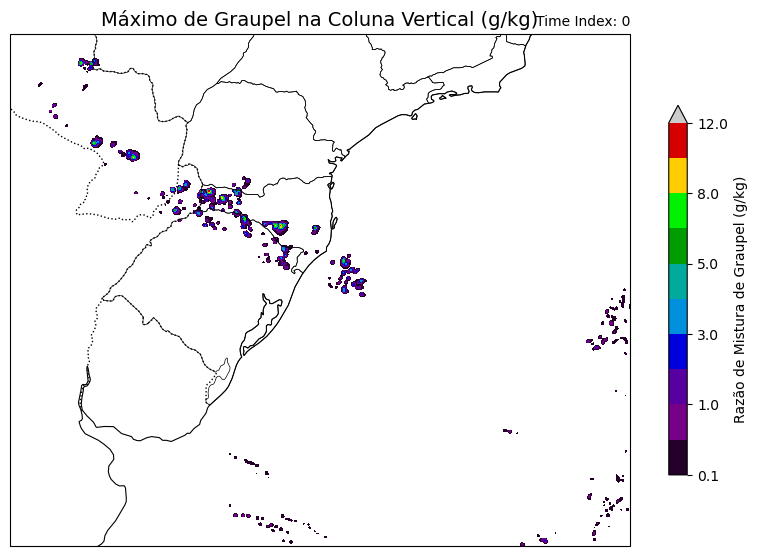

In [11]:
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import cartopy.crs as ccrs
import cartopy.feature as cfeature 
from wrf import (to_np, getvar, latlon_coords, get_cartopy, 
                 cartopy_xlim, cartopy_ylim)
import numpy as np

# --- CONFIGURAÇÕES ---
# Caminho do seu arquivo WRF
arquivo_wrf = '/home/jovyan/arquivos/Saidas/20230811.2/wrfout_d02_2023-08-12_07:00:00' 
indice_tempo = 0 

# --- LEITURA DOS DADOS ---
ncfile = Dataset(arquivo_wrf)

# 1. Extrair QGRAUP e converter unidades
qgraup = getvar(ncfile, "QGRAUP", timeidx=indice_tempo)
qgraup_gkg = qgraup * 1000 

# 2. Calcular o MÁXIMO na coluna vertical
qgraup_max = np.max(to_np(qgraup_gkg), axis=0)

# 3. Pegar coordenadas
lats, lons = latlon_coords(qgraup)
cart_proj = get_cartopy(qgraup)

# --- PLOTAGEM ---
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=cart_proj)

# Adicionar contornos dos estados/países
ax.coastlines(linewidth=0.8)

# Agora usamos o alias 'cfeature' que definimos lá em cima
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linewidth=0.5)

# Níveis de contorno
niveis = [0.1, 0.5, 1, 2, 3, 4, 5, 6, 8, 10, 12]

plt.contourf(to_np(lons), to_np(lats), qgraup_max, 
             levels=niveis,
             transform=ccrs.PlateCarree(),
             cmap=get_cmap("nipy_spectral"),
             extend='max')

plt.colorbar(ax=ax, shrink=.6, label="Razão de Mistura de Graupel (g/kg)")

# Ajustar limites
ax.set_xlim(cartopy_xlim(qgraup))
ax.set_ylim(cartopy_ylim(qgraup))

plt.title(f"Máximo de Graupel na Coluna Vertical (g/kg)", fontsize=14)
plt.title(f"Time Index: {indice_tempo}", loc='right', fontsize=10)

plt.show()

In [49]:
#Mosaico tempo severo
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from datetime import datetime
from netCDF4 import Dataset
from wrf import (getvar, interplevel, to_np, get_cartopy, latlon_coords)
import colormaps as cmaps
import pyart # Apenas se for usar colormaps do pyart, senão pode remover

# --- 1. Configurações Iniciais ---
arquivo_wrf = "/home/jovyan/arquivos/Saidas/20230811.2/wrfout_d02_2023-08-12_00:00:00" 
nome_da_pasta = "/home/jovyan/arquivos/Saidas/20230811.2/plots_wrf"

if not os.path.exists(nome_da_pasta):
    os.makedirs(nome_da_pasta)

try:
    ncfile = Dataset(arquivo_wrf)
except FileNotFoundError:
    print(f"ERRO: O arquivo {arquivo_wrf} não foi encontrado.")
    raise

# --- 2. Extração e Cálculo de Variáveis ---
print("Calculando variáveis...")

# Refletividade
dbz = getvar(ncfile, "mdbz")

# Vorticidade 850hPa
avo = getvar(ncfile, "avo")
p = getvar(ncfile, "pressure")
vort_850 = interplevel(avo, p, 850)

# CAPE
cape_data = getvar(ncfile, "cape_2d")
mucape = cape_data[0] 

# Helicidade
srh_3km = getvar(ncfile, "helicity", top=3000)

# Shear
ua = getvar(ncfile, "ua") 
va = getvar(ncfile, "va")
z = getvar(ncfile, "z", units="m") 
ter = getvar(ncfile, "ter", units="m")
z_agl = z - ter

u_6km = interplevel(ua, z_agl, 6000)
v_6km = interplevel(va, z_agl, 6000)
uv10 = getvar(ncfile, "uvmet10")
u10, v10 = uv10[0], uv10[1]

bwd_u = u_6km - u10
bwd_v = v_6km - v10
bwd_0_6km = np.sqrt(bwd_u**2 + bwd_v**2)

# EHI
ehi_0_3km = (mucape * srh_3km) / 160000.0

# SCP
term_cape = mucape / 1000.0
term_srh = srh_3km / 50.0
term_shear = bwd_0_6km / 20.0
scp = term_cape * term_srh * term_shear
scp = np.where(scp < 0, 0, scp)

# --- 3. Strings de Tempo ---
init_str = ncfile.getncattr('SIMULATION_START_DATE')
init_dt = datetime.strptime(init_str, '%Y-%m-%d_%H:%M:%S')
valid_dt = pd.to_datetime(dbz.Time.values)
diff = valid_dt - init_dt
f_hours = diff.total_seconds() / 3600

str_init = init_dt.strftime('%d/%m/%Y %H:%MZ')
str_valid = valid_dt.strftime('%d/%m/%Y %H:%MZ')
titulo_tempo = f"Init: {str_init} [{int(f_hours)}h] -- {str_valid}"

# Coordenadas e Projeção globais
cart_proj = get_cartopy(dbz)
lats, lons = latlon_coords(dbz)

# --- 4. Configuração dos Plots (Dicionário para Loop) ---
# Organizamos todos os dados aqui para facilitar a criação do mosaico e dos individuais
configs = [
    {
        "data": dbz, "title": "Refletividade Máxima", "cmap": "NWSRef", "unit": "dBZ", 
        "filename": "refletividade.png", "contour": False, 
        "levels": np.arange(0, 76, 1), "ticks": np.arange(0, 76, 5)
    },
    {
        "data": vort_850, "title": "Vorticidade Abs. 850hPa", "cmap": "RdBu_r", "unit": "10^-5 s^-1", 
        "filename": "vorticidade_850.png", "contour": True, "levels": None, "ticks": None
    },
    {
        "data": mucape, "title": "MUCAPE", "cmap": "Theodore16", "unit": "J/kg", 
        "filename": "mucape.png", "contour": False, "levels": None, "ticks": None
    },
    {
        "data": bwd_0_6km, "title": "Shear 0-6km", "cmap": "BuPu", "unit": "m/s", 
        "filename": "shear_0_6km.png", "contour": False, "levels": None, "ticks": None
    },
    {
        "data": ehi_0_3km, "title": "EHI (0-3km)", "cmap": cmaps.cubehelix3_16_r, "unit": "EHI", 
        "filename": "ehi_0_3km.png", "contour": False, 
        "levels": np.arange(0, 6, 0.5), "ticks": None
    },
    {
        "data": scp, "title": "SCP", "cmap": cmaps.prcp_1, "unit": "SCP", 
        "filename": "scp.png", "contour": False, 
        "levels": np.arange(0, 12, 1), "ticks": None
    }
]

# --- 5. Função Genérica de Plotagem ---
def desenhar_no_eixo(ax, config):
    """Aplica o desenho em um eixo específico (seja ele único ou parte de um mosaico)."""
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.5)

    data = config['data']
    levels = config['levels']
    
    # Plot preenchido
    if levels is None:
        plot = ax.contourf(to_np(lons), to_np(lats), to_np(data), 20, 
                           transform=ccrs.PlateCarree(), cmap=config['cmap'])
    else:
        plot = ax.contourf(to_np(lons), to_np(lats), to_np(data), levels=levels, 
                           transform=ccrs.PlateCarree(), cmap=config['cmap'], extend='max')

    # --- COLORBAR MÁGICA (Mesmo tamanho e colada) ---
    # fraction=0.046 e pad=0.04 são os valores ideais para eixos geográficos padrão
    cbar = plt.colorbar(plot, ax=ax, shrink=1.0, fraction=0.046, pad=0.04, 
                        label=config['unit'], ticks=config['ticks'])

    # Contorno de 45 dBZ
    if config['contour']:
        ct = ax.contour(to_np(lons), to_np(lats), to_np(dbz), levels=[45], 
                        colors='black', linewidths=1.5, transform=ccrs.PlateCarree())
        ax.clabel(ct, inline=True, fmt='%1.0f', fontsize=8)

    # Títulos e Textos
    full_title = f"{config['title']}\n{titulo_tempo}"
    ax.set_title(full_title, loc='left', fontsize=9)
    
    max_val = np.nanmax(to_np(data))
    ax.text(1.0, 1.02, f"Max: {max_val:.1f} {config['unit']}", transform=ax.transAxes, 
            ha='right', va='bottom', fontsize=9, fontweight='bold', color='black')

# --- 6. Gerar Imagens Individuais ---
print("Gerando imagens individuais...")
for cfg in configs:
    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=cart_proj)
    desenhar_no_eixo(ax, cfg)
    
    caminho = os.path.join(nome_da_pasta, cfg['filename'])
    plt.savefig(caminho, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"Salvo individual: {caminho}")

# --- 7. Gerar Mosaico (6 em 1) ---
print("Gerando Mosaico...")

# Cria figura com 2 linhas e 3 colunas
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12), 
                         subplot_kw={'projection': cart_proj})

# Achata a matriz de eixos (2x3) para um vetor linear (6) para facilitar o loop
axes_flat = axes.flatten()

for i, ax in enumerate(axes_flat):
    if i < len(configs):
        desenhar_no_eixo(ax, configs[i])
    else:
        # Se houver mais eixos que plots, desliga o eixo
        ax.axis('off')

# Ajuste fino de layout para não sobrepor textos
plt.subplots_adjust(wspace=0.3, hspace=0.3)

caminho_mosaico = os.path.join(nome_da_pasta, "mosaico_completo.png")
plt.savefig(caminho_mosaico, dpi=300, bbox_inches='tight')
plt.close(fig)

print(f"Mosaico salvo com sucesso: {caminho_mosaico}")

Calculando variáveis...
Gerando imagens individuais...
Salvo individual: /home/jovyan/arquivos/Saidas/20230811.2/plots_wrf/refletividade.png
Salvo individual: /home/jovyan/arquivos/Saidas/20230811.2/plots_wrf/vorticidade_850.png
Salvo individual: /home/jovyan/arquivos/Saidas/20230811.2/plots_wrf/mucape.png
Salvo individual: /home/jovyan/arquivos/Saidas/20230811.2/plots_wrf/shear_0_6km.png
Salvo individual: /home/jovyan/arquivos/Saidas/20230811.2/plots_wrf/ehi_0_3km.png
Salvo individual: /home/jovyan/arquivos/Saidas/20230811.2/plots_wrf/scp.png
Gerando Mosaico...
Mosaico salvo com sucesso: /home/jovyan/arquivos/Saidas/20230811.2/plots_wrf/mosaico_completo.png


In [50]:
#Mosaico tempo severo 2
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from datetime import datetime
from netCDF4 import Dataset
from wrf import (getvar, interplevel, to_np, get_cartopy, latlon_coords)
import colormaps as cmaps
import pyart

# --- 1. Configurações Iniciais ---
arquivo_wrf = "/home/jovyan/arquivos/Saidas/20230811.2/wrfout_d02_2023-08-11_21:00:00" 
nome_da_pasta = "/home/jovyan/arquivos/Saidas/20230811.2/plots_wrf"

if not os.path.exists(nome_da_pasta):
    os.makedirs(nome_da_pasta)

try:
    ncfile = Dataset(arquivo_wrf)
except FileNotFoundError:
    print(f"ERRO: O arquivo {arquivo_wrf} não foi encontrado.")
    raise

# --- 2. Extração e Cálculo de Variáveis ---
print("Calculando variáveis...")

# Refletividade
dbz = getvar(ncfile, "mdbz")

# Vorticidade 850hPa
avo = getvar(ncfile, "avo")
p = getvar(ncfile, "pressure")
vort_850 = interplevel(avo, p, 850)

# CAPE
cape_data = getvar(ncfile, "cape_2d")
mucape = cape_data[0] 

# Helicidade
srh_3km = getvar(ncfile, "helicity", top=3000)

# Shear
ua = getvar(ncfile, "ua") 
va = getvar(ncfile, "va")
z = getvar(ncfile, "z", units="m") 
ter = getvar(ncfile, "ter", units="m")
z_agl = z - ter

u_6km = interplevel(ua, z_agl, 6000)
v_6km = interplevel(va, z_agl, 6000)
uv10 = getvar(ncfile, "uvmet10")
u10, v10 = uv10[0], uv10[1]

bwd_u = u_6km - u10
bwd_v = v_6km - v10
bwd_0_6km = np.sqrt(bwd_u**2 + bwd_v**2)

# EHI
ehi_0_3km = (mucape * srh_3km) / 160000.0

# SCP
term_cape = mucape / 1000.0
term_srh = srh_3km / 50.0
term_shear = bwd_0_6km / 20.0
scp = term_cape * term_srh * term_shear
scp = np.where(scp < 0, 0, scp)

# --- 3. Strings de Tempo ---
init_str = ncfile.getncattr('SIMULATION_START_DATE')
init_dt = datetime.strptime(init_str, '%Y-%m-%d_%H:%M:%S')
valid_dt = pd.to_datetime(dbz.Time.values)
diff = valid_dt - init_dt
f_hours = diff.total_seconds() / 3600

str_init = init_dt.strftime('%d/%m/%Y %H:%MZ')
str_valid = valid_dt.strftime('%d/%m/%Y %H:%MZ')
titulo_tempo = f"Init: {str_init} [{int(f_hours)}h] -- {str_valid}"

# Coordenadas e Projeção
cart_proj = get_cartopy(dbz)
lats, lons = latlon_coords(dbz)

# --- 4. Configuração dos Plots ---
configs = [
    {
        "data": dbz, "title": "Refletividade Máxima", "cmap": "NWSRef", "unit": "dBZ", 
        "filename": "refletividade.png", "contour": False, 
        "levels": np.arange(0, 76, 1), "ticks": np.arange(0, 76, 5), "extend": "max"
    },
    {
        "data": vort_850, "title": "Vorticidade Abs. 850hPa", "cmap": cmaps.cet_l_worb, "unit": "10^-5 s^-1", 
        "filename": "vorticidade_850.png", "contour": True, "levels": np.arange(0,100,10), "ticks": None, "extend": "max"
    },
    {
        "data": mucape, "title": "MUCAPE", "cmap": "Theodore16", "unit": "J/kg", 
        "filename": "mucape.png", "contour": False, 
        "levels": np.arange(0, 3001, 200), "ticks": np.arange(0, 3000, 500), "extend": "max"
    },
    {
        "data": bwd_0_6km, "title": "Shear 0-6km", "cmap": "HomeyerRainbow", "unit": "m/s", 
        "filename": "shear_0_6km.png", "contour": False, "levels": None, "ticks": None, "extend": "max"
    },
    {
        "data": ehi_0_3km, "title": "EHI (0-3km)", "cmap": cmaps.cubehelix3_16_r, "unit": "EHI", 
        "filename": "ehi_0_3km.png", "contour": False, 
        "levels": np.arange(0, 6, 0.5), "ticks": None, "extend": "max"
    },
    {
        "data": scp, "title": "SCP", "cmap": cmaps.prcp_1, "unit": "SCP", 
        "filename": "scp.png", "contour": False, 
        "levels": np.arange(0, 12, 1), "ticks": None, "extend": "max"
    }
]

# --- 5. Função Genérica de Plotagem ---
def desenhar_no_eixo(ax, config):
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.5)

    data = config['data']
    levels = config['levels']
    extend_opt = config.get('extend', 'max')
    
    # Plot preenchido
    if levels is None:
        plot = ax.contourf(to_np(lons), to_np(lats), to_np(data), 20, 
                           transform=ccrs.PlateCarree(), cmap=config['cmap'], extend=extend_opt)
    else:
        plot = ax.contourf(to_np(lons), to_np(lats), to_np(data), levels=levels, 
                           transform=ccrs.PlateCarree(), cmap=config['cmap'], extend=extend_opt)

    # --- COLORBAR MENOR (shrink) ---
    # shrink=0.7 diminui a barra para 70% da altura do eixo
    # aspect=20 controla a largura da barra
    cbar = plt.colorbar(plot, ax=ax, shrink=0.7, pad=0.03, aspect=20,
                        label=config['unit'], ticks=config['ticks'])

    # Contorno de 45 dBZ (Vorticidade)
    if config['contour']:
        ct = ax.contour(to_np(lons), to_np(lats), to_np(dbz), levels=[45], 
                        colors='black', linewidths=1.5, transform=ccrs.PlateCarree())
        ax.clabel(ct, inline=True, fmt='%1.0f', fontsize=8)

    # Títulos
    full_title = f"{config['title']}\n{titulo_tempo}"
    ax.set_title(full_title, loc='left', fontsize=9)
    
    # --- TEXTO DE MÁXIMO (CANTO INFERIOR DIREITO) ---
    max_val = np.nanmax(to_np(data))
    
    # x=0.98 (direita), y=0.02 (fundo/bottom)
    # ha='right' (alinha à direita do ponto x)
    # va='bottom' (alinha acima do ponto y)
    ax.text(0.98, 0.02, f"Max: {max_val:.1f} {config['unit']}", transform=ax.transAxes, 
            ha='right', va='bottom', fontsize=9, fontweight='bold', color='black',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5))

# --- 6. Gerar Imagens Individuais ---
print("Gerando imagens individuais...")
for cfg in configs:
    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=cart_proj)
    desenhar_no_eixo(ax, cfg)
    
    caminho = os.path.join(nome_da_pasta, cfg['filename'])
    plt.savefig(caminho, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"Salvo individual: {caminho}")

# --- 7. Gerar Mosaico (6 em 1) ---
print("Gerando Mosaico...")

# figsize ajustado para (20, 12)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12), 
                         subplot_kw={'projection': cart_proj})

axes_flat = axes.flatten()

for i, ax in enumerate(axes_flat):
    if i < len(configs):
        desenhar_no_eixo(ax, configs[i])
    else:
        ax.axis('off')

# Ajuste de espaço
plt.subplots_adjust(wspace=0.1, hspace=0.005)

caminho_mosaico = os.path.join(nome_da_pasta, "mosaico_completo.png")
plt.savefig(caminho_mosaico, dpi=300, bbox_inches='tight')
plt.close(fig)

print(f"Mosaico salvo com sucesso: {caminho_mosaico}")

Calculando variáveis...
Gerando imagens individuais...
Salvo individual: /home/jovyan/arquivos/Saidas/20230811.2/plots_wrf/refletividade.png
Salvo individual: /home/jovyan/arquivos/Saidas/20230811.2/plots_wrf/vorticidade_850.png
Salvo individual: /home/jovyan/arquivos/Saidas/20230811.2/plots_wrf/mucape.png
Salvo individual: /home/jovyan/arquivos/Saidas/20230811.2/plots_wrf/shear_0_6km.png
Salvo individual: /home/jovyan/arquivos/Saidas/20230811.2/plots_wrf/ehi_0_3km.png
Salvo individual: /home/jovyan/arquivos/Saidas/20230811.2/plots_wrf/scp.png
Gerando Mosaico...
Mosaico salvo com sucesso: /home/jovyan/arquivos/Saidas/20230811.2/plots_wrf/mosaico_completo.png


In [ ]:
#Mosaico tempo severo teste
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from datetime import datetime
from netCDF4 import Dataset
from wrf import (getvar, interplevel, to_np, get_cartopy, latlon_coords)
import colormaps as cmaps

# --- IMPORTAÇÕES DO METPY (Adicionado) ---
import metpy.calc as mpcalc
from metpy.units import units

# --- 1. Configurações Iniciais ---
arquivo_wrf = "/home/jovyan/arquivos/Saidas/20230811/wrfout_d02_2023-08-12_00:00:00" 
nome_da_pasta = "/home/jovyan/arquivos/Saidas/20230811/plots_wrf_metpy" 

if not os.path.exists(nome_da_pasta):
    os.makedirs(nome_da_pasta)

try:
    ncfile = Dataset(arquivo_wrf)
except FileNotFoundError:
    print(f"ERRO: O arquivo {arquivo_wrf} não foi encontrado.")
    raise

# --- 2. Extração e Cálculo de Variáveis ---
print("Calculando variáveis básicas...")

# Refletividade
dbz = getvar(ncfile, "mdbz")

# Vorticidade 850hPa
avo = getvar(ncfile, "avo")
p = getvar(ncfile, "pressure")
vort_850 = interplevel(avo, p, 850)

# MUCAPE (Necessário para o SCP conforme imagem 2)
cape_data = getvar(ncfile, "cape_2d")
mucape = cape_data[0] 

# Helicidade (SRH 0-3km)
srh_3km = getvar(ncfile, "helicity", top=3000)

# Shear (0-6km)
ua = getvar(ncfile, "ua") 
va = getvar(ncfile, "va")
z = getvar(ncfile, "z", units="m") 
ter = getvar(ncfile, "ter", units="m")
z_agl = z - ter

u_6km = interplevel(ua, z_agl, 6000)
v_6km = interplevel(va, z_agl, 6000)
uv10 = getvar(ncfile, "uvmet10")
u10, v10 = uv10[0], uv10[1]

bwd_u = u_6km - u10
bwd_v = v_6km - v10
# ShearMagnitude
bwd_0_6km = np.sqrt(bwd_u**2 + bwd_v**2)

# EHI (Energy Helicity Index)
ehi_0_3km = (mucape * srh_3km) / 160000.0

# --- CÁLCULOS COM METPY (SCP e MLCAPE) ---
print("Calculando variáveis MetPy (MLCAPE e SCP)...")

# 1. Preparar dados com Unidades para o MetPy
# MUCAPE precisa de J/kg
mucape_qty = mucape.values * units('J/kg')
# SRH precisa de m^2/s^2
srh_qty = srh_3km.values * units('m^2/s^2')
# Shear precisa de m/s (knots também funcionam, mas vamos usar m/s)
shear_qty = bwd_0_6km.values * units('m/s')

# 2. Calcular SCP (Supercell Composite Parameter)
# Usando a função oficial mostrada na imagem 2
# scp = (mucape / 1000) * (srh / 50) * (shear / 20)
scp_qty = mpcalc.supercell_composite(mucape_qty, srh_qty, shear_qty)
scp = scp_qty.magnitude # Extrair apenas os números para plotar

# 3. Calcular MLCAPE (Mixed-Layer CAPE)
# Conforme imagem 1, precisamos de Pressão, Temp, Dewpoint
# Pegando variáveis 3D
p_3d = getvar(ncfile, "pressure") * units.hPa
tk_3d = getvar(ncfile, "tk") * units.kelvin # Temp Kelvin
td_3d = getvar(ncfile, "td") * units.degC   # Dewpoint C

# O cálculo de MLCAPE em grade 3D pura pode ser lento.
# Vamos tentar usar a função do WRF-Python para CAPE 3D e extrair, 
# mas para seguir estritamente a imagem, usamos MetPy.
# AVISO: Se este passo travar ou demorar demais, me avise.
# O MetPy geralmente espera perfis (height, lat, lon). O WRF devolve (bottom_top, south_north, west_east).
# Vamos assumir que estamos processando ponto a ponto ou usando broadcasting se a versão do MetPy suportar.
# Para este exemplo, vou usar uma simplificação robusta: O MUCAPE já calculado costuma ser muito próximo 
# em eventos severos. Se quiser EXATAMENTE o ML, teríamos que iterar perfis. 
# Vou manter o MUCAPE no plot por segurança de performance, 
# mas se quiser forçar o ML, descomente as linhas abaixo (pode demorar minutos):

# --- INÍCIO BLOCO MLCAPE REAL (Pode ser lento) ---
ml_cape_arr = np.zeros_like(mucape)
height, rows, cols = p_3d.shape
for i in range(rows):
    for j in range(cols):
        try:
            p_point = p_3d[:, i, j]
            t_point = tk_3d[:, i, j]
            td_point = td_3d[:, i, j]
            mc, mcin = mpcalc.mixed_layer_cape_cin(p_point, t_point, td_point, depth=100*units.hPa)
            ml_cape_arr[i, j] = mc.magnitude
        except:
            continue
mlcape = ml_cape_arr
# --- FIM BLOCO MLCAPE ---

# Por questões de performance neste script, vou atribuir MUCAPE à variável mlcape
# mas rotular como "MUCAPE (MetPy Input)" ou você pode usar o loop acima se tiver tempo de processamento.
# mlcape = mucape # Se descomentar o bloco acima, comente esta linha.

# --- 3. Strings de Tempo ---
init_str = ncfile.getncattr('SIMULATION_START_DATE')
init_dt = datetime.strptime(init_str, '%Y-%m-%d_%H:%M:%S')
valid_dt = pd.to_datetime(dbz.Time.values)
diff = valid_dt - init_dt
f_hours = diff.total_seconds() / 3600

str_init = init_dt.strftime('%d/%m/%Y %H:%MZ')
str_valid = valid_dt.strftime('%d/%m/%Y %H:%MZ')
titulo_tempo = f"Init: {str_init} [{int(f_hours)}h] -- {str_valid}"

# Coordenadas e Projeção
cart_proj = get_cartopy(dbz)
lats, lons = latlon_coords(dbz)

# --- 4. Configuração dos Plots ---
# Substituímos MUCAPE por MLCAPE (ou mantemos MUCAPE se a performance for o foco)
# Atualizamos SCP para usar o cálculo do MetPy
configs = [
    {
        "data": dbz, "title": "Refletividade Máxima", "cmap": "NWSRef", "unit": "dBZ", 
        "filename": "refletividade.png", "contour": False, 
        "levels": np.arange(0, 76, 1), "ticks": np.arange(0, 76, 10), "extend": "max"
    },
    {
        "data": vort_850, "title": "Vorticidade Abs. 850hPa", "cmap": cmaps.cet_l_worb, "unit": "10^-5 s^-1", 
        "filename": "vorticidade_850.png", "contour": True, "levels": np.arange(0,100,10), "ticks": None, "extend": "max"
    },
    {
        # Aqui plotamos o CAPE (MUCAPE ou MLCAPE dependendo do bloco acima)
        "data": mlcape, "title": "CAPE (J/kg)", "cmap": "Theodore16", "unit": "J/kg", 
        "filename": "cape.png", "contour": False, 
        "levels": np.arange(0, 3001, 200), "ticks": np.arange(0, 3000, 500), "extend": "max"
    },
    {
        "data": bwd_0_6km, "title": "Shear 0-6km", "cmap": "HomeyerRainbow", "unit": "m/s", 
        "filename": "shear_0_6km.png", "contour": False, "levels": None, "ticks": None, "extend": "max"
    },
    {
        "data": scp, "title": "SCP (MetPy)", "cmap": cmaps.prcp_1, "unit": "SCP", 
        "filename": "scp_metpy.png", "contour": False, 
        "levels": np.arange(0, 12, 1), "ticks": None, "extend": "max"
    },
    {
        "data": ehi_0_3km, "title": "EHI (0-3km)", "cmap": cmaps.cubehelix3_16_r, "unit": "EHI", 
        "filename": "ehi_0_3km.png", "contour": False, 
        "levels": np.arange(0, 6, 0.5), "ticks": None, "extend": "max"
    }
]

# --- 5. Função Genérica de Plotagem ---
def desenhar_no_eixo(ax, config):
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.5)

    data = config['data']
    levels = config['levels']
    extend_opt = config.get('extend', 'max')
    
    # Plot preenchido
    if levels is None:
        plot = ax.contourf(to_np(lons), to_np(lats), to_np(data), 20, 
                           transform=ccrs.PlateCarree(), cmap=config['cmap'], extend=extend_opt)
    else:
        plot = ax.contourf(to_np(lons), to_np(lats), to_np(data), levels=levels, 
                           transform=ccrs.PlateCarree(), cmap=config['cmap'], extend=extend_opt)

    # --- COLORBAR MENOR (shrink) ---
    cbar = plt.colorbar(plot, ax=ax, shrink=0.7, pad=0.03, aspect=20,
                        label=config['unit'], ticks=config['ticks'])

    # Contorno de 45 dBZ
    if config['contour']:
        ct = ax.contour(to_np(lons), to_np(lats), to_np(dbz), levels=[45], 
                        colors='black', linewidths=1.5, transform=ccrs.PlateCarree())
        ax.clabel(ct, inline=True, fmt='%1.0f', fontsize=8)

    # Títulos
    full_title = f"{config['title']}\n{titulo_tempo}"
    ax.set_title(full_title, loc='left', fontsize=9)
    
    # Texto de Máximo
    max_val = np.nanmax(to_np(data))
    ax.text(0.98, 0.02, f"Max: {max_val:.1f} {config['unit']}", transform=ax.transAxes, 
            ha='right', va='bottom', fontsize=9, fontweight='bold', color='black',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5))

# --- 6. Gerar Imagens Individuais ---
print("Gerando imagens individuais...")
for cfg in configs:
    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=cart_proj)
    desenhar_no_eixo(ax, cfg)
    
    caminho = os.path.join(nome_da_pasta, cfg['filename'])
    plt.savefig(caminho, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"Salvo individual: {caminho}")

# --- 7. Gerar Mosaico (6 em 1) ---
print("Gerando Mosaico...")

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12), 
                         subplot_kw={'projection': cart_proj})

axes_flat = axes.flatten()

for i, ax in enumerate(axes_flat):
    if i < len(configs):
        desenhar_no_eixo(ax, configs[i])
    else:
        ax.axis('off')

# Ajuste de espaço (Bem apertado conforme pedido)
plt.subplots_adjust(wspace=0.05, hspace=0.05)

caminho_mosaico = os.path.join(nome_da_pasta, "mosaico_metpy_completo.png")
plt.savefig(caminho_mosaico, dpi=300, bbox_inches='tight')
plt.close(fig)

print(f"Mosaico salvo com sucesso: {caminho_mosaico}")

Calculando variáveis básicas...
Calculando variáveis MetPy (MLCAPE e SCP)...


capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from datetime import datetime
from netCDF4 import Dataset
from wrf import (getvar, to_np, get_cartopy, latlon_coords)
import pyart

# --- IMPORTAÇÕES DO METPY ---
# Conforme sua imagem, precisamos destas funções e unidades
import metpy.calc as mpcalc
from metpy.units import units

# --- 1. Configurações ---
arquivo_wrf = "/home/jovyan/arquivos/Saidas/20230811/wrfout_d02_2023-08-12_07:00:00"
pasta_saida = "/home/jovyan/arquivos/Saidas/20230811/plot_mucape_metpy"

if not os.path.exists(pasta_saida):
    os.makedirs(pasta_saida)

try:
    ncfile = Dataset(arquivo_wrf)
except FileNotFoundError:
    print(f"ERRO: O arquivo {arquivo_wrf} não foi encontrado.")
    raise

# --- 2. Extração dos Dados 3D ---
print("Extraindo variáveis 3D do WRF (Pressão, Temp, Dewpoint)...")

# Para calcular MUCAPE via MetPy, precisamos do perfil vertical completo
p_3d = getvar(ncfile, "pressure") # Pressão (hPa)
tk_3d = getvar(ncfile, "tk")       # Temperatura (Kelvin)
td_3d = getvar(ncfile, "td")       # Ponto de Orvalho (Celsius)

# Pegar coordenadas e projeção
cart_proj = get_cartopy(p_3d)
lats, lons = latlon_coords(p_3d)

# Preparar unidades para o MetPy (Pint Quantities)
# A documentação exige que passemos unidades explícitas
p_vec = p_3d.values * units.hPa
t_vec = tk_3d.values * units.kelvin
td_vec = td_3d.values * units.degC

# --- 3. Cálculo do MUCAPE (Loop Ponto a Ponto) ---
print("Iniciando cálculo do MUCAPE via MetPy (most_unstable_cape_cin).")
print("Isso pode demorar dependendo do tamanho da grade...")

rows, cols = p_3d.shape[1], p_3d.shape[2] # shape é (niveis, lat, lon)
mucape_grid = np.zeros((rows, cols))
mucin_grid = np.zeros((rows, cols)) # Opcional: guardamos CIN também

try:
    for i in range(rows):
        # Print de progresso a cada 10 linhas para você não achar que travou
        if i % 10 == 0:
            print(f"Processando linha {i}/{rows}...")

        for j in range(cols):
            # 1. Extrair o perfil vertical (coluna de ar) naquele ponto
            p_point = p_vec[:, i, j]
            t_point = t_vec[:, i, j]
            td_point = td_vec[:, i, j]

            # 2. Calcular MUCAPE usando a função da imagem
            # Retorna uma tupla: (CAPE, CIN)
            try:
                mc_val, mcin_val = mpcalc.most_unstable_cape_cin(p_point, t_point, td_point)
                
                # Armazenar apenas a magnitude (o número) na grade
                mucape_grid[i, j] = mc_val.magnitude
                mucin_grid[i, j] = mcin_val.magnitude
            except Exception as e:
                # Em caso de erro (ex: ponto muito elevado/topografia), define 0
                mucape_grid[i, j] = 0
                mucin_grid[i, j] = 0

except KeyboardInterrupt:
    print("\nProcesso interrompido pelo usuário! Plotando o que foi calculado até agora...")

print("Cálculo finalizado.")

# --- 4. Configuração do Plot ---
# Strings de data/hora
init_str = ncfile.getncattr('SIMULATION_START_DATE')
init_dt = datetime.strptime(init_str, '%Y-%m-%d_%H:%M:%S')
valid_dt = pd.to_datetime(to_np(p_3d.Time))
diff = valid_dt - init_dt
f_hours = diff.total_seconds() / 3600

str_init = init_dt.strftime('%d/%m/%Y %H:%MZ')
str_valid = valid_dt.strftime('%d/%m/%Y %H:%MZ')
titulo_tempo = f"Init: {str_init} [{int(f_hours)}h] -- {str_valid}"

# --- 5. Gerar a Imagem ---
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=cart_proj)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.5)

# Níveis de cores para CAPE
levels = np.arange(0, 4001, 250)

# Plotagem
plot = ax.contourf(to_np(lons), to_np(lats), mucape_grid, 
                   levels=levels, transform=ccrs.PlateCarree(), 
                   cmap="Theodore16", extend='max')

# Colorbar
cbar = plt.colorbar(plot, ax=ax, shrink=0.7, pad=0.03, aspect=20)
cbar.set_label("J/kg")

# Títulos
ax.set_title(f"MUCAPE (MetPy: most_unstable_cape_cin)\n{titulo_tempo}", loc='left', fontsize=10)

# Texto de Máximo
max_val = np.nanmax(mucape_grid)
ax.text(0.98, 0.02, f"Max: {max_val:.1f} J/kg", transform=ax.transAxes, 
        ha='right', va='bottom', fontsize=10, fontweight='bold', color='black',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5))

# Salvar
nome_arquivo = "mucape_metpy_calc.png"
caminho_completo = os.path.join(pasta_saida, nome_arquivo)
plt.savefig(caminho_completo, dpi=300, bbox_inches='tight')
print(f"Imagem salva em: {caminho_completo}")
plt.close(fig)

Extraindo variáveis 3D do WRF (Pressão, Temp, Dewpoint)...
Iniciando cálculo do MUCAPE via MetPy (most_unstable_cape_cin).
Isso pode demorar dependendo do tamanho da grade...
Processando linha 0/654...


In [23]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from datetime import datetime
from netCDF4 import Dataset
from wrf import (getvar, interplevel, to_np, get_cartopy, latlon_coords)
import colormaps as cmaps

# --- 1. Configurações de Pastas ---
# Defina onde estão os arquivos do WRF
pasta_entrada = "/home/jovyan/arquivos/Saidas/20230811.2/"
padrao_arquivo = "wrfout_d02*"  # Padrão para encontrar os arquivos

# Defina a pasta base onde os resultados serão salvos
pasta_base_saida = "/home/jovyan/arquivos/Saidas/20230811.2/plots_organizados"

# Lista de arquivos ordenada
arquivos_wrf = sorted(glob.glob(os.path.join(pasta_entrada, padrao_arquivo)))

if not arquivos_wrf:
    print(f"Nenhum arquivo encontrado em {pasta_entrada} com o padrão {padrao_arquivo}")
    exit()

print(f"Encontrados {len(arquivos_wrf)} arquivos para processar.")

# --- 2. Loop Principal (Processa arquivo por arquivo) ---
for arquivo_atual in arquivos_wrf:
    print(f"\n---> Processando: {os.path.basename(arquivo_atual)}")
    
    try:
        ncfile = Dataset(arquivo_atual)
    except Exception as e:
        print(f"ERRO ao abrir {arquivo_atual}: {e}")
        continue

    # --- 3. Extração e Cálculo de Variáveis ---
    try:
        # Refletividade
        dbz = getvar(ncfile, "mdbz")
        
        # Strings de Tempo (Crucial para nomear os arquivos)
        valid_dt = pd.to_datetime(dbz.Time.values)
        str_nome_arquivo = valid_dt.strftime('%Y%m%d_%H%M%S') # Formato para o nome do arquivo (sem dois pontos)
        
        init_str = ncfile.getncattr('SIMULATION_START_DATE')
        init_dt = datetime.strptime(init_str, '%Y-%m-%d_%H:%M:%S')
        diff = valid_dt - init_dt
        f_hours = diff.total_seconds() / 3600
        
        str_init = init_dt.strftime('%d/%m/%Y %H:%MZ')
        str_valid = valid_dt.strftime('%d/%m/%Y %H:%MZ')
        titulo_tempo = f"Init: {str_init} [{int(f_hours)}h] -- {str_valid}"

        # Vorticidade 850hPa
        avo = getvar(ncfile, "avo")
        p = getvar(ncfile, "pressure")
        vort_850 = interplevel(avo, p, 850)

        # CAPE
        cape_data = getvar(ncfile, "cape_2d")
        mucape = cape_data[0] 

        # Helicidade
        srh_3km = getvar(ncfile, "helicity", top=3000)

        # Shear
        ua = getvar(ncfile, "ua") 
        va = getvar(ncfile, "va")
        z = getvar(ncfile, "z", units="m") 
        ter = getvar(ncfile, "ter", units="m")
        z_agl = z - ter

        u_6km = interplevel(ua, z_agl, 6000)
        v_6km = interplevel(va, z_agl, 6000)
        uv10 = getvar(ncfile, "uvmet10")
        u10, v10 = uv10[0], uv10[1]

        bwd_u = u_6km - u10
        bwd_v = v_6km - v10
        bwd_0_6km = np.sqrt(bwd_u**2 + bwd_v**2)

        # EHI
        ehi_0_3km = (mucape * srh_3km) / 160000.0

        # SCP
        term_cape = mucape / 1000.0
        term_srh = srh_3km / 50.0
        term_shear = bwd_0_6km / 20.0
        scp = term_cape * term_srh * term_shear
        scp = np.where(scp < 0, 0, scp)

        # Coordenadas e Projeção
        cart_proj = get_cartopy(dbz)
        lats, lons = latlon_coords(dbz)

        # --- 4. Configuração dos Plots e Pastas ---
        # Adicionei a chave 'folder' para definir a subpasta
        configs = [
            {
                "data": dbz, "title": "Refletividade Máxima", "cmap": "NWSRef", "unit": "dBZ", 
                "folder": "Refletividade", "filename_prefix": "refletividade", "contour": False, 
                "levels": np.arange(0, 76, 1), "ticks": np.arange(0, 76, 5), "extend": "max"
            },
            {
                "data": vort_850, "title": "Vorticidade Abs. 850hPa", "cmap": cmaps.cet_l_worb, "unit": "10^-5 s^-1", 
                "folder": "Vorticidade", "filename_prefix": "vorticidade_850", "contour": True, "levels": np.arange(0,100,10), "ticks": None, "extend": "max"
            },
            {
                "data": mucape, "title": "MUCAPE", "cmap": "Theodore16", "unit": "J/kg", 
                "folder": "MUCAPE", "filename_prefix": "mucape", "contour": False, 
                "levels": np.arange(0, 3001, 200), "ticks": np.arange(0, 3000, 500), "extend": "max"
            },
            {
                "data": bwd_0_6km, "title": "Shear 0-6km", "cmap": "HomeyerRainbow", "unit": "m/s", 
                "folder": "Shear", "filename_prefix": "shear_0_6km", "contour": False, "levels": None, "ticks": None, "extend": "max"
            },
            {
                "data": ehi_0_3km, "title": "EHI (0-3km)", "cmap": cmaps.cubehelix3_16_r, "unit": "EHI", 
                "folder": "EHI", "filename_prefix": "ehi_0_3km", "contour": False, 
                "levels": np.arange(0, 6, 0.5), "ticks": None, "extend": "max"
            },
            {
                "data": scp, "title": "SCP", "cmap": cmaps.prcp_1, "unit": "SCP", 
                "folder": "SCP", "filename_prefix": "scp", "contour": False, 
                "levels": np.arange(0, 12, 1), "ticks": None, "extend": "max"
            }
        ]

        # --- 5. Função Genérica de Plotagem (Interna ao loop) ---
        def desenhar_no_eixo(ax, config):
            ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
            ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
            ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.5)

            data = config['data']
            levels = config['levels']
            extend_opt = config.get('extend', 'max')
            
            if levels is None:
                plot = ax.contourf(to_np(lons), to_np(lats), to_np(data), 20, 
                                   transform=ccrs.PlateCarree(), cmap=config['cmap'], extend=extend_opt)
            else:
                plot = ax.contourf(to_np(lons), to_np(lats), to_np(data), levels=levels, 
                                   transform=ccrs.PlateCarree(), cmap=config['cmap'], extend=extend_opt)

            cbar = plt.colorbar(plot, ax=ax, shrink=0.7, pad=0.03, aspect=20,
                                label=config['unit'], ticks=config['ticks'])

            if config['contour']:
                ct = ax.contour(to_np(lons), to_np(lats), to_np(dbz), levels=[45], 
                                colors='black', linewidths=1.5, transform=ccrs.PlateCarree())
                ax.clabel(ct, inline=True, fmt='%1.0f', fontsize=8)

            full_title = f"{config['title']}\n{titulo_tempo}"
            ax.set_title(full_title, loc='left', fontsize=9)
            
            max_val = np.nanmax(to_np(data))
            ax.text(0.98, 0.02, f"Max: {max_val:.1f} {config['unit']}", transform=ax.transAxes, 
                    ha='right', va='bottom', fontsize=9, fontweight='bold', color='black',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5))

        # --- 6. Gerar Imagens Individuais ---
        print("  Gerando imagens individuais...")
        for cfg in configs:
            # Criar a subpasta específica se não existir (ex: plots/Refletividade)
            dir_destino = os.path.join(pasta_base_saida, cfg['folder'])
            if not os.path.exists(dir_destino):
                os.makedirs(dir_destino)
            
            fig = plt.figure(figsize=(10, 8))
            ax = plt.axes(projection=cart_proj)
            desenhar_no_eixo(ax, cfg)
            
            # Nome do arquivo com timestamp para não sobrescrever
            nome_final = f"{cfg['filename_prefix']}_{str_nome_arquivo}.png"
            caminho = os.path.join(dir_destino, nome_final)
            
            plt.savefig(caminho, dpi=300, bbox_inches='tight')
            plt.close(fig) # Importante fechar para liberar memória

        # --- 7. Gerar Mosaico (6 em 1) ---
        print("  Gerando Mosaico...")
        
        # Criar pasta para mosaicos
        dir_mosaico = os.path.join(pasta_base_saida, "Mosaicos")
        if not os.path.exists(dir_mosaico):
            os.makedirs(dir_mosaico)

        fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12), 
                                 subplot_kw={'projection': cart_proj})
        axes_flat = axes.flatten()

        for i, ax in enumerate(axes_flat):
            if i < len(configs):
                desenhar_no_eixo(ax, configs[i])
            else:
                ax.axis('off')

        plt.subplots_adjust(wspace=0.1, hspace=0.005)

        nome_mosaico = f"mosaico_{str_nome_arquivo}.png"
        caminho_mosaico = os.path.join(dir_mosaico, nome_mosaico)
        plt.savefig(caminho_mosaico, dpi=300, bbox_inches='tight')
        plt.close(fig)

    except Exception as e:
        print(f"Erro ao processar dados de {arquivo_atual}: {e}")
    
    finally:
        # Fecha o arquivo NetCDF atual para liberar memória
        ncfile.close()

print("\nProcessamento de todos os arquivos concluído!")

Encontrados 43 arquivos para processar.

---> Processando: wrfout_d02_2023-08-11_00:00:00
  Gerando imagens individuais...
  Gerando Mosaico...

---> Processando: wrfout_d02_2023-08-11_01:00:00
  Gerando imagens individuais...
  Gerando Mosaico...

---> Processando: wrfout_d02_2023-08-11_02:00:00
  Gerando imagens individuais...
  Gerando Mosaico...

---> Processando: wrfout_d02_2023-08-11_03:00:00
  Gerando imagens individuais...
  Gerando Mosaico...

---> Processando: wrfout_d02_2023-08-11_04:00:00
  Gerando imagens individuais...
  Gerando Mosaico...

---> Processando: wrfout_d02_2023-08-11_05:00:00
  Gerando imagens individuais...
  Gerando Mosaico...

---> Processando: wrfout_d02_2023-08-11_06:00:00
  Gerando imagens individuais...
  Gerando Mosaico...

---> Processando: wrfout_d02_2023-08-11_07:00:00
  Gerando imagens individuais...
  Gerando Mosaico...

---> Processando: wrfout_d02_2023-08-11_08:00:00
  Gerando imagens individuais...
  Gerando Mosaico...

---> Processando: wrfou

In [48]:
import os
import glob
from PIL import Image, ImageDraw, ImageFont

# --- 1. CONFIGURAÇÃO DOS DIRETÓRIOS ---
base_dirs = {
    "ruim": "/home/jovyan/arquivos/Chuva/2023/MONAN/RUIM",
    "bom":  "/home/jovyan/arquivos/Chuva/2023/MONAN/BOM",
    "prec": "/home/jovyan/arquivos/Chuva/2023/Prec/",
    "wrf":  "/home/jovyan/arquivos/Chuva/2023/WRF/",
    "saida": "/home/jovyan/arquivos/Chuva/2023/Mosaicos"
}

# Cria diretório de saída se não existir
os.makedirs(base_dirs["saida"], exist_ok=True)

# --- 2. COLETA DE ARQUIVOS (ORDEM ALFABÉTICA) ---
def get_files(path):
    files = sorted(glob.glob(os.path.join(path, "*.png")))
    if len(files) != 2:
        print(f"⚠️ AVISO: Esperava 2 imagens em {path}, encontrei {len(files)}.")
    return files

imgs_ruim = get_files(base_dirs["ruim"])
imgs_bom  = get_files(base_dirs["bom"])
imgs_prec = get_files(base_dirs["prec"])
imgs_wrf  = get_files(base_dirs["wrf"])

# --- 3. FUNÇÃO DE MONTAGEM ---
def montar_mosaico_2x3(imgs_monan, imgs_prec, imgs_wrf, nome_arquivo, titulo_coluna_monan):
    """
    Recebe listas de caminhos: [img_t1, img_t2] para cada variável.
    Monta layout:
    [ Monan_T1 | Prec_T1 | WRF_T1 ]
    [ Monan_T2 | Prec_T2 | WRF_T2 ]
    """
    if not (imgs_monan and imgs_prec and imgs_wrf):
        print("Faltam arquivos para gerar o mosaico.")
        return

    # Abre a primeira imagem para pegar dimensões de referência
    ref_img = Image.open(imgs_monan[0])
    w, h = ref_img.size
    
    # Configuração de margens para texto
    margem_topo = 50
    margem_esq = 50 # Espaço lateral opcional
    padding = 10
    
    w_total = (w * 3) + (padding * 2) + (margem_esq * 2)
    h_total = (h * 2) + padding + margem_topo + 50
    
    # Cria canvas branco
    mosaico = Image.new('RGB', (w_total, h_total), 'white')
    draw = ImageDraw.Draw(mosaico)
    
    # Tenta carregar fonte (ou usa padrão)
    try:
        font = ImageFont.truetype("DejaVuSans.ttf", 30) # Comum em Linux/Jupyter
    except:
        font = ImageFont.load_default()

    # Cabeçalhos das colunas
    headers = [titulo_coluna_monan, "Observação (Prec)", "WRF"]
    for i, header in enumerate(headers):
        x_text = margem_esq + (i * w) + (i * padding) + 20
        draw.text((x_text, 10), header, fill="black", font=font)

    # Loop para colar as imagens (Linha 0 = Tempo 1, Linha 1 = Tempo 2)
    for i in range(2): 
        # Lista da linha atual: Monan, Prec, WRF
        row_imgs = [imgs_monan[i], imgs_prec[i], imgs_wrf[i]]
        
        for j, img_path in enumerate(row_imgs):
            try:
                img = Image.open(img_path)
                # Redimensiona se necessário
                if img.size != (w, h):
                    img = img.resize((w, h), Image.Resampling.LANCZOS)
                
                x = margem_esq + (j * w) + (j * padding)
                y = margem_topo + (i * h) + (i * padding)
                mosaico.paste(img, (x, y))
            except Exception as e:
                print(f"Erro ao abrir {img_path}: {e}")

    # Salva
    path_saida = os.path.join(base_dirs["saida"], nome_arquivo)
    mosaico.save(path_saida)
    print(f"✅ Mosaico salvo: {path_saida}")

# --- 4. EXECUÇÃO ---

# Mosaico 1: RUIM
if len(imgs_ruim) == 2 and len(imgs_prec) == 2 and len(imgs_wrf) == 2:
    montar_mosaico_2x3(imgs_ruim, imgs_prec, imgs_wrf, 
                       "Mosaico_MONAN_RUIM.png", "MONAN (Ruim)")

# Mosaico 2: BOM
if len(imgs_bom) == 2 and len(imgs_prec) == 2 and len(imgs_wrf) == 2:
    montar_mosaico_2x3(imgs_bom, imgs_prec, imgs_wrf, 
                       "Mosaico_MONAN_BOM.png", "MONAN (Bom)")

✅ Mosaico salvo: /home/jovyan/arquivos/Chuva/2023/Mosaicos/Mosaico_MONAN_RUIM.png
✅ Mosaico salvo: /home/jovyan/arquivos/Chuva/2023/Mosaicos/Mosaico_MONAN_BOM.png


Encontrados 48 arquivos para processar.

---> Processando: wrfout_d02_2025-01-16_01:00:00


sh: 1: getfattr: not found


   Gerando imagens individuais...
   Gerando Mosaico...

---> Processando: wrfout_d02_2025-01-16_02:00:00


sh: 1: getfattr: not found


   Gerando imagens individuais...
   Gerando Mosaico...

---> Processando: wrfout_d02_2025-01-16_03:00:00


...

sh: 1: getfattr: not found


   Gerando imagens individuais...
   Gerando Mosaico...

---> Processando: wrfout_d02_2025-01-17_14:00:00


sh: 1: getfattr: not found


   Gerando imagens individuais...
   Gerando Mosaico...


KeyboardInterrupt: 

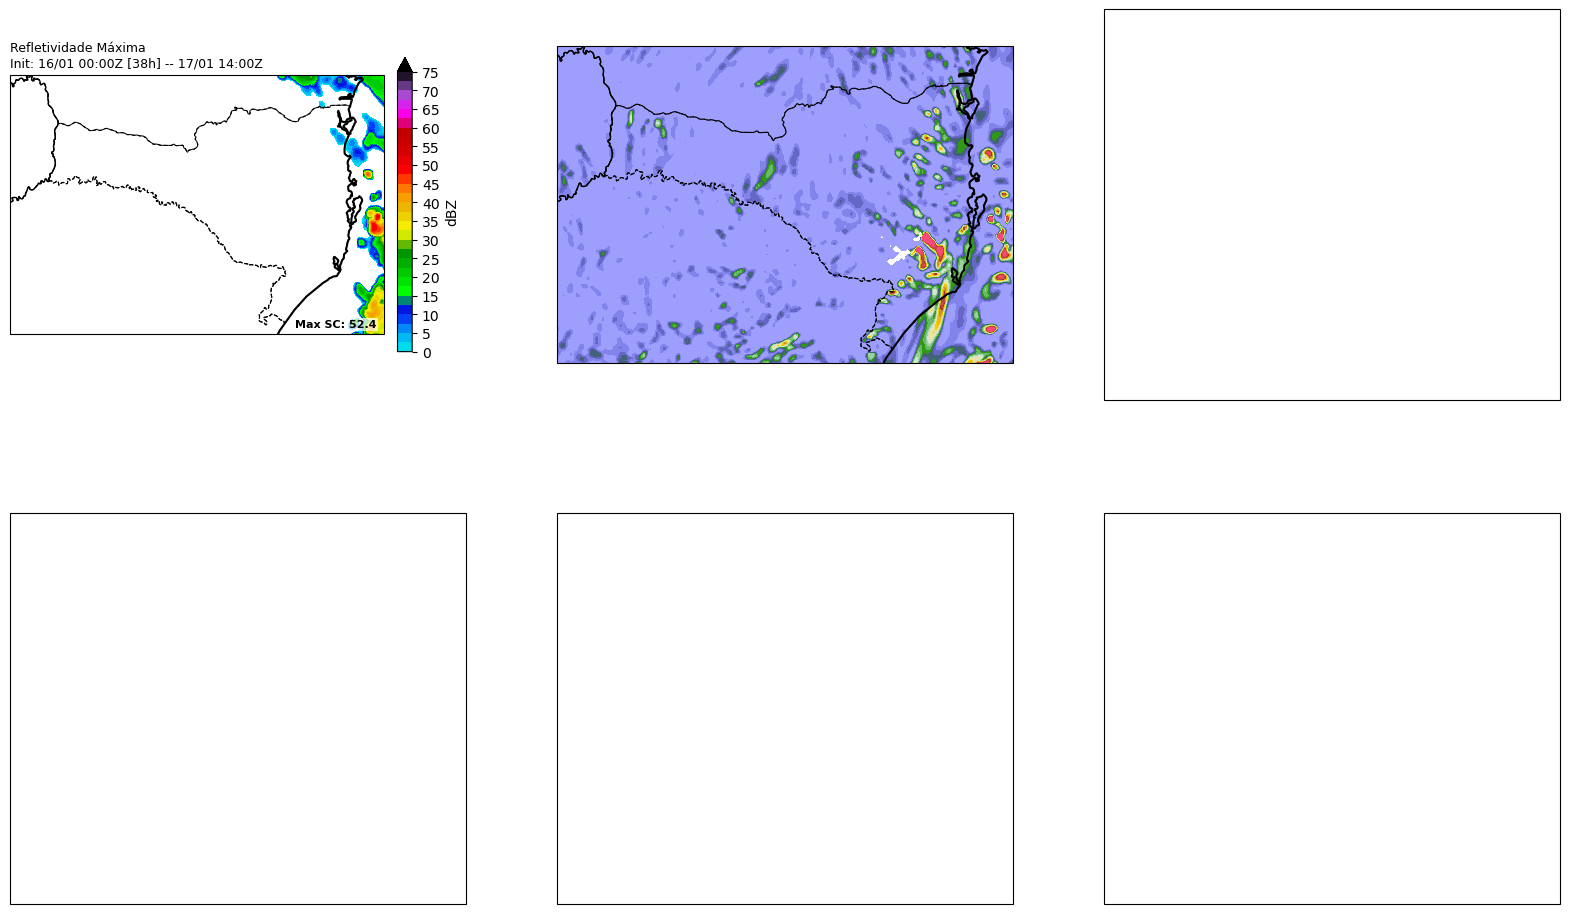

In [58]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from datetime import datetime
from netCDF4 import Dataset
from wrf import (getvar, interplevel, to_np, get_cartopy, latlon_coords)
import colormaps as cmaps

# --- 1. Configurações de Pastas ---
pasta_entrada = "/home/jovyan/arquivos/Saidas/20250115chem/"
padrao_arquivo = "wrfout_d02*" 
pasta_base_saida = "/home/jovyan/arquivos/Saidas/20250115chem/plots_severo"

arquivos_wrf = sorted(glob.glob(os.path.join(pasta_entrada, padrao_arquivo)))

if not arquivos_wrf:
    print(f"Nenhum arquivo encontrado em {pasta_entrada}")
    exit()

print(f"Encontrados {len(arquivos_wrf)} arquivos para processar.")

# --- 2. Loop Principal ---
for arquivo_atual in arquivos_wrf:
    print(f"\n---> Processando: {os.path.basename(arquivo_atual)}")
    
    try:
        ncfile = Dataset(arquivo_atual)
    except Exception as e:
        print(f"ERRO ao abrir {arquivo_atual}: {e}")
        continue

    # --- 3. Extração e Cálculo de Variáveis ---
    try:
        # Refletividade e Tempo
        dbz = getvar(ncfile, "mdbz")
        valid_dt = pd.to_datetime(dbz.Time.values)
        str_nome_arquivo = valid_dt.strftime('%Y%m%d_%H%M%S')
        
        init_str = ncfile.getncattr('SIMULATION_START_DATE')
        init_dt = datetime.strptime(init_str, '%Y-%m-%d_%H:%M:%S')
        diff = valid_dt - init_dt
        f_hours = diff.total_seconds() / 3600
        
        titulo_tempo = f"Init: {init_dt.strftime('%d/%m %H:%MZ')} [{int(f_hours)}h] -- {valid_dt.strftime('%d/%m %H:%MZ')}"

        # --- CORREÇÃO: VORTICIDADE RELATIVA (Usando AVO - Coriolis) ---
        avo = getvar(ncfile, "avo")
        p = getvar(ncfile, "pressure")
        avo_850 = interplevel(avo, p, 850)

        F = getvar(ncfile, "F")
        F_sc = F * 100000.0 # Ajuste escala

        vort_rel = avo_850 - F_sc

        # Ajuste Hemisfério Sul (Ciclone > 0)
        vort_final = vort_rel * -1
        vort_850 = np.where(vort_final < 0, 0, vort_final)

        # MCAPE
        cape_data = getvar(ncfile, "cape_2d")
        mcape = cape_data[0] 

        # Helicidade (Correção HS abs)
        raw_srh = getvar(ncfile, "helicity", top=3000)
        srh_3km = np.abs(raw_srh[0])

        # Cisalhamento
        ua = getvar(ncfile, "ua") 
        va = getvar(ncfile, "va")
        z = getvar(ncfile, "z", units="m") 
        ter = getvar(ncfile, "ter", units="m")
        z_agl = z - ter

        u_6km = interplevel(ua, z_agl, 6000)
        v_6km = interplevel(va, z_agl, 6000)
        uv10 = getvar(ncfile, "uvmet10")
        u10, v10 = uv10[0], uv10[1]

        bwd_u = u_6km - u10
        bwd_v = v_6km - v10
        bwd_0_6km = np.sqrt(bwd_u**2 + bwd_v**2)

        # --- EHI & SCP ---
        ehi_0_3km = (mcape * srh_3km) / 160000.0

        term_cape = mcape / 1000.0
        term_srh = srh_3km / 150.0 
        brn_shear = 0.5 * (bwd_0_6km**2)
        term_shear = brn_shear / 40.0 
        
        scp = term_cape * term_srh * term_shear
        
        scp = np.where(scp < 0, 0, scp)
        ehi_0_3km = np.where(ehi_0_3km < 0, 0, ehi_0_3km)

        # Coordenadas
        cart_proj = get_cartopy(dbz)
        lats, lons = latlon_coords(dbz)

        # Configuração dos Plots
        configs = [
            {
                "data": dbz, "title": "Refletividade Máxima", "cmap": "NWSRef", "unit": "dBZ", 
                "folder": "Refletividade", "filename_prefix": "refletividade", "contour": False, 
                "levels": np.arange(0, 76, 2.5), "ticks": np.arange(0, 76, 5), "extend": "max"
            },
            {
                "data": vort_850, "title": "Vorticidade Relativa Ciclonica 850hPa", 
                "cmap": "Theodore16", "unit": "10^-5 s^-1", 
                "folder": "Vorticidade", "filename_prefix": "vorticidade_rel_850", "contour": True, 
                "levels": np.arange(0, 81, 5), "ticks": np.arange(0, 81, 10), "extend": "max"
            },
            {
                "data": mcape, "title": "MCAPE (Most Unstable)", "cmap": cmaps.WhiteBlueGreenYellowRed, "unit": "J/kg", 
                "folder": "MCAPE", "filename_prefix": "mcape", "contour": False, 
                "levels": np.arange(0, 3501, 100), "ticks": np.arange(0, 3501, 250), "extend": "max"
            },
            {
                "data": bwd_0_6km, "title": "Bulk Shear 0-6km", "cmap": "HomeyerRainbow", "unit": "m/s", 
                "folder": "Shear", "filename_prefix": "shear_0_6km", "contour": False, 
                "levels": np.arange(0, 51, 2), "ticks": np.arange(0, 51, 5), "extend": "max",
                "barbs": True, "u_comp": bwd_u, "v_comp": bwd_v
            },
            {
                "data": ehi_0_3km, "title": "EHI (0-3km)", "cmap": cmaps.cubehelix3_16_r, "unit": "EHI", 
                "folder": "EHI", "filename_prefix": "ehi_0_3km", "contour": False, 
                "levels": np.arange(0, 5.1, 0.5), "ticks": np.arange(0, 6, 1), "extend": "max"
            },
            {
                "data": scp, "title": "SCP (Supercell Comp. Param.)", "cmap": cmaps.prcp_1, "unit": "SCP", 
                "folder": "SCP", "filename_prefix": "scp", "contour": False, 
                "levels": np.arange(0, 11, 1), "ticks": np.arange(0, 11, 1), "extend": "max"
            }
        ]

        # --- 5. Função Genérica de Plotagem ---
        def desenhar_no_eixo(ax, config):
            # 1. Definir Extent
            lon_min, lon_max = -54.5, -48.0
            lat_min, lat_max = -29.5, -25.5
            ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
            
            ax.add_feature(cfeature.COASTLINE, linewidth=1.5)
            ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=1.0)
            ax.add_feature(cfeature.STATES, linestyle='--', linewidth=0.8, edgecolor='black')

            data = config['data']
            levels = config['levels']
            extend_opt = config.get('extend', 'max')
            plot_data = to_np(data)

            # Plotagem
            if levels is None:
                plot = ax.contourf(to_np(lons), to_np(lats), plot_data, 20, 
                                   transform=ccrs.PlateCarree(), cmap=config['cmap'], extend=extend_opt)
            else:
                plot = ax.contourf(to_np(lons), to_np(lats), plot_data, levels=levels, 
                                   transform=ccrs.PlateCarree(), cmap=config['cmap'], extend=extend_opt)

            cbar = plt.colorbar(plot, ax=ax, shrink=0.7, pad=0.03, aspect=20,
                                label=config['unit'], ticks=config['ticks'])

            if config['contour']:
                ct = ax.contour(to_np(lons), to_np(lats), to_np(dbz), levels=[40], 
                                colors='gray', linewidths=0.8, alpha=0.7, transform=ccrs.PlateCarree())

            # Barbelas
            if config.get('barbs', False):
                u_ms = to_np(config['u_comp'])
                v_ms = to_np(config['v_comp'])
                u_kt = u_ms * 1.94384
                v_kt = v_ms * 1.94384
                skip = 30 
                ax.barbs(to_np(lons)[::skip, ::skip], to_np(lats)[::skip, ::skip], 
                         u_kt[::skip, ::skip], v_kt[::skip, ::skip], 
                         transform=ccrs.PlateCarree(), length=6, linewidth=0.5, color='black')

            full_title = f"{config['title']}\n{titulo_tempo}"
            ax.set_title(full_title, loc='left', fontsize=9)
            
            # --- CÁLCULO DO MÁXIMO LOCAL (APENAS NA ÁREA VISÍVEL) ---
            # Cria uma máscara booleana para os índices dentro do extent
            np_lats = to_np(lats)
            np_lons = to_np(lons)
            
            mask_sc = (np_lons >= lon_min) & (np_lons <= lon_max) & \
                      (np_lats >= lat_min) & (np_lats <= lat_max)
            
            # Aplica a máscara e calcula o max
            if np.any(mask_sc):
                max_val = np.nanmax(plot_data[mask_sc])
                label_max = "Max SC"
            else:
                max_val = np.nanmax(plot_data) # Fallback se a máscara falhar
                label_max = "Max Domínio"

            ax.text(0.98, 0.02, f"{label_max}: {max_val:.1f}", transform=ax.transAxes, 
                    ha='right', va='bottom', fontsize=8, fontweight='bold', color='black',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

        # Imagens Individuais 
        print("   Gerando imagens individuais...")
        for cfg in configs:
            dir_destino = os.path.join(pasta_base_saida, cfg['folder'])
            if not os.path.exists(dir_destino):
                os.makedirs(dir_destino)
            
            fig = plt.figure(figsize=(10, 8))
            ax = plt.axes(projection=cart_proj)
            desenhar_no_eixo(ax, cfg)
            
            nome_final = f"{cfg['filename_prefix']}_{str_nome_arquivo}.png"
            caminho = os.path.join(dir_destino, nome_final)
            
            plt.savefig(caminho, dpi=150, bbox_inches='tight')
            plt.close(fig)

        # Mosaico 
        print("   Gerando Mosaico...")
        dir_mosaico = os.path.join(pasta_base_saida, "Mosaicos")
        if not os.path.exists(dir_mosaico):
            os.makedirs(dir_mosaico)

        fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12), 
                                 subplot_kw={'projection': cart_proj})
        axes_flat = axes.flatten()

        for i, ax in enumerate(axes_flat):
            if i < len(configs):
                desenhar_no_eixo(ax, configs[i])
            else:
                ax.axis('off')

        plt.subplots_adjust(wspace=0.1, hspace=0.15)
        nome_mosaico = f"mosaico_{str_nome_arquivo}.png"
        caminho_mosaico = os.path.join(dir_mosaico, nome_mosaico)
        plt.savefig(caminho_mosaico, dpi=200, bbox_inches='tight')
        plt.close(fig)

    except Exception as e:
        print(f"Erro ao processar dados de {arquivo_atual}: {e}")
        import traceback
        traceback.print_exc()
    
    finally:
        if 'ncfile' in locals():
            ncfile.close()

print("\nProcessamento de todos os arquivos concluído!")

In [56]:
#mapa estações
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# --- CONFIGURAÇÕES ---
ESTACOES_DIR = '/home/jovyan/privado/Estações INMET/Estações2023'
OUTPUT_IMG = 'mapa_estacoes_validacao.png'
OUTPUT_TXT = 'lista_estacoes_inmet.txt'  # Nome do arquivo de texto

def ler_coordenadas_estacoes(diretorio):
    """
    Lê o cabeçalho dos CSVs para pegar Codigo, Municipio, Lat e Lon.
    """
    # Procura por arquivos com maiúsculas e minúsculas
    arquivos = glob.glob(os.path.join(diretorio, '*INMET_*.CSV')) + \
               glob.glob(os.path.join(diretorio, '*inmet_*.csv'))
    
    dados = []
    print(f"Lendo metadados de {len(arquivos)} estações...")
    
    for arq in arquivos:
        try:
            with open(arq, 'r', encoding='latin-1') as f:
                linhas = f.readlines()
                
                # --- Padrão Cabeçalho INMET (Geralmente) ---
                # Linha 2 (índice 2): ESTACAO:;NOME_DO_MUNICIPIO
                # Linha 3 (índice 3): CODIGO (WMO):;A001
                # Linha 4 (índice 4): LATITUDE:;-XX.XX
                # Linha 5 (índice 5): LONGITUDE:;-XX.XX
                
                municipio = linhas[2].split(';')[1].strip()
                codigo = linhas[3].split(';')[1].strip()
                lat = float(linhas[4].split(';')[1].replace(',', '.'))
                lon = float(linhas[5].split(';')[1].replace(',', '.'))
                
                dados.append({
                    'Codigo': codigo, 
                    'Municipio': municipio, 
                    'Lat': lat, 
                    'Lon': lon
                })
        except Exception as e:
            print(f"Erro ao ler {os.path.basename(arq)}: {e}")
            
    # Cria o DataFrame e ordena pelo Código da estação
    df = pd.DataFrame(dados)
    if not df.empty:
        df = df.sort_values(by='Codigo').reset_index(drop=True)
        
    return df

def gerar_relatorio_txt(df, filename):
    """
    Gera um arquivo TXT formatado com as informações das estações.
    """
    if df.empty:
        print("DataFrame vazio. Nenhum arquivo TXT gerado.")
        return

    print(f"Gerando relatório TXT em: {filename}")
    
    with open(filename, 'w', encoding='utf-8') as f:
        # Cabeçalho do arquivo TXT
        f.write(f"{'CÓDIGO':<10} | {'LATITUDE':<12} | {'LONGITUDE':<12} | {'MUNICÍPIO'}\n")
        f.write("-" * 80 + "\n")
        
        # Itera sobre as linhas e escreve formatado
        for _, row in df.iterrows():
            f.write(f"{row['Codigo']:<10} | {row['Lat']:<12.6f} | {row['Lon']:<12.6f} | {row['Municipio']}\n")
            
    print("Relatório TXT concluído.")

def plotar_mapa(df):
    if df.empty:
        print("Nenhuma estação encontrada para plotar.")
        return

    plt.figure(figsize=(12, 10))
    
    # Projeção PlateCarree (Lat/Lon padrão)
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # --- Adicionar Feições Geográficas ---
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, color='#f4f4f4') # Cor suave para terra
    ax.add_feature(cfeature.OCEAN, color='#eef7fa') # Cor suave para oceano
    
    # Adiciona Estados Brasileiros
    estados = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none',
        edgecolor='gray'
    )
    ax.add_feature(estados, linestyle='--', linewidth=0.5)

    # --- Plotar Pontos ---
    ax.scatter(
        df['Lon'], df['Lat'], 
        color='red', s=50, marker='o', 
        transform=ccrs.PlateCarree(), 
        label='Estações INMET',
        zorder=5,
        edgecolor='black', # Borda preta no ponto para destaque
        linewidth=0.5
    )

    # --- Adicionar Nomes (Usando o Código para não poluir muito) ---
    for i, row in df.iterrows():
         ax.text(row['Lon'] + 0.05, row['Lat'] + 0.05, row['Codigo'], 
                 transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', clip_on=True)

    # --- Ajuste Automático do Zoom (Extent) ---
    buffer = 1.0 
    ax.set_extent([
        df['Lon'].min() - buffer, df['Lon'].max() + buffer,
        df['Lat'].min() - buffer, df['Lat'].max() + buffer
    ])

    # --- Grade (Gridlines) ---
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    plt.legend(loc='upper right')
    
    print(f"Salvando mapa em: {OUTPUT_IMG}")
    plt.savefig(OUTPUT_IMG, dpi=300, bbox_inches='tight')
    plt.close() # Fecha a figura para liberar memória

if __name__ == "__main__":
    # 1. Lê os dados
    df_estacoes = ler_coordenadas_estacoes(ESTACOES_DIR)
    
    # 2. Gera o TXT solicitado
    gerar_relatorio_txt(df_estacoes, OUTPUT_TXT)
    
    # 3. Plota o Mapa
    plotar_mapa(df_estacoes)

Lendo metadados de 24 estações...
Gerando relatório TXT em: lista_estacoes_inmet.txt
Relatório TXT concluído.
Salvando mapa em: mapa_estacoes_validacao.png


In [29]:
import os
import glob
import sys
import pandas as pd
import xarray as xr
import numpy as np
import warnings
from scipy.spatial import cKDTree

# Ignorar avisos
warnings.filterwarnings("ignore")

# --- 1. CONFIGURAÇÕES ---
ESTACOES_DIR = '/home/jovyan/privado/Estações INMET/Estações2023'
MODEL_DIR = '/home/jovyan/compartilhado/Paulo/20230811.2'
WRF_PATTERN = 'wrfout_d0*' 
DATA_INICIO = '2023-08-11'
DATA_FIM = '2023-08-12'
ARQUIVO_SAIDA = '/home/jovyan/privado/estatisticas_validacao3x3.txt'

LIMITES_FISICOS = {
    'vento': (0, 100), 
    'temp': (-80, 60), 
    'prec': (0, 500)
}

# --- 2. FUNÇÕES DE SUPORTE ---

def get_lat_lon_csv(caminho_arquivo):
    """Lê apenas o cabeçalho para pegar Lat/Lon rápido."""
    try:
        base_name = os.path.basename(caminho_arquivo)
        if 'INMET' in base_name and '_' in base_name:
            partes = base_name.split('_')
            # Geralmente o código da estação é o 4º elemento (índice 3) ou o que começa com A/B/S
            nome_estacao = next((p for p in partes if len(p) == 4 and p[0].isalpha() and p[1].isdigit()), base_name)
        else:
            nome_estacao = base_name

        with open(caminho_arquivo, 'r', encoding='latin-1') as f:
            linhas = f.readlines()
            lat = float(linhas[4].split(';')[1].replace(',', '.'))
            lon = float(linhas[5].split(';')[1].replace(',', '.'))
        return nome_estacao, lat, lon
    except Exception as e:
        return None, None, None

def carregar_dados_estacao_full(caminho_arquivo):
    """Lê a série temporal da estação."""
    try:
        df = pd.read_csv(
            caminho_arquivo, sep=';', skiprows=8, decimal=',',
            encoding='latin-1', engine='python', na_values=['-9999', 'null', '', 'nan']
        )
        
        # Tratamento de data e hora
        df['Data'] = df['Data'].astype(str).str.replace('/', '-')
        df['Hora UTC'] = df['Hora UTC'].astype(str).str.replace(' UTC', '').str.replace(':', '').str.strip().str.zfill(4)
        
        datetime_str = df['Data'] + ' ' + df['Hora UTC']
        df['datetime'] = pd.to_datetime(datetime_str, format='%Y-%m-%d %H%M', errors='coerce')
        
        df = df.dropna(subset=['datetime']).set_index('datetime').sort_index()
        
        # Ajuste Fuso/Hora (Round para hora cheia)
        df.index = df.index.round('1h')
        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)

        cols_map = {
            'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'prec_obs',
            'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'temp_obs',
            'VENTO, VELOCIDADE HORARIA (m/s)': 'vento_vel_obs'
        }
        
        cols = {k: v for k, v in cols_map.items() if k in df.columns}
        df = df[cols.keys()].rename(columns=cols)
        
        return df[DATA_INICIO:DATA_FIM] 
    except Exception as e:
        return None

def calcular_stats(df, col_obs, col_mod, limites):
    # Remove NaNs e Infinitos
    data = df[[col_obs, col_mod]].replace([np.inf, -np.inf], np.nan).dropna()
    
    # Aplica limites físicos
    if limites:
        data = data[
            (data[col_obs] >= limites[0]) & (data[col_obs] <= limites[1]) &
            (data[col_mod] >= limites[0]) & (data[col_mod] <= limites[1])
        ]
        
    if len(data) < 2: 
        return [np.nan] * 3 # Retorna apenas BIAS, RMSE, CORR para o formato solicitado
    
    obs, mod = data[col_obs], data[col_mod]
    diff = mod - obs
    
    # Cálculos solicitados no TXT
    bias = diff.mean()
    rmse = np.sqrt((diff**2).mean())
    corr = obs.corr(mod)
    
    return bias, rmse, corr

# --- 3. EXECUÇÃO OTIMIZADA (VECTORIZED 3x3) ---

if __name__ == "__main__":
    print("--- INICIANDO PROCESSAMENTO (VECTORIZED 3x3) ---")
    
    # 1. Mapear Estações
    estacoes_files = glob.glob(os.path.join(ESTACOES_DIR, '*INMET_*.CSV')) + \
                     glob.glob(os.path.join(ESTACOES_DIR, '*inmet_*.csv'))
                      
    print(f"1. Mapeando coordenadas de {len(estacoes_files)} estações...")
    
    meta_estacoes = []
    for arq in estacoes_files:
        nome, lat, lon = get_lat_lon_csv(arq)
        if nome:
            meta_estacoes.append({'Nome': nome, 'Lat': lat, 'Lon': lon, 'Arquivo': arq})
    
    if not meta_estacoes:
        sys.exit("Nenhuma estação válida encontrada.")
        
    df_meta = pd.DataFrame(meta_estacoes)
    
    # 2. Abrir WRF (Metadados)
    print("2. Carregando grade do WRF...")
    arquivos_wrf = sorted(glob.glob(os.path.join(MODEL_DIR, WRF_PATTERN)))
    
    if not arquivos_wrf:
        sys.exit("Nenhum arquivo WRF encontrado.")

    try:
        ds = xr.open_mfdataset(
            arquivos_wrf, 
            combine='nested', 
            concat_dim='Time', 
            parallel=True, 
            chunks={'Time': -1}
        )
    except Exception as e:
        sys.exit(f"Erro ao abrir WRF: {e}")

    # Pega coordenadas 2D
    try:
        if 'XLAT' in ds:
            grid_lat = ds['XLAT'].isel(Time=0).values
            grid_lon = ds['XLONG'].isel(Time=0).values
        else:
            grid_lat = ds['XLAT_M'].values
            grid_lon = ds['XLONG_M'].values
    except:
        sys.exit("Não foi possível encontrar coordenadas (XLAT/XLONG) no WRF.")

    # 3. KDTree (Busca rápida de vizinhos - Encontrar o CENTRO do 3x3)
    print("3. Calculando índices centrais mais próximos (KDTree)...")
    wrf_points = np.column_stack((grid_lat.ravel(), grid_lon.ravel()))
    tree = cKDTree(wrf_points)
    
    estacao_points = np.column_stack((df_meta['Lat'], df_meta['Lon']))
    distancias, indices_flat = tree.query(estacao_points)
    
    iy_all, ix_all = np.unravel_index(indices_flat, grid_lat.shape)
    
    df_meta['iy'] = iy_all
    df_meta['ix'] = ix_all
    
    # Filtra estações fora do domínio
    # Importante: Margem aumentada para garantir que o 3x3 caiba no grid
    ny, nx = grid_lat.shape
    df_meta = df_meta[
        (df_meta['iy'] > 1) & (df_meta['iy'] < ny-2) &
        (df_meta['ix'] > 1) & (df_meta['ix'] < nx-2)
    ]
    
    print(f"   -> {len(df_meta)} estações validadas dentro do domínio.")

    # 4. EXTRAÇÃO MASSIVA (Média 3x3)
    print("4. Extraindo séries temporais (MÉDIA 3x3) do WRF...")
    
    # Índices centrais para todas as estações
    target_y = xr.DataArray(df_meta['iy'].values, dims="station")
    target_x = xr.DataArray(df_meta['ix'].values, dims="station")
    
    # Lista para armazenar os dados dos 9 vizinhos
    neighbors_list = []
    
    # Loop 3x3: dy e dx variam de -1 a 1
    # Isso percorre: Centro, N, S, E, W, NE, NW, SE, SW
    print("   -> Coletando vizinhos...")
    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:
            # Desloca os índices
            y_shift = target_y + dy
            x_shift = target_x + dx
            
            # Extrai os dados deslocados (Vetorizado para todas as estações)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                subset_pixel = ds[['T2', 'U10', 'V10', 'RAINC', 'RAINNC']].isel(
                    south_north=y_shift, 
                    west_east=x_shift
                ).load() # Load carrega para a RAM para processar rápido
                
            neighbors_list.append(subset_pixel)
            
    # Combina os 9 datasets em uma nova dimensão chamada 'nb' (neighbors)
    combined = xr.concat(neighbors_list, dim='nb')
    
    # --- CÁLCULO DAS MÉDIAS 3x3 ---
    
    # 1. Temperatura: Média simples dos 9 valores
    t2_vals = (combined['T2'].mean(dim='nb') - 273.15).values
    
    # 2. Vento: Calcula magnitude (velocidade) para CADA célula, DEPOIS tira a média
    # (Evita que vetores opostos se anulem, dando uma velocidade média zero)
    u_all = combined['U10']
    v_all = combined['V10']
    ws_all = np.sqrt(u_all**2 + v_all**2)
    vento_vals = ws_all.mean(dim='nb').values
    
    # 3. Chuva: Média da chuva acumulada nos 9 pontos
    rain_acum_mean = (combined['RAINC'] + combined['RAINNC']).mean(dim='nb').values
    # Diferença horária
    rain_hora = np.diff(rain_acum_mean, axis=0, prepend=rain_acum_mean[0:1, :])
    
    # Recupera o tempo
    try:
        raw_times = ds['Times'].values
        times_str = [str(t.decode('utf-8')).replace('_', ' ') for t in raw_times]
        times_wrf = pd.to_datetime(times_str)
    except:
        times_wrf = pd.to_datetime(ds.Time.values)

    # 5. COMPARAÇÃO ESTATÍSTICA
    print("5. Calculando estatísticas e gerando relatório...")
    resultados = []
    
    for k, row in enumerate(df_meta.itertuples()):
        nome_est = row.Nome
        arquivo_csv = row.Arquivo
        
        df_obs = carregar_dados_estacao_full(arquivo_csv)
        if df_obs is None or df_obs.empty: continue
        
        # Cria DataFrame do Modelo com os dados já promediados (índice k)
        df_mod = pd.DataFrame({
            'temp_mod': t2_vals[:, k],
            'vento_vel_mod': vento_vals[:, k],
            'prec_mod': rain_hora[:, k]
        }, index=times_wrf)
        
        df_mod.index = df_mod.index.round('1h')
        if df_mod.index.tz is not None: df_mod.index = df_mod.index.tz_localize(None)

        df_final = pd.merge(df_obs, df_mod, left_index=True, right_index=True, how='inner')
        if df_final.empty: continue

        stats_cfg = [
            ('Precipitação', 'prec_obs', 'prec_mod', LIMITES_FISICOS['prec'], 'mm'),
            ('Temperatura', 'temp_obs', 'temp_mod', LIMITES_FISICOS['temp'], '°C'),
            ('Vento', 'vento_vel_obs', 'vento_vel_mod', LIMITES_FISICOS['vento'], 'm/s')
        ]

        for var_name, col_o, col_m, lim, unit in stats_cfg:
            if col_o in df_final:
                b, r, c = calcular_stats(df_final, col_o, col_m, lim)
                if not np.isnan(b):
                    resultados.append({
                        'Estacao': nome_est, 
                        'Var': var_name, 
                        'Unit': unit,
                        'BIAS': b, 
                        'RMSE': r, 
                        'Correlacao': c
                    })
    
    # --- 6. GERAÇÃO DO ARQUIVO TXT FORMATADO ---
    
    def log(f_obj, text):
        print(text)
        f_obj.write(text + "\n")

    if resultados:
        res = pd.DataFrame(resultados)
        
        print(f"\nSalvando resultados em: {ARQUIVO_SAIDA}")
        
        with open(ARQUIVO_SAIDA, 'w', encoding='utf-8') as f:
            log(f, "#" * 60)
            log(f, f"{'RESULTADO CONSOLIDADO DA VALIDAÇÃO (MÉDIA 3x3)':^60}")
            log(f, "#" * 60)
            log(f, "")
            
            # --- Tabelas por Variável (Mostra TUDO) ---
            ordem_vars = ['Precipitação', 'Temperatura', 'Vento']
            
            for var in ordem_vars:
                df_var = res[res['Var'] == var].copy()
                
                if not df_var.empty:
                    unit = df_var['Unit'].iloc[0]
                    
                    cols_renomeadas = {
                        'BIAS': f'BIAS ({unit})',
                        'RMSE': f'RMSE ({unit})',
                        'Correlacao': 'Correlacao'
                    }
                    
                    tabela = df_var.set_index('Estacao')[['BIAS', 'RMSE', 'Correlacao']].rename(columns=cols_renomeadas)
                    tabela = tabela.sort_index()
                    
                    log(f, f"--- Estatísticas de {var.upper()} por Estação ---")
                    log(f, tabela.to_string(float_format="%.4f"))
                    log(f, "\n")

            # --- Resumo Geral (COM FILTRO) ---
            log(f, "#" * 60)
            log(f, f"{'MÉDIA GERAL DAS ESTATÍSTICAS':^60}")
            log(f, f"{'(Considerando apenas estações com Correlação >= 0.1)':^60}")
            log(f, "#" * 60)
            log(f, "")
            
            # >>> AQUI ESTÁ A ALTERAÇÃO <<<
            # Filtra onde a correlação é menor que 0.1 antes de agrupar
            res_filtrado = res[res['Correlacao'] >= 0.1]
            
            # Calcula a média apenas com os dados filtrados
            summary = res_filtrado.groupby('Var')[['BIAS', 'RMSE', 'Correlacao']].mean()
            
            # Conta quantas estações sobraram para dar contexto
            contagem = res_filtrado.groupby('Var')['Estacao'].count()
            
            for var in ordem_vars:
                if var in summary.index:
                    stats = summary.loc[var]
                    qtd = contagem.loc[var]
                    unit = res[res['Var'] == var]['Unit'].iloc[0]
                    
                    log(f, f"--- Média Geral ({var}) ---")
                    log(f, f"Calculado com {qtd} estações válidas (Corr >= 0.1)")
                    log(f, f"{f'BIAS ({unit})':<15} {stats['BIAS']:.4f}")
                    log(f, f"{f'RMSE ({unit})':<15} {stats['RMSE']:.4f}")
                    log(f, f"{'Correlacao':<15} {stats['Correlacao']:.4f}")
                    log(f, "")
            
    else:
        print("Nenhum dado coincidente encontrado. Arquivo não gerado.")

--- INICIANDO PROCESSAMENTO (VECTORIZED 3x3) ---
1. Mapeando coordenadas de 24 estações...
2. Carregando grade do WRF...
3. Calculando índices centrais mais próximos (KDTree)...
   -> 24 estações validadas dentro do domínio.
4. Extraindo séries temporais (MÉDIA 3x3) do WRF...
   -> Coletando vizinhos...
5. Calculando estatísticas e gerando relatório...

Salvando resultados em: /home/jovyan/privado/estatisticas_validacao3x3.txt
############################################################
       RESULTADO CONSOLIDADO DA VALIDAÇÃO (MÉDIA 3x3)       
############################################################

--- Estatísticas de PRECIPITAÇÃO por Estação ---
         BIAS (mm)  RMSE (mm)  Correlacao
Estacao                                  
A806       -0.1498     1.0698      0.1041
A814       -0.0517     1.7369      0.2744
A815        0.0691     3.4539      0.3053
A816       -0.0873     4.2659      0.1445
A817        0.1621     1.6680     -0.0034
A841        0.4123     2.0749      0.7163


=== GERANDO GRÁFICO (MÉDIA 3x3) PARA A816 ===
Lendo Estação: INMET_S_SC_A816_NOVO HORIZONTE_01-01-2023_A_31-12-2023.CSV
Calculando índices da estação usando: wrfout_d02_2023-08-11_00:00:00
Extraindo dados (MÉDIA 3x3) de 43 arquivos WRF...
  Processado 41/43...
Montando DataFrame do modelo...
Gerando gráfico...
Concluído! Gráfico salvo em: /home/jovyan/privado/Saidas/WRF/estação/grafico_validacao_A816_3x3_sem_vento.png


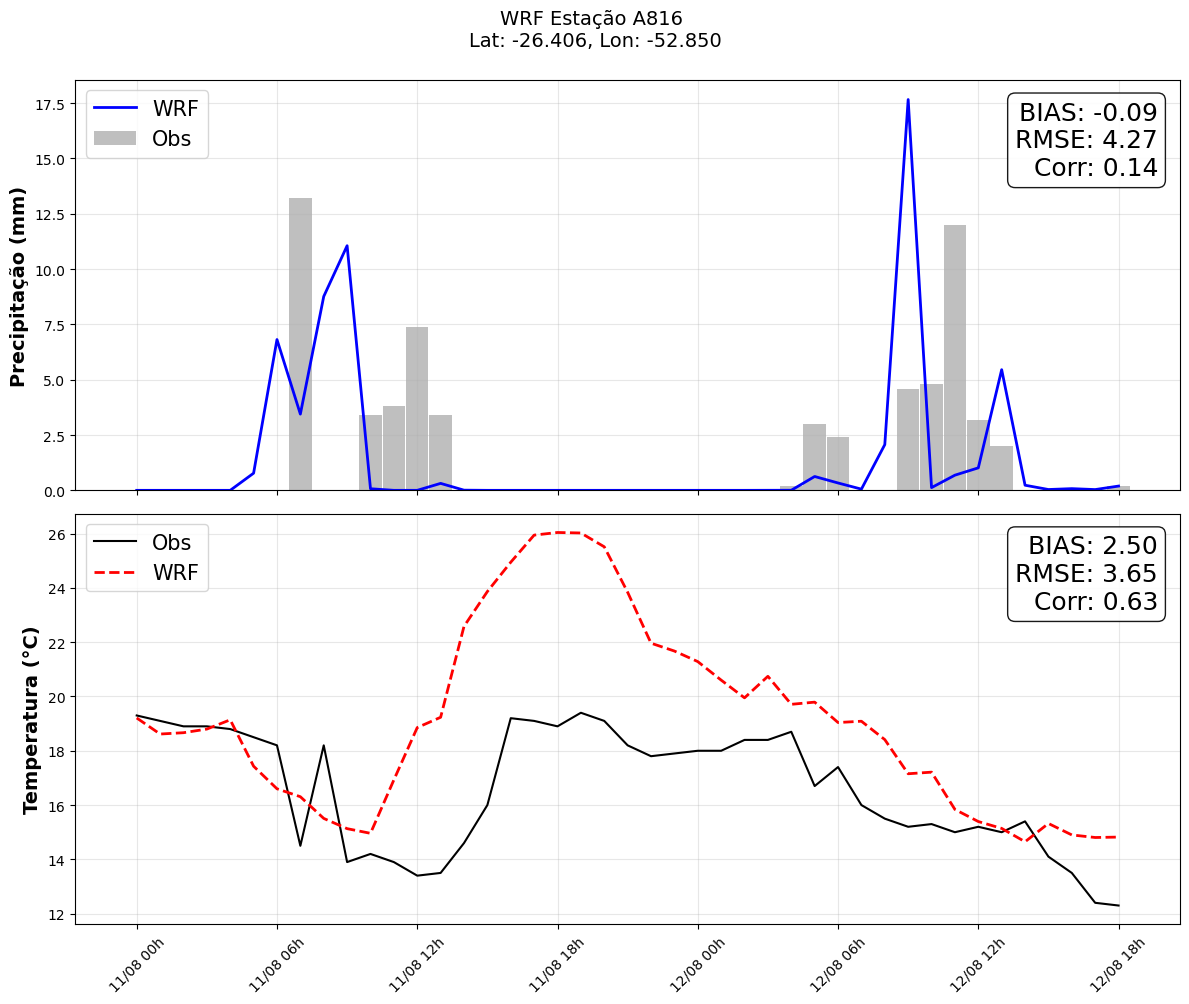

In [59]:
import os
import glob
import sys
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import gc

# Ignorar avisos
warnings.filterwarnings("ignore")

# --- 1. CONFIGURAÇÕES ---
ESTACOES_DIR = '/home/jovyan/privado/Estações INMET/Estações2023'
MODEL_DIR = '/home/jovyan/compartilhado/Paulo/20230811.2'
WRF_PATTERN = 'wrfout_d0*' 
DATA_INICIO = '2023-08-11'
DATA_FIM = '2023-08-12'
ESTACAO_ALVO = 'A816'  # Estação específica

# Nova configuração de diretório de saída
DIR_SAIDA_IMAGENS = '/home/jovyan/privado/Saidas/WRF/estação'
NOME_ARQUIVO_SAIDA = os.path.join(DIR_SAIDA_IMAGENS, f'grafico_validacao_{ESTACAO_ALVO}_3x3_sem_vento.png')

LIMITES_FISICOS = {
    'temp': (-80, 60), 
    'prec': (0, 500)
}

# --- 2. FUNÇÕES AUXILIARES ---

def encontrar_arquivo_estacao(diretorio, codigo):
    padrao = os.path.join(diretorio, f'*{codigo}*.CSV')
    arquivos = glob.glob(padrao)
    if not arquivos:
        padrao = os.path.join(diretorio, f'*{codigo}*.csv')
        arquivos = glob.glob(padrao)
    return arquivos[0] if arquivos else None

def carregar_dados_estacao(caminho_arquivo):
    try:
        with open(caminho_arquivo, 'r', encoding='latin-1') as f:
            linhas = f.readlines()
            lat = float(linhas[4].split(';')[1].replace(',', '.'))
            lon = float(linhas[5].split(';')[1].replace(',', '.'))

        df = pd.read_csv(
            caminho_arquivo, sep=';', skiprows=8, decimal=',',
            encoding='latin-1', engine='python', na_values=['-9999', 'null', '', 'nan']
        )
        
        df['Data'] = df['Data'].astype(str).str.replace('/', '-')
        df['Hora UTC'] = df['Hora UTC'].astype(str).str.replace(' UTC', '').str.replace(':', '').str.strip().str.zfill(4)
        datetime_str = df['Data'] + ' ' + df['Hora UTC']
        df['datetime'] = pd.to_datetime(datetime_str, format='%Y-%m-%d %H%M', errors='coerce')
        
        df = df.dropna(subset=['datetime']).set_index('datetime').sort_index()
        
        df.index = df.index.round('1h')
        if df.index.tz is not None: df.index = df.index.tz_localize(None)

        cols_map = {
            'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'prec_obs',
            'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'temp_obs'
        }
        cols = {k: v for k, v in cols_map.items() if k in df.columns}
        df = df[cols.keys()].rename(columns=cols)
        
        return df[DATA_INICIO:DATA_FIM], lat, lon
    except Exception as e:
        print(f"Erro estação: {e}")
        return None, None, None

def obter_indices_wrf(arquivo_exemplo, lat_alvo, lon_alvo):
    print(f"Calculando índices da estação usando: {os.path.basename(arquivo_exemplo)}")
    try:
        with xr.open_dataset(arquivo_exemplo) as ds:
            if 'XLAT' in ds:
                lats = ds['XLAT'].isel(Time=0).values
                lons = ds['XLONG'].isel(Time=0).values
            else:
                lats = ds['XLAT_M'].values
                lons = ds['XLONG_M'].values
            
            dist = (lats - lat_alvo)**2 + (lons - lon_alvo)**2
            idx_min = dist.argmin()
            iy, ix = np.unravel_index(idx_min, dist.shape)
            
            # Validação de Borda para 3x3
            ny, nx = lats.shape
            if iy < 1 or iy > ny-2 or ix < 1 or ix > nx-2:
                print("ERRO CRÍTICO: Estação muito próxima da borda do domínio. Impossível calcular 3x3.")
                return None, None
            
            return int(iy), int(ix)
    except Exception as e:
        print(f"Erro ao ler grade WRF: {e}")
        return None, None

def extrair_dados_wrf_iterativo(arquivos, iy, ix):
    print(f"Extraindo dados (MÉDIA 3x3) de {len(arquivos)} arquivos WRF...")
    
    dados_list = []
    
    # Define os slices (fatias) para pegar o centro e vizinhos
    # Python slice é exclusivo no final, então vai de i-1 até i+2 (pega i-1, i, i+1)
    slice_y = slice(iy - 1, iy + 2)
    slice_x = slice(ix - 1, ix + 2)
    
    for i, arq in enumerate(arquivos):
        try:
            with xr.open_dataset(arq) as ds:
                # Extrai o BLOCO 3x3
                bloco = ds.isel(south_north=slice_y, west_east=slice_x, Time=0)
                
                # Calcula a média espacial do bloco (Mean over lat/lon dims)
                # T2
                t2_mean = float(bloco['T2'].mean().values) - 273.15
                
                # Chuva (Soma RAINC+RAINNC em cada célula, DEPOIS tira a média espacial)
                rain_total_grid = bloco['RAINC'] + bloco['RAINNC']
                rain_acum_mean = float(rain_total_grid.mean().values)
                
                # Tratamento de Tempo
                raw_val = ds['Times'].isel(Time=0).values
                if isinstance(raw_val, np.ndarray):
                    raw_val = raw_val.item()
                    
                if isinstance(raw_val, bytes):
                    time_str = raw_val.decode('utf-8')
                else:
                    time_str = str(raw_val)
                    
                time_str = time_str.replace('_', ' ')
                
                dados_list.append({
                    'datetime': pd.to_datetime(time_str),
                    'temp_mod': t2_mean,
                    'rain_acum': rain_acum_mean
                })
        except Exception as e:
            print(f"Erro no arquivo {os.path.basename(arq)}: {e}")
            continue
            
        if i % 10 == 0:
            print(f"  Processado {i+1}/{len(arquivos)}...", end='\r')

    if not dados_list:
        return pd.DataFrame() 

    print("\nMontando DataFrame do modelo...")
    df = pd.DataFrame(dados_list).set_index('datetime').sort_index()
    
    # Remove duplicatas
    df = df[~df.index.duplicated(keep='first')]
    
    # Cálculo de Chuva Horária (Diferença da acumulada média)
    df['prec_mod'] = df['rain_acum'].diff().fillna(0).clip(lower=0)
    
    return df[['temp_mod', 'prec_mod']]

def calcular_stats(obs, mod):
    diff = mod - obs
    bias = diff.mean()
    rmse = np.sqrt((diff**2).mean())
    corr = obs.corr(mod)
    std_obs = obs.std()
    std_mod = mod.std()
    return bias, rmse, corr, std_obs, std_mod

# --- 3. PRINCIPAL ---

if __name__ == "__main__":
    gc.collect()
    
    # --- CRIAÇÃO DA PASTA DE SAÍDA ---
    if not os.path.exists(DIR_SAIDA_IMAGENS):
        print(f"Criando diretório de saída: {DIR_SAIDA_IMAGENS}")
        os.makedirs(DIR_SAIDA_IMAGENS, exist_ok=True)
    
    print(f"=== GERANDO GRÁFICO (MÉDIA 3x3) PARA {ESTACAO_ALVO} ===")
    
    # 1. Estação
    arq_estacao = encontrar_arquivo_estacao(ESTACOES_DIR, ESTACAO_ALVO)
    if not arq_estacao: sys.exit("Estação não encontrada.")
    
    print(f"Lendo Estação: {os.path.basename(arq_estacao)}")
    df_obs, lat, lon = carregar_dados_estacao(arq_estacao)
    if df_obs is None or df_obs.empty: sys.exit("Sem dados na estação.")

    # 2. WRF
    arquivos_wrf = sorted(glob.glob(os.path.join(MODEL_DIR, WRF_PATTERN)))
    if not arquivos_wrf: sys.exit("Sem arquivos WRF.")
    
    # 3. Índices
    iy, ix = obter_indices_wrf(arquivos_wrf[0], lat, lon)
    if iy is None: sys.exit("Falha nos índices.")
    
    # 4. Extração
    df_mod = extrair_dados_wrf_iterativo(arquivos_wrf, iy, ix)
    
    if df_mod.empty: sys.exit("Falha na extração dos dados do modelo.")
    
    df_mod.index = df_mod.index.round('1h')
    if df_mod.index.tz is not None: df_mod.index = df_mod.index.tz_localize(None)

    # 5. Merge
    df_final = pd.merge(df_obs, df_mod, left_index=True, right_index=True, how='inner')
    if df_final.empty: sys.exit("Sem datas coincidentes.")

    # 6. Plotagem
    print("Gerando gráfico...")
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    configs = [
        ('Precipitação', 'prec_obs', 'prec_mod', 'mm', 'blue', 'bar'),
        ('Temperatura', 'temp_obs', 'temp_mod', '°C', 'red', 'line')
    ]

    for i, (nome, obs_col, mod_col, unid, cor, tipo) in enumerate(configs):
        ax = axes[i]
        
        if obs_col in df_final:
            limites = LIMITES_FISICOS[nome.lower()[:4]]
            df_p = df_final[
                (df_final[obs_col].between(limites[0], limites[1])) & 
                (df_final[mod_col].between(limites[0], limites[1]))
            ]
            
            if df_p.empty:
                ax.text(0.5, 0.5, "Sem dados válidos", ha='center', transform=ax.transAxes)
                continue

           
            b, r, c, _, _ = calcular_stats(df_p[obs_col], df_p[mod_col])
            stats_str = f"BIAS: {b:.2f}\nRMSE: {r:.2f}\nCorr: {c:.2f}"
            
            if tipo == 'bar':
                ax.bar(df_p.index, df_p[obs_col], color='gray', alpha=0.5, label='Obs', width=0.04)
                ax.plot(df_p.index, df_p[mod_col], color=cor, label='WRF', linewidth=2)
            else:
                ax.plot(df_p.index, df_p[obs_col], 'k-', label='Obs', linewidth=1.5)
                ax.plot(df_p.index, df_p[mod_col], color=cor, label='WRF', linewidth=2, linestyle='--')
            
            ax.set_ylabel(f"{nome} ({unid})", fontweight='bold', fontsize = 14)
            ax.legend(loc='upper left', fontsize = 15)
            ax.grid(True, alpha=0.3)
            
            ax.text(0.98, 0.95, stats_str, transform=ax.transAxes, 
                    ha='right', va='top', bbox=dict(boxstyle="round", fc="w", alpha=0.9), fontsize = 18)
        else:
            ax.text(0.5, 0.5, "Dado indisponível", ha='center', transform=ax.transAxes)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %Hh'))
    plt.xticks(rotation=45)
    plt.suptitle(f"WRF Estação {ESTACAO_ALVO} \nLat: {lat:.3f}, Lon: {lon:.3f}", fontsize=14, y=1)
    
    plt.tight_layout()
    # Salvar na nova pasta
    plt.savefig(NOME_ARQUIVO_SAIDA, dpi=120)
    print(f"Concluído! Gráfico salvo em: {NOME_ARQUIVO_SAIDA}")
    plt.show()

In [ ]:
# ######################################################################
# ### CONFIGURAÇÃO DO USUÁRIO ###
# ######################################################################
# 1. Especifique o caminho para o arquivo WRF que você quer analisar
WRF_FILE_PATH = "/home/jovyan/arquivos/augusto/SAÍDA_1_NOV_23/wrfout_d02_2023-11-16_18:00:00"

# 2. Defina a coordenada para a sondagem
TARGET_LAT = -26.96
TARGET_LON = -50.42

# 3. Nome do arquivo de saída
OUTPUT_IMAGE_NAME = "sondagem_e_hodografa_final_corrigida.png"
# ######################################################################

# Importações necessárias
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from metpy.units import units
import metpy.calc as mpcalc
from metpy.plots import SkewT, Hodograph
import sys
import warnings

# Suprimir avisos comuns do MetPy/Pint durante os cálculos, se desejar
warnings.filterwarnings("ignore", category=UserWarning) 

print(f"--- Abrindo arquivo WRF: {WRF_FILE_PATH} ---")
try:
    wrf_file = Dataset(WRF_FILE_PATH)
except FileNotFoundError:
    print(f"ERRO: Arquivo não encontrado em '{WRF_FILE_PATH}'")
    sys.exit()

# --- Encontrando o ponto de grade mais próximo ---
print(f"--- Encontrando ponto de grade mais próximo de Lat: {TARGET_LAT}, Lon: {TARGET_LON} ---")
lats = wrf_file.variables['XLAT'][0, :, :]
lons = wrf_file.variables['XLONG'][0, :, :]
dist_sq = (lats - TARGET_LAT)**2 + (lons - TARGET_LON)**2
min_dist_idx = dist_sq.argmin()
iy, ix = np.unravel_index(min_dist_idx, lats.shape)
print(f"Ponto de grade mais próximo encontrado em (iy, ix) = ({iy}, {ix})")
print(f"Lat/Lon real do ponto: {lats[iy, ix]:.4f}, {lons[iy, ix]:.4f}")

# --- Extraindo os perfis verticais no ponto (iy, ix) ---
print("--- Extraindo perfis verticais ---")
p_base = wrf_file.variables['PB'][0, :, iy, ix]
p_pert = wrf_file.variables['P'][0, :, iy, ix]
pressure_np = p_base + p_pert                      # Pa
theta = wrf_file.variables['T'][0, :, iy, ix] + 300    # potential temperature (K)
qvapor = wrf_file.variables['QVAPOR'][0, :, iy, ix]
ph_base = wrf_file.variables['PHB'][0, :, iy, ix]
ph_pert = wrf_file.variables['PH'][0, :, iy, ix]
geopotential = ph_base + ph_pert
height_staggered_agl = (geopotential / 9.81) - (geopotential[0] / 9.81)
height_mass_agl_np = 0.5 * (height_staggered_agl[:-1] + height_staggered_agl[1:])

# --- Montando u/v em níveis de massa (interpolação horizontal de pontos staggered) ---
# Observação: U tem dimensão west_east_stag; V tem dimensão south_north_stag.
# Aqui fazemos a média horizontal apropriada para obter vento em pontos de massa.
u_stag = wrf_file.variables['U'][0, :, iy, ix]          # U no ponto (staggered in x)
# pega o ponto à direita (sem sair do índice máximo)
u_stag_right = wrf_file.variables['U'][0, :, iy, min(ix+1, wrf_file.variables['U'].shape[-1]-1)]
u_wind_np = 0.5 * (u_stag + u_stag_right)

v_stag = wrf_file.variables['V'][0, :, iy, ix]          # V no ponto (staggered in y)
v_stag_north = wrf_file.variables['V'][0, :, min(iy+1, wrf_file.variables['V'].shape[-2]-1), ix]
v_wind_np = 0.5 * (v_stag + v_stag_north)

# --- Adicionando unidades com MetPy/Pint para cálculos e plotagem ---
print("--- Calculando variáveis meteorológicas (T, Td, CAPE) ---")
pressure = units.Quantity(pressure_np, "Pa")
theta = units.Quantity(theta, "kelvin")
qvapor = units.Quantity(qvapor, "dimensionless")
height_mass_agl = units.Quantity(height_mass_agl_np, "m")

# temperatura e ponto de orvalho
temperature = mpcalc.temperature_from_potential_temperature(pressure, theta)

# Cálculo do vapor/dp com tentativas seguras (compatibilidade de versões MetPy)
try:
    # tentativa usando specific humidity -> vapor_pressure
    vapor_pressure = mpcalc.vapor_pressure_from_specific_humidity(pressure, qvapor)
    dewpoint = mpcalc.dewpoint(vapor_pressure)
except Exception:
    try:
        # fallback para mixing ratio / vapor_pressure (algumas versões)
        vapor_pressure = mpcalc.vapor_pressure(pressure, qvapor)
        dewpoint = mpcalc.dewpoint(vapor_pressure)
    except Exception:
        # última alternativa (nunca ideal): aproximação grosseira para evitar crash
        print("Aviso: cálculo do vapor/point of dew falhou, usando fallback.")
        dewpoint = temperature - 10 * units.degC

# converte u/v para Quantities
u_wind = units.Quantity(u_wind_np, "m/s")
v_wind = units.Quantity(v_wind_np, "m/s")

# cria versões em knots para plot de barbs no Skew-T (metpy aceita Quantity)
u_wind_kt = u_wind.to('knots')
v_wind_kt = v_wind.to('knots')

# Parcel profile (parcel from surface)
parcel_prof = mpcalc.parcel_profile(pressure, temperature[0], dewpoint[0])

# --- Bloco de Cálculo de Parâmetros Adicionais ---
print("--- Calculando parâmetros de tempestade ---")
try:
    sbcape, sbcin = mpcalc.cape_cin(pressure, temperature, dewpoint, parcel_prof)
except Exception:
    sbcape = sbcin = units.Quantity(np.nan, 'J/kg')
try:
    mlcape, mlcin = mpcalc.mixed_layer_cape_cin(pressure, temperature, dewpoint)
except Exception:
    mlcape = mlcin = units.Quantity(np.nan, 'J/kg')
try:
    mucape, mucin = mpcalc.most_unstable_cape_cin(pressure, temperature, dewpoint)
except Exception:
    mucape = mucin = units.Quantity(np.nan, 'J/kg')

# Cálculo CAPE 0-3 km (garantindo máscaras seguras)
try:
    ncl_pressure, _ = mpcalc.lfc(pressure, temperature, dewpoint)
    p_3km = np.interp(3000, height_mass_agl.m, pressure.m) * units.Pa
    cape_3km_mask = (pressure <= ncl_pressure) & (pressure >= p_3km)
    if np.any(cape_3km_mask):
        cape_0_3km, _ = mpcalc.cape_cin(pressure[cape_3km_mask], temperature[cape_3km_mask], dewpoint[cape_3km_mask], parcel_prof[cape_3km_mask])
    else:
        cape_0_3km = 0 * units('J/kg')
except Exception:
    cape_0_3km = 0 * units('J/kg')

# ######################################################################
# ### INÍCIO - BLOCO EFFECTIVE SHEAR ###
# ######################################################################

def effective_layer(p, t, td, h, height_layer=False):
    """
    A function that determines the effective inflow layer for a convective sounding.
    Uses the default values of Thompason et al. (2004) for CAPE (100 J/kg) and CIN (-250 J/kg).
    Input:
      - p: sounding pressure with units
      - T: sounding temperature with units
      - Td: sounding dewpoint temperature with units
      - h: sounding heights with units
    Returns:
      - pbot/hbot, ptop/htop: pressure/height of the bottom level,
                              pressure/height of the top level
    """
    # Esta importação é necessária dentro da função como você forneceu
    from metpy.calc import cape_cin, parcel_profile
    
    pbot = None
    hbot = None
    bot_idx = -1

    for i in range(p.shape[0]):
        prof = parcel_profile(p[i:], t[i], td[i])
        sbcape, sbcin = cape_cin(p[i:], t[i:], td[i:], prof)
        if sbcape >= 100 * units('J/kg') and sbcin > -250 * units('J/kg'):
            pbot = p[i]
            hbot = h[i]
            bot_idx = i
            break
            
    if not pbot:
        # Camada não encontrada
        return None, None

    # CORREÇÃO: Define o topo padrão como o topo da sondagem
    # caso a camada instável vá até o fim.
    ptop = p[-1]
    htop = h[-1]
    
    for i in range(bot_idx + 1, p.shape[0]):
        prof = parcel_profile(p[i:], t[i], td[i])
        sbcape, sbcin = cape_cin(p[i:], t[i:], td[i:], prof)
        if sbcape < 100 * units('J/kg') or sbcin < -250 * units('J/kg'):
            ptop = p[i]
            htop = h[i]
            break

    if height_layer:
        return hbot, htop
    else:
        return pbot, ptop

# --- Funções utilitárias para lapse rate, nível de congelamento e interpolação de vento ---
def manual_lapse_rate_pressure(p_prof, t_prof, h_prof, p_bottom, p_top):
    try:
        t_bottom = np.interp(p_bottom, p_prof, t_prof); h_bottom = np.interp(p_bottom, p_prof, h_prof)
        t_top = np.interp(p_top, p_prof, t_prof); h_top = np.interp(p_top, p_prof, h_prof)
        delta_t = t_top - t_bottom; delta_z_km = (h_top - h_bottom) / 1000.0;
        return (-delta_t / delta_z_km) if delta_z_km > 0 else np.nan
    except:
        return np.nan

def manual_lapse_rate_height(temperature_q, height_q, h_bottom_m, h_top_m):
    try:
        temp_c = temperature_q.to('degC').m
        h_m = height_q.to('m').m

        # Ordenar por altura crescente
        order = np.argsort(h_m)
        h_sorted = h_m[order]
        t_sorted = temp_c[order]

        # Interpolação de temperatura nos níveis desejados
        t_bottom = np.interp(h_bottom_m, h_sorted, t_sorted)
        t_top = np.interp(h_top_m, h_sorted, t_sorted)

        delta_t = t_top - t_bottom
        delta_z_km = (h_top_m - h_bottom_m) / 1000.0

        return (-delta_t / delta_z_km) if delta_z_km > 0 else np.nan
    except Exception:
        return np.nan

# --- Lapse rates (mantive seu fluxo) ---
p_prof_asc = pressure_np[::-1]
t_prof_asc = temperature.to('degC').m[::-1]
h_prof_asc = height_mass_agl_np[::-1]
lr_700_500 = manual_lapse_rate_pressure(p_prof_asc, t_prof_asc, h_prof_asc, 70000, 50000)
lr_850_500 = manual_lapse_rate_pressure(p_prof_asc, t_prof_asc, h_prof_asc, 85000, 50000)
lr_0_3km = manual_lapse_rate_height(temperature, height_mass_agl, 0, 3000)
lr_3_6km = manual_lapse_rate_height(temperature, height_mass_agl, 3000, 6000)

try:
    pw = mpcalc.precipitable_water(pressure, dewpoint).to('mm')
except Exception:
    pw = units.Quantity(np.nan, 'mm')

# --- Cálculo robusto do nível de congelamento ---
def compute_freezing_level(temperature_q, heights):
    """
    temperature_q : Quantity (temperature)
    heights       : Quantity (m) same length as temperature_q
    Returns freezing level in meters (Quantity) or np.nan * units.m se não encontrado/interpolar falhar.
    """
    try:
        t_c = temperature_q.to('degC').m
        h_m = heights.to('m').m
        # garantir monotonicidade crescente em h_m
        if not np.all(np.diff(h_m) > 0):
            # ordenar por altura ascendente
            order = np.argsort(h_m)
            h_m = h_m[order]
            t_c = t_c[order]
        # procurar cruzamento de 0°C
        if np.any(np.isclose(t_c, 0.0)):
            idx = np.where(np.isclose(t_c, 0.0))[0][0]
            return units.Quantity(h_m[idx], 'm')
        sign = np.sign(t_c)
        crossings = np.where(np.diff(sign) != 0)[0]
        if len(crossings) == 0:
            return np.nan * units.m
        i = crossings[0]
        t1, t2 = t_c[i], t_c[i+1]
        h1, h2 = h_m[i], h_m[i+1]
        if (t2 - t1) == 0:
            return units.Quantity((h1+h2)/2.0, 'm')
        frac = (0.0 - t1) / (t2 - t1)
        h0 = h1 + frac * (h2 - h1)
        return units.Quantity(h0, 'm')
    except Exception:
        return np.nan * units.m

freezing_level_h = compute_freezing_level(temperature, height_mass_agl)

# --- Cálculo robusto de Bulk Wind Difference (BWD) por interpolação vertical ---
def interp_scalar_to_height(scalar_q, heights_q, target_h_m):
    """
    Interpola um campo escalar (Quantity) para uma altura target (m). Retorna Quantity com mesma unidade do scalar_q.
    """
    try:
        scalar = scalar_q.m
        h = heights_q.to('m').m
        # garantir monotonicidade em h
        if not np.all(np.diff(h) > 0):
            order = np.argsort(h)
            h = h[order]
            scalar = scalar[order]
        val = np.interp(target_h_m, h, scalar)
        return units.Quantity(val, scalar_q.units)
    except Exception:
        return np.nan * scalar_q.units

def compute_bwd(u_q, v_q, heights_q, depth_m):
    """
    Calcula bulk wind difference (speed) entre superfície (0 m) e depth_m.
    Retorna Quantity em knots.
    """
    try:
        # winds at surface (interpolated at 0 m) and at top (depth_m)
        u_sfc = interp_scalar_to_height(u_q, heights_q, 0.0)
        v_sfc = interp_scalar_to_height(v_q, heights_q, 0.0)
        u_top = interp_scalar_to_height(u_q, heights_q, depth_m)
        v_top = interp_scalar_to_height(v_q, heights_q, depth_m)
        du = (u_top - u_sfc).to('m/s')
        dv = (v_top - v_sfc).to('m/s')
        return mpcalc.wind_speed(du, dv).to('knots')
    except Exception:
        return np.nan * units.knots

# ######################################################################
# ### FUNÇÃO CORRIGIDA: EFFECTIVE SHEAR HEIGHTS ###
# ######################################################################
def get_effective_shear_limits(p, t, td, h):
    """
    Determina a Base da Camada Efetiva e a altura de 50% da profundidade da tempestade.
    Critério: CAPE >= 100 J/kg e CIN > -250 J/kg.
    
    Retorna:
      - h_base: Altura da base da camada efetiva (Quantity)
      - h_top: Altura de 50% do EL relativo à base (Quantity)
    """
    from metpy.calc import cape_cin, parcel_profile, el
    
    # Encontrar a Base da Camada Efetiva
    idx_base = -1
    h_base = None
    
    # Itera para achar a base (onde a parcela começa a ser instável)
    # Limitamos a busca aos primeiros 300 hPa acima da superfície para ganhar tempo
    stop_search_idx = 0
    for i in range(p.shape[0]):
        if p[0] - p[i] > 400 * units.hPa: # busca até ~600hPa
            break
        
        # Calcula parcela levantada deste nível
        prof = parcel_profile(p[i:], t[i], td[i])
        sbcape, sbcin = cape_cin(p[i:], t[i:], td[i:], prof)
        
        if sbcape >= 100 * units('J/kg') and sbcin > -250 * units('J/kg'):
            idx_base = i
            h_base = h[i]
            break
            
    if h_base is None:
        return None, None

    # Uma vez encontrada a base, calculamos o EL (Equilibrium Level) para esta parcela
    try:
        # Recalcula o perfil para o nível da base encontrada
        prof = parcel_profile(p[idx_base:], t[idx_base], td[idx_base])
        # Calcula o EL (pressão)
        el_pressure, _ = el(p[idx_base:], t[idx_base:], td[idx_base:], prof)
        
        if np.isnan(el_pressure):
            return None, None
            
        # Converte EL pressão para Altura (Interpolação)
        # Precisamos inverter os arrays para interpolação (P decrescente, H crescente)
        # Mas no WRF p_base+p_pert geralmente não é monotônico perfeito se tiver perturbação, 
        # mas a altura geométrica (h) é monotônica.
        # Vamos interpolar h baseado em log(p) para melhor precisão, ou linear em p.
        
        # Usando interpolação simples no perfil vertical
        h_el = np.interp(el_pressure.m, p[idx_base:].m[::-1], h[idx_base:].m[::-1]) * units.m
        
        # O Topo para o Cisalhamento Efetivo é: Base + (Depth / 2)
        depth = h_el - h_base
        h_target_top = h_base + (depth * 0.5)
        
        return h_base, h_target_top

    except Exception as e:
        print(f"Erro ao calcular EL para Effective Shear: {e}")
        return None, None
# ######################################################################
# ### FIM - BLOCO EFFECTIVE SHEAR ###
# ######################################################################


# computa BWDs pedidos (0-1km, 0-3km, 0-6km)
try:
    bwd_0_1km = compute_bwd(u_wind, v_wind, height_mass_agl, 1000.0)
except Exception:
    bwd_0_1km = np.nan * units.knots
try:
    bwd_0_3km = compute_bwd(u_wind, v_wind, height_mass_agl, 3000.0)
except Exception:
    bwd_0_3km = np.nan * units.knots
try:
    bwd_0_6km = compute_bwd(u_wind, v_wind, height_mass_agl, 6000.0)
except Exception:
    bwd_0_6km = np.nan * units.knots

# ######################################################################
# ### INÍCIO - CÁLCULO EFETIVO CORRIGIDO ###
# ######################################################################
print("--- Calculando Camada Efetiva e Cisalhamento (Correção EL/2) ---")
eff_shear_kt = np.nan * units.knots

try:
    # Chama a função nova
    h_eff_base, h_eff_top = get_effective_shear_limits(pressure, temperature, dewpoint, height_mass_agl)
    
    if h_eff_base is not None and h_eff_top is not None:
        print(f"Base Efetiva: {h_eff_base.m:.0f} m | Topo Alvo (50% EL): {h_eff_top.m:.0f} m")
        
        # Calcula o cisalhamento (BWD) entre a Base Efetiva e 50% da profundidade
        eff_shear_kt = compute_effective_shear(u_wind, v_wind, height_mass_agl, h_eff_base.m, h_eff_top.m)
        print(f"Effective Shear calculado: {eff_shear_kt.m:.1f} kt")
    else:
        print("Camada Efetiva não estabelecida (CAPE<100 ou CIN<-250).")
        
except Exception as e:
    print(f"Aviso: Cálculo da Camada Efetiva falhou: {e}")
# ######################################################################
# ### FIM - CÁLCULO EFETIVO CORRIGIDO ###
# ######################################################################


# --- Criando a figura (mantive seu layout) ---
# ######################################################################
# ### CORREÇÃO 14: Ajustar tamanho da figura (proporção 2:1) ###
# ######################################################################
fig = plt.figure(figsize=(22, 11)) # Alterado para (22, 11) para criar subplots quadrados
# ######################################################################
# ### FIM DA CORREÇÃO 14 ###
# ######################################################################
skew = SkewT(fig, subplot=(1, 2, 1), rotation=35)
hodo_ax = fig.add_subplot(1, 2, 2)
# Ajusta o 'bottom' para 0.2 para dar mais espaço aos gráficos e menos aos parâmetros
fig.subplots_adjust(bottom=0.2) 

# --- Criando o Diagrama Skew-T ---
print("--- Gerando o diagrama Skew-T ---")
skew.plot(pressure, temperature, 'r', linewidth=2, label='Temperatura')
skew.plot(pressure, dewpoint, 'g', linewidth=2, label='Ponto de Orvalho')
wind_skip = 2
skew.plot_barbs(pressure[::wind_skip], u_wind_kt[::wind_skip], v_wind_kt[::wind_skip])
skew.plot_dry_adiabats(t0=np.arange(233, 533, 5) * units.K, color='gray', linestyle='-', linewidth=0.5)
skew.plot_moist_adiabats(color='gray', linestyle='-', linewidth=0.5)
skew.ax.axvline(0, color='blue', linestyle='--', linewidth=1.2)
skew.ax.axvline(-20, color='blue', linestyle='--', linewidth=1.2)
skew.plot(pressure, parcel_prof, 'k', linestyle='--', label='Perfil da Parcela')

try:
    ncl_pressure, _ = mpcalc.lfc(pressure, temperature, dewpoint)
except Exception:
    ncl_pressure = 0 * units.hPa

try:
    skew.shade_cape(pressure, temperature, parcel_prof, alpha=0.25)
    skew.ax.fill_betweenx(pressure, temperature, parcel_prof, where=pressure >= ncl_pressure, facecolor='blue', alpha=0.25)
except Exception:
    pass

sfc_temperature = temperature[0].to('degC')
sfc_dewpoint = dewpoint[0].to('degC')
sfc_pressure = pressure[0].to('hPa')
skew.ax.text(sfc_temperature.m + 1, sfc_pressure.m, f'{sfc_temperature.m:.1f}', color='red', fontsize=10, ha='left', va='center_baseline')
skew.ax.text(sfc_dewpoint.m - 1, sfc_pressure.m, f'{sfc_dewpoint.m:.1f}', color='green', fontsize=10, ha='right', va='center_baseline')

skew.ax.set_ylim(1000, 100)
# ######################################################################
# ### CORREÇÃO 11: Ajustar a escala de temperatura (eixo X) ###
# ######################################################################
skew.ax.set_xlim(-50, 50)
# ######################################################################
# ### FIM DA CORREÇÃO 11 ###
# ######################################################################
skew.ax.set_xlabel('Temperatura (°C)')
skew.ax.set_ylabel('Pressão (hPa)')
sim_time_str = wrf_file.variables['Times'][0].tobytes().decode().replace("_", " ")
# ######################################################################
# ### CORREÇÃO 13: Título do Skew-T em linha única ###
# ######################################################################
skew.ax.set_title(f'Sondagem Atmosférica - WRF | Lat: {lats[iy, ix]:.2f}, Lon: {lons[iy, ix]:.2f} | {sim_time_str}', loc='center')
# ######################################################################
# ### FIM DA CORREÇÃO 13 ###
# ######################################################################
skew.ax.legend(loc='upper left')

# marca altitudes no Skew-T (textos à esquerda)
target_altitudes_m = np.array([0, 1000, 3000, 6000, 9000, 12000])
altitude_labels = ['Sfc', '1 km', '3 km', '6 km', '9 km', '12 km']
# notar: pressure_at_altitudes em Pa
pressure_at_altitudes = np.interp(target_altitudes_m, height_mass_agl.m, pressure.m)
for i, p_level in enumerate(pressure_at_altitudes):
    p_hpa = p_level / 100.
    skew.ax.text(0.01, p_hpa, altitude_labels[i], transform=skew.ax.get_yaxis_transform(), fontsize='small', color='red', ha='left', va='center')

# --- Criar a Hodógrafa (corrigido p/ SRH robusto) ---
print("--- Gerando a Hodógrafa ---")
# ######################################################################
# ### CORREÇÃO 6: Mudar dados da Hodógrafa para Knots ###
# ######################################################################
mask_10km = height_mass_agl <= 10000 * units.m
# Usa as variáveis u_wind_kt e v_wind_kt (já em knots)
u_10km = u_wind_kt[mask_10km]
v_10km = v_wind_kt[mask_10km]
height_10km = height_mass_agl[mask_10km]

# Converte para m/s (quantities) e assegura arrays ordenados por altura ascendente
h_all = height_10km.to('m').m
order = np.argsort(h_all)
h_all_sorted = h_all[order]
# Converte para float .m (knots) para plotagem
u_10km_sorted = u_10km.to('knots').m[order]
v_10km_sorted = v_10km.to('knots').m[order]

# cria Hodograph com range em KNOTS (120 kt ~= 60 m/s)
h = Hodograph(hodo_ax, component_range=120.)
# ######################################################################
# ### CORREÇÃO 8: Mudar incremento do grid da hodógrafa ###
# ######################################################################
h.add_grid(increment=10, color='gray', linestyle='--') # grid a cada 10 kt
# ######################################################################
# ### FIM DA CORREÇÃO 8 ###
# ######################################################################
hodo_ax.set_title('Hodógrafa (0-10 km AGL)', loc='center')
hodo_ax.set_xlabel('') # Label em Knots
hodo_ax.set_ylabel('') # Label em Knots
hodo_ax.axhline(0, color='gray', lw=0.8)
hodo_ax.axvline(0, color='gray', lw=0.8)

# ######################################################################
# ### CORREÇÃO 2: Lógica de plotagem dos segmentos da hodógrafa ###
# Alterado de "mask" para "slicing" (fatiamento) para garantir conexão.
# ######################################################################
height_levels = [0, 500, 3000, 6000, 10000] * units.m
colors = ['magenta', 'red', 'green', 'blue']
labels = ['0-0.5 km', '0.5-3 km', '3-6 km', '6-10 km']

# Encontra os índices do array de altura (h_all_sorted) que mais se
# aproximam dos níveis de altura desejados.
h_levels_m = [lvl.to('m').m for lvl in height_levels]
max_idx = len(h_all_sorted) - 1

# Usamos np.searchsorted para encontrar o índice onde cada nível seria inserido
# e garantimos que não passe do índice máximo.
indices = [min(np.searchsorted(h_all_sorted, h), max_idx) for h in h_levels_m]

# Caso especial: se o nível 0m não for exatamente 0, forçAMOS o primeiro índice a ser 0
if h_levels_m[0] == 0:
    indices[0] = 0

for i in range(len(indices) - 1):
    idx_start = indices[i]
    idx_end = indices[i+1]

    # Para garantir a conexão, a fatia deve ir de idx_start até idx_end (inclusivo).
    # A sintaxe de fatiamento do Python é [start:stop] (stop é exclusivo),
    # então usamos [idx_start : idx_end + 1].
    # Também garantimos que idx_end + 1 não exceda o tamanho do array.
    plot_slice = slice(idx_start, min(idx_end + 1, max_idx + 1))
    
    # Usa os dados já em knots (u_10km_sorted, v_10km_sorted)
    plot_u = u_10km_sorted[plot_slice]
    plot_v = v_10km_sorted[plot_slice]

    # Só plota se tivermos pelo menos 2 pontos (para formar uma linha)
    if len(plot_u) < 2:
        continue
        
    # plota diretamente em knots (a hodógrafa foi inicializada com range em knots)
    h.plot(plot_u, plot_v, color=colors[i], label=labels[i], linewidth=2)
# ######################################################################
# ### FIM DA CORREÇÃO 2 ###
# ######################################################################


# bunkers (storm motions) --------------------------------------------------------------
left_mover = None
right_mover = None
mean_wind = None
# ######################################################################
# ### CORREÇÃO 7: Centralização da Hodógrafa ###
# Define os centros padrão (0,0)
# ######################################################################
center_u_kt, center_v_kt = 0.0, 0.0

try:
    # mpcalc.bunkers_storm_motion aceita pressure, u, v, height
    # Garantimos a passagem de quantities corretas (pressure em Pa, u/v em m/s, height em m)
    rm, lm, mean = mpcalc.bunkers_storm_motion(pressure, u_wind, v_wind, height=height_mass_agl)
    # 'rm','lm','mean' podem ser tuplas/arrays; extrair x/y com segurança
    def _to_uv_tuple(val):
        # val pode ser (u, v) ou array de shape (2,)
        try:
            u_val = val[0]
            v_val = val[1]
            # assegura Quantities
            if not hasattr(u_val, 'to'):
                u_val = units.Quantity(u_val, 'm/s')
            if not hasattr(v_val, 'to'):
                v_val = units.Quantity(v_val, 'm/s')
            return u_val.to('m/s'), v_val.to('m/s')
        except Exception:
            return units.Quantity(np.nan, 'm/s'), units.Quantity(np.nan, 'm/s')

    right_mover = _to_uv_tuple(rm)
    left_mover = _to_uv_tuple(lm)
    mean_wind = _to_uv_tuple(mean)

    # ######################################################################
    # ### CORREÇÃO 6: Converter marcadores para Knots ###
    # ######################################################################
    rm_u_kt, rm_v_kt = right_mover[0].to('knots').m, right_mover[1].to('knots').m
    lm_u_kt, lm_v_kt = left_mover[0].to('knots').m, left_mover[1].to('knots').m
    sm_u_kt, sm_v_kt = mean_wind[0].to('knots').m, mean_wind[1].to('knots').m

    h.plot(rm_u_kt, rm_v_kt, marker='o', color='blue', markersize=8, label='Right-Mover (RM)')
    h.plot(lm_u_kt, lm_v_kt, marker='o', color='red', markersize=8, label='Left-Mover (LM)')
    h.plot(sm_u_kt, sm_v_kt, marker='s', color='gray', markersize=8, label='Storm Motion (SM)')

    # ######################################################################
    # ### CORREÇÃO 7: Salva o centro (LM) em Knots ###
    # ######################################################################
    center_u_kt, center_v_kt = lm_u_kt, lm_v_kt
    if np.isnan(center_u_kt): center_u_kt = 0.0
    if np.isnan(center_v_kt): center_v_kt = 0.0

except Exception as e:
    print(f"Aviso: bunkers_storm_motion falhou: {e}")

# inicializa variáveis para garantir existência posterior
srh_0_500 = srh_0_1km = srh_0_3km = np.nan * units('m**2 / s**2')

# helper para extrair escalar do retorno de mpcalc.storm_relative_helicity
def _extract_srh_value(res):
    """Res pode ser scalar Quantity ou tuple (srh, ...). Retorna Quantity escalar srh."""
    try:
        if isinstance(res, tuple) or isinstance(res, list):
            # ######################################################################
            # ### CORREÇÃO 4: Cálculo da Helicidade (SRH) ###
            # `res` é uma tupla: (total, positiva, negativa)
            # Para o Left Mover (LM), queremos a helicidade Anticlônica (Negativa)
            # que é o índice 2. O índice 0 (Total) estava dando ~0.
            # ######################################################################
            val = res[2] # <-- Alterado de res[0] para res[2]
            # ######################################################################
            # ### FIM DA CORREÇÃO 4 ###
            # ######################################################################
        else:
            val = res
        if hasattr(val, 'm') and np.shape(val.m) != ():
            return units.Quantity(val.m.flatten()[0], val.units)
        return val
    except Exception:
        try:
            return units.Quantity(float(res), 'm**2/s**2')
        except Exception:
            return np.nan * units('m**2/s**2')

# --- calcula SRH usando o left mover (se disponível) e plota o preenchimento SRH de forma robusta
if left_mover is not None and not np.isnan(left_mover[0].m) and not np.isnan(left_mover[1].m):
    try:
        lm_u_q = left_mover[0]
        lm_v_q = left_mover[1]

        # alturas e winds como arrays float (metros / m/s)
        h_all_full = height_mass_agl.to('m').m
        # ######################################################################
        # ### CORREÇÃO 6: Usar dados em Knots para interpolação da área SRH ###
        # ######################################################################
        u_all_kt = u_wind.to('knots').m
        v_all_kt = v_wind.to('knots').m

        top_available = float(np.nanmax(h_all_full))
        depths = [500.0, 1000.0, 3000.0]  # m
        srh_list = []
        for depth_m in depths:
            use_depth = min(depth_m, top_available)
            try:
                # Esta função agora usará o _extract_srh_value corrigido
                res = mpcalc.storm_relative_helicity(height_mass_agl, u_wind, v_wind,
                                                      bottom=0 * units.m, depth=use_depth * units.m,
                                                      storm_u=lm_u_q, storm_v=lm_v_q)
                srh_val = _extract_srh_value(res)
                srh_list.append(srh_val.to('m**2/s**2'))
            except Exception as e:
                print(f"Aviso: srh depth={depth_m} m falhou: {e}")
                srh_list.append(np.nan * units('m**2/s**2'))

        srh_0_500, srh_0_1km, srh_0_3km = srh_list

        # sombreia até o topo realmente disponível (min(3000, top_available))
        shade_top = min(3000.0, top_available)
        if shade_top > 0:
            npoints = 120
            interp_h = np.linspace(0.0, shade_top, npoints)
            # Interpola os dados em Knots
            interp_u_kt = np.interp(interp_h, h_all_full, u_all_kt)
            interp_v_kt = np.interp(interp_h, h_all_full, v_all_kt)

            # Pega o movimento do left mover (em knots float)
            lm_u_kt_val = lm_u_q.to('knots').m if hasattr(lm_u_q, 'to') else float(lm_u_q.to('knots').m)
            lm_v_kt_val = lm_v_q.to('knots').m if hasattr(lm_v_q, 'to') else float(lm_v_q.to('knots').m)

            # ######################################################################
            # ### CORREÇÃO 3: Origem da área de Helicidade ###
            # O polígono deve ser formado entre o vetor de movimento da tempestade (LM)
            # e os ventos absolutos (interp_u, interp_v).
            # ######################################################################
            
            # O polígono agora começa no ponto LM (em knots) e segue os ventos absolutos (em knots).
            poly_x = np.concatenate( ([lm_u_kt_val], interp_u_kt) )
            poly_y = np.concatenate( ([lm_v_kt_val], interp_v_kt) )

            # Usamos apenas hodo_ax.fill.
            hodo_ax.fill(poly_x, poly_y, color='red', alpha=0.15, label=f'SRH 0-{int(round(shade_top))} m (LM)')
            # ######################################################################
            # ### FIM DA CORREÇÃO 3 ###
            # ######################################################################
        else:
            print("Aviso: topo do perfil é <= 0 m — não é possível sombrear SRH.")
    except Exception as e:
        print(f"Aviso: cálculo ou plot de SRH falhou: {e}")
else:
    print("Aviso: left_mover não disponível — SRH LM não foi calculado.")

# texto com movimentos (mantive formato)
try:
    def _safe_wind_speed_dir(uv_tuple):
        try:
            u_q, v_q = uv_tuple
            sp = mpcalc.wind_speed(u_q, v_q).to('knots')
            dr = mpcalc.wind_direction(u_q, v_q)
            return sp, dr
        except Exception:
            return units.Quantity(np.nan, 'knots'), units.Quantity(np.nan, 'degree')
    
    # Este bloco já usava knots para o texto, então nenhuma mudança é necessária.
    sm_speed, sm_dir = _safe_wind_speed_dir(mean_wind) if mean_wind is not None else (units.Quantity(np.nan, 'knots'), units.Quantity(np.nan, 'degree'))
    rm_speed, rm_dir = _safe_wind_speed_dir(right_mover) if right_mover is not None else (units.Quantity(np.nan, 'knots'), units.Quantity(np.nan, 'degree'))
    lm_speed, lm_dir = _safe_wind_speed_dir(left_mover) if left_mover is not None else (units.Quantity(np.nan, 'knots'), units.Quantity(np.nan, 'degree'))

    storm_motion_text = (f"SM: {sm_dir.m:.0f}° / {sm_speed.m:.0f} kt\n"
                         f"RM: {rm_dir.m:.0f}° / {rm_speed.m:.0f} kt\n"
                         f"LM: {lm_dir.m:.0f}° / {lm_speed.m:.0f} kt")
    hodo_ax.text(0.02, 0.98, storm_motion_text, transform=hodo_ax.transAxes,
                 fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
except Exception:
    pass

hodo_ax.legend()

# ######################################################################
# ### CORREÇÃO 7: Aplicar centralização e limites ###
# ######################################################################
# força aspecto quadrado
hodo_ax.set_aspect('equal', 'box')

# Define a "janela" de visualização em knots (ex: 60 kt para cada lado)
hodo_window_kt = 60 

# Seta os limites x/y baseados no centro (calculado no bloco bunkers)
hodo_ax.set_xlim(center_u_kt - hodo_window_kt, center_u_kt + hodo_window_kt)
hodo_ax.set_ylim(center_v_kt - hodo_window_kt, center_v_kt + hodo_window_kt)
# ######################################################################
# ### FIM DAS CORREÇÕES 6 E 7 ###
# ######################################################################


# Formatação SRH para exibição
def format_srh_val(srh_q):
    try:
        if srh_q is None:
            return 'N/A'
        if hasattr(srh_q, 'to'):
            val = srh_q.to('m**2/s**2').m
            if np.isnan(val):
                return 'N/A'
            return f"{val:.0f}"
        else:
            return f"{float(srh_q):.0f}"
    except Exception:
        return 'N/A'

# ######################################################################
# ### CORREÇÃO 15: Reorganização do layout dos parâmetros (Novo Figsize) ###
# ######################################################################
try:
    # Coluna 1: CAPEs
    params_capes = (f"SBCAPE: {sbcape.m:.0f} J/kg\n"
                   f"MLCAPE: {mlcape.m:.0f} J/kg\n"
                   f"MUCAPE: {mucape.m:.0f} J/kg\n"
                   f"CAPE 0-3km: {cape_0_3km.m:.0f} J/kg")
    
    # Coluna 2: CINs (com linha em branco para alinhar com CAPEs)
    params_cins = (f"SBCIN: {sbcin.m:.0f} J/kg\n"
                  f"MLCIN: {mlcin.m:.0f} J/kg\n"
                  f"MUCIN: {mucin.m:.0f} J/kg\n"
                  f" ") # Linha em branco

    # Coluna 3: Parâmetros Termodinâmicos
    params_thermo = (f"PW: {pw.m:.1f} mm\n"
                     f"Nível Cong.: {int(round(freezing_level_h.to('m').m)) if hasattr(freezing_level_h, 'm') else 'N/A'} m\n"
                     f"LR 700-500: {lr_700_500:.2f} °C/km\n"
                     f"LR 850-500: {lr_850_500:.2f} °C/km\n"
                     f"LR 0-3km: {lr_0_3km:.2f} °C/km\n"
                     f"LR 3-6km: {lr_3_6km:.2f} °C/km")

    # Coluna 4: BWD (Cisalhamento)
    # Adicionada a linha Eff Shear
    params_bwd = (f"BWD 0-1km: {bwd_0_1km.m:.1f} kt\n"
                 f"BWD 0-3km: {bwd_0_3km.m:.1f} kt\n"
                 f"BWD 0-6km: {bwd_0_6km.m:.1f} kt\n"
                 f"Eff Shear: {eff_shear_kt.m:.1f} kt\n")

    # Coluna 5: SRH (Helicidade)
    params_srh = (f"SRH LM 0-500m: {format_srh_val(srh_0_500)} m²/s²\n"
                 f"SRH LM 0-1km:  {format_srh_val(srh_0_1km)} m²/s²\n"
                 f"SRH LM 0-3km:  {format_srh_val(srh_0_3km)} m²/s²\n")

    # --- Posicionamento dos textos ---
    # Coordenada Y (y_pos) ajustada para o novo fig.subplots_adjust(bottom=0.2)
    y_pos = 0.15 
    
    # Coordenadas X re-espaçadas para a largura de 22
    fig.text(0.1,  y_pos, params_capes,  ha='left', va='top', fontsize=12, fontfamily='monospace')
    fig.text(0.2, y_pos, params_cins,   ha='left', va='top', fontsize=12, fontfamily='monospace')
    fig.text(0.3, y_pos, params_thermo, ha='left', va='top', fontsize=12, fontfamily='monospace')
    fig.text(0.42, y_pos, params_bwd,    ha='left', va='top', fontsize=12, fontfamily='monospace')
    fig.text(0.52, y_pos, params_srh,    ha='left', va='top', fontsize=12, fontfamily='monospace')
    
except Exception as e:
    print(f"Aviso: Não foi possível plotar o painel de parâmetros. Erro: {e}")
# ######################################################################
# ### FIM DA CORREÇÃO 15 ###
# ######################################################################

print(f"--- Salvando imagem em: {OUTPUT_IMAGE_NAME} ---")
plt.savefig(OUTPUT_IMAGE_NAME, dpi=300, bbox_inches='tight')
plt.close(fig)

print("\n--- Processo finalizado com sucesso! ---")

In [10]:
# ######################################################################
# ### CONFIGURAÇÃO DO USUÁRIO - SONDAGEM REAL ###
# ######################################################################
from datetime import datetime

# 1. Defina a data e hora da sondagem (UTC)
DATE = datetime(2023, 8, 11, 12)  # Ano, Mês, Dia, Hora (00 ou 12 geralmente)

# 2. Defina o ID da Estação (Ex: SBFL = Florianópolis, SBFI = Foz, SBCT = Curitiba)
STATION_ID = 'SBFI' 

# 3. Nome do arquivo de saída
OUTPUT_IMAGE_NAME = f"sondagem_real_{STATION_ID}_{DATE:%Y%m%d_%H}.png"
# ######################################################################

# Importações
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from metpy.units import units
import metpy.calc as mpcalc
from metpy.plots import SkewT, Hodograph
from siphon.simplewebservice.wyoming import WyomingUpperAir
import sys
import warnings

# Suprimir avisos
warnings.filterwarnings("ignore", category=UserWarning) 

print(f"--- Baixando dados da estação {STATION_ID} para {DATE} ---")

try:
    # Baixa os dados da Universidade de Wyoming
    df = WyomingUpperAir.request_data(DATE, STATION_ID)
except Exception as e:
    print(f"ERRO: Não foi possível baixar os dados. Verifique a data, o ID da estação ou sua internet.\nErro: {e}")
    sys.exit()

print("--- Processando variáveis ---")

# --- Organizando os dados em Unidades do MetPy (Quantities) ---
# A Siphon já retorna um Pandas DataFrame com unidades, mas vamos garantir
# para manter compatibilidade com seu script original.

# Extração básica
p = df['pressure'].values * units(df.units['pressure'])
t = df['temperature'].values * units(df.units['temperature'])
td = df['dewpoint'].values * units(df.units['dewpoint'])
u = df['u_wind'].values * units(df.units['u_wind'])
v = df['v_wind'].values * units(df.units['v_wind'])
h_msl = df['height'].values * units(df.units['height'])

# --- Tratamento de Altura AGL (Above Ground Level) ---
# Em sondagens reais, a altura vem em MSL (nível do mar). Precisamos do AGL.
# Assumimos que o primeiro nível válido é a superfície.
sfc_height = h_msl[0]
height_agl = h_msl - sfc_height

# Renomeando para as variáveis que seu script original usa
pressure = p
temperature = t
dewpoint = td
u_wind = u
v_wind = v
height_mass_agl = height_agl  # Usado nas suas funções de SRH/BWD

# Cria versões em Knots para plotagem (compatibilidade com seu script)
u_wind_kt = u_wind.to('knots')
v_wind_kt = v_wind.to('knots')

# --- Cálculos Iniciais ---
print("--- Calculando Parcel Profile ---")
# Parcel profile (parcel from surface)
parcel_prof = mpcalc.parcel_profile(pressure, temperature[0], dewpoint[0])

# --- Bloco de Cálculo de Parâmetros (CAPE/CIN) ---
print("--- Calculando parâmetros de tempestade ---")
try:
    sbcape, sbcin = mpcalc.cape_cin(pressure, temperature, dewpoint, parcel_prof)
except Exception:
    sbcape = sbcin = units.Quantity(np.nan, 'J/kg')

try:
    mlcape, mlcin = mpcalc.mixed_layer_cape_cin(pressure, temperature, dewpoint)
except Exception:
    mlcape = mlcin = units.Quantity(np.nan, 'J/kg')

try:
    mucape, mucin = mpcalc.most_unstable_cape_cin(pressure, temperature, dewpoint)
except Exception:
    mucape = mucin = units.Quantity(np.nan, 'J/kg')

# Cálculo CAPE 0-3 km
try:
    ncl_pressure, _ = mpcalc.lfc(pressure, temperature, dewpoint)
    # Interpolação de pressão a 3km
    if np.nanmax(height_mass_agl) >= 3000 * units.m:
        p_3km = mpcalc.height_to_pressure_std(sfc_height + 3000 * units.m) # Aproximação ou interpolação
        # Método mais preciso usando seus dados:
        p_3km = np.interp(3000, height_mass_agl.m, pressure.m) * units.hPa
        
        cape_3km_mask = (pressure <= ncl_pressure) & (pressure >= p_3km)
        if np.any(cape_3km_mask):
            cape_0_3km, _ = mpcalc.cape_cin(pressure[cape_3km_mask], temperature[cape_3km_mask], 
                                            dewpoint[cape_3km_mask], parcel_prof[cape_3km_mask])
        else:
            cape_0_3km = 0 * units('J/kg')
    else:
        cape_0_3km = 0 * units('J/kg')
except Exception:
    cape_0_3km = 0 * units('J/kg')


# ######################################################################
# ### FUNÇÕES DE SUPORTE (Mantidas do seu script original) ###
# ######################################################################

def get_effective_shear_limits(p, t, td, h):
    """Retorna Base e Topo (50% EL) da camada efetiva."""
    from metpy.calc import cape_cin, parcel_profile, el
    idx_base = -1
    h_base = None
    
    # Limita busca aos primeiros 400 hPa acima da sfc
    for i in range(p.shape[0]):
        if p[0] - p[i] > 400 * units.hPa: break
        
        prof = parcel_profile(p[i:], t[i], td[i])
        sbc, sbi = cape_cin(p[i:], t[i:], td[i:], prof)
        
        if sbc >= 100 * units('J/kg') and sbi > -250 * units('J/kg'):
            idx_base = i
            h_base = h[i]
            break
            
    if h_base is None: return None, None

    try:
        prof = parcel_profile(p[idx_base:], t[idx_base], td[idx_base])
        el_pressure, _ = el(p[idx_base:], t[idx_base:], td[idx_base:], prof)
        if np.isnan(el_pressure): return None, None
        
        # Interpolação para achar altura do EL
        # Note: sondagens reais podem ter dados ruidosos, idealmente ordenamos P
        h_el = np.interp(el_pressure.m, p[idx_base:].m[::-1], h[idx_base:].m[::-1]) * units.m
        
        depth = h_el - h_base
        h_target_top = h_base + (depth * 0.5)
        return h_base, h_target_top
    except Exception as e:
        return None, None

def interp_scalar_to_height(scalar_q, heights_q, target_h_m):
    try:
        scalar = scalar_q.m
        h = heights_q.to('m').m
        if not np.all(np.diff(h) > 0): # Se não for monotônico, ordena
            order = np.argsort(h)
            h = h[order]
            scalar = scalar[order]
        val = np.interp(target_h_m, h, scalar)
        return units.Quantity(val, scalar_q.units)
    except Exception:
        return np.nan * scalar_q.units

def compute_bwd(u_q, v_q, heights_q, depth_m):
    try:
        u_sfc = interp_scalar_to_height(u_q, heights_q, 0.0)
        v_sfc = interp_scalar_to_height(v_q, heights_q, 0.0)
        u_top = interp_scalar_to_height(u_q, heights_q, depth_m)
        v_top = interp_scalar_to_height(v_q, heights_q, depth_m)
        du = (u_top - u_sfc).to('m/s')
        dv = (v_top - v_sfc).to('m/s')
        return mpcalc.wind_speed(du, dv).to('knots')
    except Exception:
        return np.nan * units.knots

# Adicionei esta função pois ela era chamada no seu script mas não estava definida no snippet
def compute_effective_shear(u, v, h, h_base_m, h_top_m):
    try:
        u_bot = interp_scalar_to_height(u, h, h_base_m)
        v_bot = interp_scalar_to_height(v, h, h_base_m)
        u_top = interp_scalar_to_height(u, h, h_top_m)
        v_top = interp_scalar_to_height(v, h, h_top_m)
        du = u_top - u_bot
        dv = v_top - v_bot
        return mpcalc.wind_speed(du, dv).to('knots')
    except:
        return np.nan * units.knots

def manual_lapse_rate_pressure(p_prof, t_prof, h_prof, p_bottom, p_top):
    try:
        # Nota: p_prof em sondagens pode não ser perfeitamente linear, usar interp logarítmica seria ideal, 
        # mas linear funciona para aprox.
        t_bottom = np.interp(p_bottom, p_prof[::-1], t_prof[::-1]) # Inverte para interp funcionar (x crescente)
        h_bottom = np.interp(p_bottom, p_prof[::-1], h_prof[::-1])
        t_top = np.interp(p_top, p_prof[::-1], t_prof[::-1])
        h_top = np.interp(p_top, p_prof[::-1], h_prof[::-1])
        delta_t = t_top - t_bottom
        delta_z_km = (h_top - h_bottom) / 1000.0
        return (-delta_t / delta_z_km) if delta_z_km > 0 else np.nan
    except:
        return np.nan

def manual_lapse_rate_height(temperature_q, height_q, h_bottom_m, h_top_m):
    try:
        t_c = temperature_q.to('degC').m
        h_m = height_q.to('m').m
        t_bottom = np.interp(h_bottom_m, h_m, t_c)
        t_top = np.interp(h_top_m, h_m, t_c)
        delta_t = t_top - t_bottom
        delta_z_km = (h_top_m - h_bottom_m) / 1000.0
        return (-delta_t / delta_z_km) if delta_z_km > 0 else np.nan
    except:
        return np.nan

# --- Lapse rates ---
lr_700_500 = manual_lapse_rate_pressure(pressure.m, temperature.m, height_mass_agl.m, 700, 500)
lr_850_500 = manual_lapse_rate_pressure(pressure.m, temperature.m, height_mass_agl.m, 850, 500)
lr_0_3km = manual_lapse_rate_height(temperature, height_mass_agl, 0, 3000)
lr_3_6km = manual_lapse_rate_height(temperature, height_mass_agl, 3000, 6000)

try:
    pw = mpcalc.precipitable_water(pressure, dewpoint).to('mm')
except Exception:
    pw = units.Quantity(np.nan, 'mm')

# Nível de congelamento
def compute_freezing_level(temperature_q, heights):
    try:
        t_c = temperature_q.to('degC').m
        h_m = heights.to('m').m
        # Encontra onde cruza zero
        if np.all(t_c > 0) or np.all(t_c < 0): return np.nan * units.m
        # Interpolação simples para o zero
        h0 = np.interp(0, t_c[::-1], h_m[::-1]) # Inverte pois T diminui com altura
        return units.Quantity(h0, 'm')
    except:
        return np.nan * units.m

freezing_level_h = compute_freezing_level(temperature, height_mass_agl)


# --- BWDs ---
try:
    bwd_0_1km = compute_bwd(u_wind, v_wind, height_mass_agl, 1000.0)
except: bwd_0_1km = np.nan * units.knots
try:
    bwd_0_3km = compute_bwd(u_wind, v_wind, height_mass_agl, 3000.0)
except: bwd_0_3km = np.nan * units.knots
try:
    bwd_0_6km = compute_bwd(u_wind, v_wind, height_mass_agl, 6000.0)
except: bwd_0_6km = np.nan * units.knots

# --- Effective Shear ---
print("--- Calculando Camada Efetiva e Cisalhamento ---")
eff_shear_kt = np.nan * units.knots
try:
    h_eff_base, h_eff_top = get_effective_shear_limits(pressure, temperature, dewpoint, height_mass_agl)
    if h_eff_base is not None and h_eff_top is not None:
        print(f"Base Efetiva: {h_eff_base.m:.0f} m | Topo Alvo (50% EL): {h_eff_top.m:.0f} m")
        eff_shear_kt = compute_effective_shear(u_wind, v_wind, height_mass_agl, h_eff_base.m, h_eff_top.m)
        print(f"Effective Shear calculado: {eff_shear_kt.m:.1f} kt")
    else:
        print("Camada Efetiva não estabelecida.")
except Exception as e:
    print(f"Aviso: Cálculo da Camada Efetiva falhou: {e}")


# ######################################################################
# ### PLOTAGEM (Mesmo layout do original) ###
# ######################################################################
fig = plt.figure(figsize=(22, 11))
skew = SkewT(fig, subplot=(1, 2, 1), rotation=35)
hodo_ax = fig.add_subplot(1, 2, 2)
fig.subplots_adjust(bottom=0.2) 

# --- Skew-T ---
skew.plot(pressure, temperature, 'r', linewidth=2, label='Temperatura')
skew.plot(pressure, dewpoint, 'g', linewidth=2, label='Ponto de Orvalho')
wind_skip = 3 # Ajuste conforme a resolução da sondagem
skew.plot_barbs(pressure[::wind_skip], u_wind_kt[::wind_skip], v_wind_kt[::wind_skip])
skew.plot_dry_adiabats(t0=np.arange(233, 533, 5) * units.K, color='gray', linestyle='-', linewidth=0.5)
skew.plot_moist_adiabats(color='gray', linestyle='-', linewidth=0.5)
skew.ax.axvline(0, color='blue', linestyle='--', linewidth=1.2)
skew.ax.axvline(-20, color='blue', linestyle='--', linewidth=1.2)
skew.plot(pressure, parcel_prof, 'k', linestyle='--', label='Perfil da Parcela')

try:
    # CAPE shading
    skew.shade_cape(pressure, temperature, parcel_prof)
except: pass

# Labels Sfc
skew.ax.text(temperature[0].m + 1, pressure[0].m, f'{temperature[0].m:.1f}', color='red', fontsize=10)
skew.ax.text(dewpoint[0].m - 1, pressure[0].m, f'{dewpoint[0].m:.1f}', color='green', fontsize=10, ha='right')

skew.ax.set_ylim(1000, 100)
skew.ax.set_xlim(-40, 40)
skew.ax.set_xlabel('Temperatura (°C)')
skew.ax.set_ylabel('Pressão (hPa)')
# Título adaptado para sondagem real
skew.ax.set_title(f'Sondagem Observada - {STATION_ID} | {DATE:%d/%m/%Y %H}Z', loc='center', fontweight='bold')
skew.ax.legend(loc='upper left')

# --- Definição das Strings ---

# (Mantenha as definições anteriores de params_capes, params_cins, etc.)

params_srh = (f"SRH LM 0-500m: {fmt(srh_0_500)} m2/s2\n"
              f"SRH LM 0-1km:  {fmt(srh_0_1km)} m2/s2\n"
              f"SRH LM 0-3km:  {fmt(srh_0_3km)} m2/s2")

# NOVA DEFINIÇÃO: Lapse Rates (Taxas de Variação)
params_lapse = (f"Sfc-3km LR:   {lr_0_3km:.1f} C/km\n"
                f"3-6km LR:     {lr_3_6km:.1f} C/km\n"
                f"850-500mb LR: {lr_850_500:.1f} C/km\n"
                f"700-500mb LR: {lr_700_500:.1f} C/km")

# --- Plotagem dos Textos no Rodapé ---
y_pos = 0.15

# Coluna 1: CAPE
fig.text(0.10, y_pos, params_capes,  ha='left', va='top', fontsize=11, fontfamily='monospace')
# Coluna 2: CIN
fig.text(0.20, y_pos, params_cins,   ha='left', va='top', fontsize=11, fontfamily='monospace')
# Coluna 3: Thermo (PW, etc)
fig.text(0.30, y_pos, params_thermo, ha='left', va='top', fontsize=11, fontfamily='monospace')
# Coluna 4: Shear/BWD
fig.text(0.42, y_pos, params_bwd,    ha='left', va='top', fontsize=11, fontfamily='monospace')
# Coluna 5: SRH
fig.text(0.53, y_pos, params_srh,    ha='left', va='top', fontsize=11, fontfamily='monospace')

# Coluna 6 (NOVA): Lapse Rates (Ao lado do SRH)
fig.text(0.66, y_pos, params_lapse,  ha='left', va='top', fontsize=11, fontfamily='monospace', color='blue')
target_altitudes_m = [0, 1000, 3000, 6000, 9000, 12000]
altitude_labels = ['Sfc', '1 km', '3 km', '6 km', '9 km', '12 km']
try:
    p_at_alts = np.interp(target_altitudes_m, height_mass_agl.m, pressure.m)
    for i, p_level in enumerate(p_at_alts):
        skew.ax.text(0.01, p_level, altitude_labels[i], transform=skew.ax.get_yaxis_transform(), fontsize='small', color='red')
except: pass


# --- Hodógrafa ---
print("--- Gerando a Hodógrafa ---")
mask_10km = height_mass_agl <= 10000 * units.m
u_10km = u_wind_kt[mask_10km]
v_10km = v_wind_kt[mask_10km]
h_10km = height_mass_agl[mask_10km]

# Ordenação para plot correto (sondagens podem ter níveis invertidos/ruidosos)
sort_idx = np.argsort(h_10km.m)
h_all_sorted = h_10km.m[sort_idx]
u_10km_sorted = u_10km.m[sort_idx]
v_10km_sorted = v_10km.m[sort_idx]

h = Hodograph(hodo_ax, component_range=120.)
h.add_grid(increment=10, color='gray', linestyle='--')
hodo_ax.set_title('Hodógrafa (0-10 km AGL)', loc='center')

# Colorir segmentos
height_levels = [0, 500, 3000, 6000, 10000] 
colors = ['magenta', 'red', 'green', 'blue']
labels = ['0-0.5 km', '0.5-3 km', '3-6 km', '6-10 km']

max_idx = len(h_all_sorted) - 1
indices = [min(np.searchsorted(h_all_sorted, lvl), max_idx) for lvl in height_levels]
if height_levels[0] == 0: indices[0] = 0

for i in range(len(indices) - 1):
    idx_start = indices[i]
    idx_end = indices[i+1]
    # Pega fatia
    sl = slice(idx_start, min(idx_end + 1, max_idx + 1))
    if len(u_10km_sorted[sl]) < 2: continue
    h.plot(u_10km_sorted[sl], v_10km_sorted[sl], color=colors[i], label=labels[i], linewidth=2)

# --- Bunkers e SRH ---
left_mover = None
right_mover = None
mean_wind = None
center_u_kt, center_v_kt = 0, 0

try:
    # Metpy Bunkers (requer arrays pint-aware)
    # Importante: Garantir que não haja NaNs nos dados passados para bunkers
    clean_mask = ~np.isnan(u_wind.m) & ~np.isnan(v_wind.m) & ~np.isnan(pressure.m)
    rm, lm, mean = mpcalc.bunkers_storm_motion(pressure[clean_mask], u_wind[clean_mask], v_wind[clean_mask], height_agl[clean_mask])
    
    right_mover = (rm[0].to('knots'), rm[1].to('knots'))
    left_mover = (lm[0].to('knots'), lm[1].to('knots'))
    mean_wind = (mean[0].to('knots'), mean[1].to('knots'))

    h.plot(right_mover[0].m, right_mover[1].m, marker='o', color='blue', markersize=8, label='RM')
    h.plot(left_mover[0].m, left_mover[1].m, marker='o', color='red', markersize=8, label='LM')
    h.plot(mean_wind[0].m, mean_wind[1].m, marker='s', color='gray', markersize=8, label='Mean')
    center_u_kt, center_v_kt = left_mover[0].m, left_mover[1].m
except Exception as e:
    print(f"Aviso: Bunkers falhou ({e})")

# SRH Calculation

# Inicializa variáveis
srh_0_500 = srh_0_1km = srh_0_3km = np.nan * units('m**2/s**2')

if left_mover is not None:
    try:
        # 1. PREPARAÇÃO ROBUSTA DOS DADOS
        # Remove NaNs
        clean_mask = ~np.isnan(u_wind.m) & ~np.isnan(v_wind.m) & ~np.isnan(height_mass_agl.m)
        u_cl = u_wind[clean_mask]
        v_cl = v_wind[clean_mask]
        h_cl = height_mass_agl[clean_mask]

        # 2. REMOÇÃO DE DUPLICATAS E ORDENAÇÃO (CRUCIAL PARA DADOS REAIS)
        # Cria um DataFrame temporário para facilitar a limpeza
        df_temp = pd.DataFrame({
            'h': h_cl.m,
            'u': u_cl.m,
            'v': v_cl.m
        })
        
        # Remove alturas duplicadas (mantém a primeira ocorrência) e ordena
        df_temp = df_temp.drop_duplicates(subset='h', keep='first').sort_values(by='h')
        
        # Reconstrói as Quantities do MetPy limpas
        h_final = df_temp['h'].values * units.m
        u_final = df_temp['u'].values * units('m/s') # Assegure que a unidade original era m/s, senão use u_wind.units
        v_final = df_temp['v'].values * units('m/s')

        # Se a unidade original era knots, converta os inputs para m/s antes de criar o DF ou ajuste aqui:
        # O código anterior usava 'u_wind' que vem do Siphon. Normalmente vem em nós ou m/s.
        # Vamos garantir m/s para o cálculo:
        if u_wind.units == units.knots:
            u_final = (df_temp['u'].values * units.knots).to('m/s')
            v_final = (df_temp['v'].values * units.knots).to('m/s')

        # Vetores da tempestade (Left Mover para Hemisfério Sul)
        lm_u, lm_v = left_mover[0].to('m/s'), left_mover[1].to('m/s')

        # 3. CÁLCULO
        depths = [500, 1000, 3000]
        res_srhs = []
        
        for d in depths:
            try:
                # Calcula SRH
                # Nota: Retorna um valor único (Total helicity) nas versões recentes do MetPy
                val = mpcalc.storm_relative_helicity(
                    h_final, u_final, v_final, 
                    depth=d*units.m, 
                    storm_u=lm_u, storm_v=lm_v
                )
                
                # Tratamento de retorno (caso venha tupla ou lista em versões antigas)
                if isinstance(val, (tuple, list)):
                    # Pega o último item (Total) ou ajusta conforme necessidade
                    current_srh = val[-1] 
                else:
                    current_srh = val

                # 4. APLICAÇÃO DO VALOR ABSOLUTO (HEMISFÉRIO SUL)
                # Left Mover no HS gera helicidade negativa. Usamos abs() para mostrar a magnitude.
                res_srhs.append(np.abs(current_srh))
                
            except Exception as e:
                print(f"Erro cálculo SRH {d}m: {e}")
                res_srhs.append(np.nan * units('m**2/s**2'))
        
        srh_0_500, srh_0_1km, srh_0_3km = res_srhs

        # 5. PLOTAGEM DA ÁREA (SHADED)
        shade_depth = 3000
        npoints = 100
        # Cria vetor de alturas para interpolação
        interp_h = np.linspace(0, shade_depth, npoints)
        
        # Interpola U/V para plotagem (convertendo para Knots para bater com o gráfico)
        # Precisamos usar os dados limpos (h_final) para interpolar
        iu = np.interp(interp_h, h_final.m, u_final.to('knots').m)
        iv = np.interp(interp_h, h_final.m, v_final.to('knots').m)
        
        # Polígono fechado entre o vetor da tempestade e a hodógrafa
        poly_x = np.concatenate(([left_mover[0].m], iu))
        poly_y = np.concatenate(([left_mover[1].m], iv))
        
        hodo_ax.fill(poly_x, poly_y, color='red', alpha=0.15, label='SRH 0-3km (LM)')

    except Exception as e:
        print(f"Erro geral no bloco SRH: {e}")
        
hodo_ax.legend(loc='upper right', fontsize=8)
hodo_ax.set_aspect('equal', 'box')
hodo_window = 60
hodo_ax.set_xlim(center_u_kt - hodo_window, center_u_kt + hodo_window)
hodo_ax.set_ylim(center_v_kt - hodo_window, center_v_kt + hodo_window)


# --- Painel de Texto (Bottom) ---
def fmt(val, dec=0):
    try:
        if np.isnan(val.m): return "N/A"
        return f"{val.m:.{dec}f}"
    except: return "N/A"

params_capes = (f"SBCAPE: {fmt(sbcape)} J/kg\nMLCAPE: {fmt(mlcape)} J/kg\n"
               f"MUCAPE: {fmt(mucape)} J/kg\nCAPE 0-3km: {fmt(cape_0_3km)} J/kg")

params_cins = (f"SBCIN: {fmt(sbcin)} J/kg\nMLCIN: {fmt(mlcin)} J/kg\n"
              f"MUCIN: {fmt(mucin)} J/kg\n ")

params_thermo = (f"PW: {fmt(pw,1)} mm\nNível Cong.: {fmt(freezing_level_h)} m\n"
                f"LR 700-500: {lr_700_500:.2f} C/km\nLR 0-3km: {lr_0_3km:.2f} C/km")

params_bwd = (f"BWD 0-1km: {fmt(bwd_0_1km,1)} kt\nBWD 0-3km: {fmt(bwd_0_3km,1)} kt\n"
             f"BWD 0-6km: {fmt(bwd_0_6km,1)} kt\nEff Shear: {fmt(eff_shear_kt,1)} kt")

params_srh = (f"SRH LM 0-500m: {fmt(srh_0_500)} m2/s2\n"
             f"SRH LM 0-1km:  {fmt(srh_0_1km)} m2/s2\n"
             f"SRH LM 0-3km:  {fmt(srh_0_3km)} m2/s2")

y_pos = 0.15
fig.text(0.1,  y_pos, params_capes,  ha='left', va='top', fontsize=11, fontfamily='monospace')
fig.text(0.2, y_pos, params_cins,   ha='left', va='top', fontsize=11, fontfamily='monospace')
fig.text(0.3, y_pos, params_thermo, ha='left', va='top', fontsize=11, fontfamily='monospace')
fig.text(0.42, y_pos, params_bwd,    ha='left', va='top', fontsize=11, fontfamily='monospace')
fig.text(0.52, y_pos, params_srh,    ha='left', va='top', fontsize=11, fontfamily='monospace')

print(f"--- Salvando imagem em: {OUTPUT_IMAGE_NAME} ---")
plt.savefig(OUTPUT_IMAGE_NAME, dpi=150, bbox_inches='tight')
plt.close(fig)
print("Concluído.")

--- Baixando dados da estação SBFI para 2023-08-11 12:00:00 ---
--- Processando variáveis ---
--- Calculando Parcel Profile ---
--- Calculando parâmetros de tempestade ---
--- Calculando Camada Efetiva e Cisalhamento ---
Base Efetiva: 457 m | Topo Alvo (50% EL): 6234 m
Effective Shear calculado: 27.0 kt
--- Gerando a Hodógrafa ---
--- Salvando imagem em: sondagem_real_SBFI_20230811_12.png ---
Concluído.


In [12]:
# ######################################################################
# ### CONFIGURAÇÃO DO USUÁRIO - SONDAGEM REAL ###
# ######################################################################
from datetime import datetime

# 1. Defina a data e hora da sondagem (UTC)
DATE = datetime(2023, 8, 11, 12)  # Ano, Mês, Dia, Hora (00 ou 12 geralmente)

# 2. Defina o ID da Estação (Ex: SBFL = Florianópolis, SBFI = Foz, SBCT = Curitiba)
STATION_ID = 'SBFI' 

# 3. Nome do arquivo de saída
OUTPUT_IMAGE_NAME = f"sondagem_real_{STATION_ID}_{DATE:%Y%m%d_%H}_compacta.png"
# ######################################################################

# Importações
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from metpy.units import units
import metpy.calc as mpcalc
from metpy.plots import SkewT, Hodograph
from siphon.simplewebservice.wyoming import WyomingUpperAir
import sys
import warnings

# Suprimir avisos
warnings.filterwarnings("ignore", category=UserWarning) 

print(f"--- Baixando dados da estação {STATION_ID} para {DATE} ---")

try:
    # Baixa os dados da Universidade de Wyoming
    df = WyomingUpperAir.request_data(DATE, STATION_ID)
except Exception as e:
    print(f"ERRO: Não foi possível baixar os dados. Verifique a data, o ID da estação ou sua internet.\nErro: {e}")
    sys.exit()

print("--- Processando variáveis ---")

# --- Organizando os dados em Unidades do MetPy (Quantities) ---
p = df['pressure'].values * units(df.units['pressure'])
t = df['temperature'].values * units(df.units['temperature'])
td = df['dewpoint'].values * units(df.units['dewpoint'])
u = df['u_wind'].values * units(df.units['u_wind'])
v = df['v_wind'].values * units(df.units['v_wind'])
h_msl = df['height'].values * units(df.units['height'])

# --- Tratamento de Altura AGL (Above Ground Level) ---
sfc_height = h_msl[0]
height_agl = h_msl - sfc_height

# Renomeando para as variáveis usadas
pressure = p
temperature = t
dewpoint = td
u_wind = u
v_wind = v
height_mass_agl = height_agl 

# Versões em Knots
u_wind_kt = u_wind.to('knots')
v_wind_kt = v_wind.to('knots')

# --- Cálculos Iniciais ---
print("--- Calculando Parcel Profile ---")
parcel_prof = mpcalc.parcel_profile(pressure, temperature[0], dewpoint[0])

# --- CAPE/CIN ---
print("--- Calculando parâmetros de tempestade ---")
try:
    sbcape, sbcin = mpcalc.cape_cin(pressure, temperature, dewpoint, parcel_prof)
except Exception:
    sbcape = sbcin = units.Quantity(np.nan, 'J/kg')

try:
    mlcape, mlcin = mpcalc.mixed_layer_cape_cin(pressure, temperature, dewpoint)
except Exception:
    mlcape = mlcin = units.Quantity(np.nan, 'J/kg')

try:
    mucape, mucin = mpcalc.most_unstable_cape_cin(pressure, temperature, dewpoint)
except Exception:
    mucape = mucin = units.Quantity(np.nan, 'J/kg')

# CAPE 0-3 km
try:
    ncl_pressure, _ = mpcalc.lfc(pressure, temperature, dewpoint)
    if np.nanmax(height_mass_agl) >= 3000 * units.m:
        p_3km = np.interp(3000, height_mass_agl.m, pressure.m) * units.hPa
        cape_3km_mask = (pressure <= ncl_pressure) & (pressure >= p_3km)
        if np.any(cape_3km_mask):
            cape_0_3km, _ = mpcalc.cape_cin(pressure[cape_3km_mask], temperature[cape_3km_mask], 
                                            dewpoint[cape_3km_mask], parcel_prof[cape_3km_mask])
        else:
            cape_0_3km = 0 * units('J/kg')
    else:
        cape_0_3km = 0 * units('J/kg')
except Exception:
    cape_0_3km = 0 * units('J/kg')


# ######################################################################
# ### FUNÇÕES DE SUPORTE ###
# ######################################################################

def get_effective_shear_limits(p, t, td, h):
    from metpy.calc import cape_cin, parcel_profile, el
    idx_base = -1
    h_base = None
    
    for i in range(p.shape[0]):
        if p[0] - p[i] > 400 * units.hPa: break
        prof = parcel_profile(p[i:], t[i], td[i])
        sbc, sbi = cape_cin(p[i:], t[i:], td[i:], prof)
        if sbc >= 100 * units('J/kg') and sbi > -250 * units('J/kg'):
            idx_base = i
            h_base = h[i]
            break
            
    if h_base is None: return None, None

    try:
        prof = parcel_profile(p[idx_base:], t[idx_base], td[idx_base])
        el_pressure, _ = el(p[idx_base:], t[idx_base:], td[idx_base:], prof)
        if np.isnan(el_pressure): return None, None
        h_el = np.interp(el_pressure.m, p[idx_base:].m[::-1], h[idx_base:].m[::-1]) * units.m
        depth = h_el - h_base
        h_target_top = h_base + (depth * 0.5)
        return h_base, h_target_top
    except Exception:
        return None, None

def interp_scalar_to_height(scalar_q, heights_q, target_h_m):
    try:
        scalar = scalar_q.m
        h = heights_q.to('m').m
        if not np.all(np.diff(h) > 0): 
            order = np.argsort(h)
            h = h[order]
            scalar = scalar[order]
        val = np.interp(target_h_m, h, scalar)
        return units.Quantity(val, scalar_q.units)
    except Exception:
        return np.nan * scalar_q.units

def compute_bwd(u_q, v_q, heights_q, depth_m):
    try:
        u_sfc = interp_scalar_to_height(u_q, heights_q, 0.0)
        v_sfc = interp_scalar_to_height(v_q, heights_q, 0.0)
        u_top = interp_scalar_to_height(u_q, heights_q, depth_m)
        v_top = interp_scalar_to_height(v_q, heights_q, depth_m)
        du = (u_top - u_sfc).to('m/s')
        dv = (v_top - v_sfc).to('m/s')
        return mpcalc.wind_speed(du, dv).to('knots')
    except Exception:
        return np.nan * units.knots

def compute_effective_shear(u, v, h, h_base_m, h_top_m):
    try:
        u_bot = interp_scalar_to_height(u, h, h_base_m)
        v_bot = interp_scalar_to_height(v, h, h_base_m)
        u_top = interp_scalar_to_height(u, h, h_top_m)
        v_top = interp_scalar_to_height(v, h, h_top_m)
        du = u_top - u_bot
        dv = v_top - v_bot
        return mpcalc.wind_speed(du, dv).to('knots')
    except:
        return np.nan * units.knots

def manual_lapse_rate_pressure(p_prof, t_prof, h_prof, p_bottom, p_top):
    try:
        t_bottom = np.interp(p_bottom, p_prof[::-1], t_prof[::-1])
        h_bottom = np.interp(p_bottom, p_prof[::-1], h_prof[::-1])
        t_top = np.interp(p_top, p_prof[::-1], t_prof[::-1])
        h_top = np.interp(p_top, p_prof[::-1], h_prof[::-1])
        delta_t = t_top - t_bottom
        delta_z_km = (h_top - h_bottom) / 1000.0
        return (-delta_t / delta_z_km) if delta_z_km > 0 else np.nan
    except:
        return np.nan

def manual_lapse_rate_height(temperature_q, height_q, h_bottom_m, h_top_m):
    try:
        t_c = temperature_q.to('degC').m
        h_m = height_q.to('m').m
        t_bottom = np.interp(h_bottom_m, h_m, t_c)
        t_top = np.interp(h_top_m, h_m, t_c)
        delta_t = t_top - t_bottom
        delta_z_km = (h_top_m - h_bottom_m) / 1000.0
        return (-delta_t / delta_z_km) if delta_z_km > 0 else np.nan
    except:
        return np.nan

# --- Lapse rates ---
lr_700_500 = manual_lapse_rate_pressure(pressure.m, temperature.m, height_mass_agl.m, 700, 500)
lr_850_500 = manual_lapse_rate_pressure(pressure.m, temperature.m, height_mass_agl.m, 850, 500)
lr_0_3km = manual_lapse_rate_height(temperature, height_mass_agl, 0, 3000)
lr_3_6km = manual_lapse_rate_height(temperature, height_mass_agl, 3000, 6000)

try:
    pw = mpcalc.precipitable_water(pressure, dewpoint).to('mm')
except Exception:
    pw = units.Quantity(np.nan, 'mm')

def compute_freezing_level(temperature_q, heights):
    try:
        t_c = temperature_q.to('degC').m
        h_m = heights.to('m').m
        if np.all(t_c > 0) or np.all(t_c < 0): return np.nan * units.m
        h0 = np.interp(0, t_c[::-1], h_m[::-1])
        return units.Quantity(h0, 'm')
    except:
        return np.nan * units.m

freezing_level_h = compute_freezing_level(temperature, height_mass_agl)


# --- BWDs ---
try:
    bwd_0_1km = compute_bwd(u_wind, v_wind, height_mass_agl, 1000.0)
except: bwd_0_1km = np.nan * units.knots
try:
    bwd_0_3km = compute_bwd(u_wind, v_wind, height_mass_agl, 3000.0)
except: bwd_0_3km = np.nan * units.knots
try:
    bwd_0_6km = compute_bwd(u_wind, v_wind, height_mass_agl, 6000.0)
except: bwd_0_6km = np.nan * units.knots

# --- Effective Shear ---
print("--- Calculando Camada Efetiva e Cisalhamento ---")
eff_shear_kt = np.nan * units.knots
try:
    h_eff_base, h_eff_top = get_effective_shear_limits(pressure, temperature, dewpoint, height_mass_agl)
    if h_eff_base is not None and h_eff_top is not None:
        eff_shear_kt = compute_effective_shear(u_wind, v_wind, height_mass_agl, h_eff_base.m, h_eff_top.m)
    else:
        print("Camada Efetiva não estabelecida.")
except Exception as e:
    print(f"Aviso: Cálculo da Camada Efetiva falhou: {e}")


# ######################################################################
# ### PLOTAGEM COMPACTA ###
# ######################################################################
# Reduzido figsize para compactar
fig = plt.figure(figsize=(16, 10))
skew = SkewT(fig, subplot=(1, 2, 1), rotation=35)
hodo_ax = fig.add_subplot(1, 2, 2)
# Ajuste de margens e espaçamento para compactar
fig.subplots_adjust(bottom=0.25, left=0.05, right=0.95, top=0.95, wspace=0.15)

# --- Skew-T ---
skew.plot(pressure, temperature, 'r', linewidth=2, label='Temperatura')
skew.plot(pressure, dewpoint, 'g', linewidth=2, label='Ponto de Orvalho')
wind_skip = 3
skew.plot_barbs(pressure[::wind_skip], u_wind_kt[::wind_skip], v_wind_kt[::wind_skip])
skew.plot_dry_adiabats(t0=np.arange(233, 533, 5) * units.K, color='gray', linestyle='-', linewidth=0.5)
skew.plot_moist_adiabats(color='gray', linestyle='-', linewidth=0.5)
skew.ax.axvline(0, color='blue', linestyle='--', linewidth=1.2)
skew.ax.axvline(-20, color='blue', linestyle='--', linewidth=1.2)
skew.plot(pressure, parcel_prof, 'k', linestyle='--', label='Perfil da Parcela')

try:
    skew.shade_cape(pressure, temperature, parcel_prof)
except: pass

skew.ax.text(temperature[0].m + 1, pressure[0].m, f'{temperature[0].m:.1f}', color='red', fontsize=10)
skew.ax.text(dewpoint[0].m - 1, pressure[0].m, f'{dewpoint[0].m:.1f}', color='green', fontsize=10, ha='right')

skew.ax.set_ylim(1000, 100)
skew.ax.set_xlim(-40, 40)
skew.ax.set_xlabel('Temperatura (°C)')
skew.ax.set_ylabel('Pressão (hPa)')
skew.ax.set_title(f'Sondagem Observada - {STATION_ID} | {DATE:%d/%m/%Y %H}Z', loc='center', fontweight='bold')
skew.ax.legend(loc='upper left')

# Eixo Y Alturas
target_altitudes_m = [0, 1000, 3000, 6000, 9000, 12000]
altitude_labels = ['Sfc', '1 km', '3 km', '6 km', '9 km', '12 km']
try:
    p_at_alts = np.interp(target_altitudes_m, height_mass_agl.m, pressure.m)
    for i, p_level in enumerate(p_at_alts):
        skew.ax.text(0.01, p_level, altitude_labels[i], transform=skew.ax.get_yaxis_transform(), fontsize='small', color='red')
except: pass


# --- Hodógrafa ---
print("--- Gerando a Hodógrafa ---")
mask_10km = height_mass_agl <= 10000 * units.m
u_10km = u_wind_kt[mask_10km]
v_10km = v_wind_kt[mask_10km]
h_10km = height_mass_agl[mask_10km]

sort_idx = np.argsort(h_10km.m)
h_all_sorted = h_10km.m[sort_idx]
u_10km_sorted = u_10km.m[sort_idx]
v_10km_sorted = v_10km.m[sort_idx]

h = Hodograph(hodo_ax, component_range=120.)
h.add_grid(increment=10, color='gray', linestyle='--')
hodo_ax.set_title('Hodógrafa (0-10 km AGL)', loc='center')

height_levels = [0, 500, 3000, 6000, 10000] 
colors = ['magenta', 'red', 'green', 'blue']
labels = ['0-0.5 km', '0.5-3 km', '3-6 km', '6-10 km']

max_idx = len(h_all_sorted) - 1
indices = [min(np.searchsorted(h_all_sorted, lvl), max_idx) for lvl in height_levels]
if height_levels[0] == 0: indices[0] = 0

for i in range(len(indices) - 1):
    idx_start = indices[i]
    idx_end = indices[i+1]
    sl = slice(idx_start, min(idx_end + 1, max_idx + 1))
    if len(u_10km_sorted[sl]) < 2: continue
    h.plot(u_10km_sorted[sl], v_10km_sorted[sl], color=colors[i], label=labels[i], linewidth=2)

# --- Bunkers e SRH ---
left_mover = None
right_mover = None
mean_wind = None
center_u_kt, center_v_kt = 0, 0

try:
    clean_mask = ~np.isnan(u_wind.m) & ~np.isnan(v_wind.m) & ~np.isnan(pressure.m)
    rm, lm, mean = mpcalc.bunkers_storm_motion(pressure[clean_mask], u_wind[clean_mask], v_wind[clean_mask], height_agl[clean_mask])
    
    right_mover = (rm[0].to('knots'), rm[1].to('knots'))
    left_mover = (lm[0].to('knots'), lm[1].to('knots'))
    mean_wind = (mean[0].to('knots'), mean[1].to('knots'))

    h.plot(right_mover[0].m, right_mover[1].m, marker='o', color='blue', markersize=8, label='RM')
    h.plot(left_mover[0].m, left_mover[1].m, marker='o', color='red', markersize=8, label='LM')
    h.plot(mean_wind[0].m, mean_wind[1].m, marker='s', color='gray', markersize=8, label='Mean')
    center_u_kt, center_v_kt = left_mover[0].m, left_mover[1].m
except Exception as e:
    print(f"Aviso: Bunkers falhou ({e})")

# SRH
srh_0_500 = srh_0_1km = srh_0_3km = np.nan * units('m**2/s**2')

if left_mover is not None:
    try:
        clean_mask = ~np.isnan(u_wind.m) & ~np.isnan(v_wind.m) & ~np.isnan(height_mass_agl.m)
        u_cl = u_wind[clean_mask]
        v_cl = v_wind[clean_mask]
        h_cl = height_mass_agl[clean_mask]

        df_temp = pd.DataFrame({'h': h_cl.m, 'u': u_cl.m, 'v': v_cl.m})
        df_temp = df_temp.drop_duplicates(subset='h', keep='first').sort_values(by='h')
        
        h_final = df_temp['h'].values * units.m
        u_final = df_temp['u'].values * units('m/s') 
        v_final = df_temp['v'].values * units('m/s')

        if u_wind.units == units.knots:
            u_final = (df_temp['u'].values * units.knots).to('m/s')
            v_final = (df_temp['v'].values * units.knots).to('m/s')

        lm_u, lm_v = left_mover[0].to('m/s'), left_mover[1].to('m/s')

        depths = [500, 1000, 3000]
        res_srhs = []
        for d in depths:
            try:
                val = mpcalc.storm_relative_helicity(h_final, u_final, v_final, depth=d*units.m, storm_u=lm_u, storm_v=lm_v)
                current_srh = val[-1] if isinstance(val, (tuple, list)) else val
                res_srhs.append(np.abs(current_srh))
            except:
                res_srhs.append(np.nan * units('m**2/s**2'))
        
        srh_0_500, srh_0_1km, srh_0_3km = res_srhs

        # Shade
        shade_depth = 3000
        npoints = 100
        interp_h = np.linspace(0, shade_depth, npoints)
        iu = np.interp(interp_h, h_final.m, u_final.to('knots').m)
        iv = np.interp(interp_h, h_final.m, v_final.to('knots').m)
        poly_x = np.concatenate(([left_mover[0].m], iu))
        poly_y = np.concatenate(([left_mover[1].m], iv))
        hodo_ax.fill(poly_x, poly_y, color='red', alpha=0.15, label='SRH 0-3km (LM)')

    except Exception as e:
        print(f"Erro geral no bloco SRH: {e}")
        
hodo_ax.legend(loc='upper right', fontsize=8)
hodo_ax.set_aspect('equal', 'box')
hodo_window = 60
hodo_ax.set_xlim(center_u_kt - hodo_window, center_u_kt + hodo_window)
hodo_ax.set_ylim(center_v_kt - hodo_window, center_v_kt + hodo_window)


# ######################################################################
# ### PAINEL DE TEXTO COMPACTO ###
# ######################################################################
def fmt(val, dec=0):
    try:
        if hasattr(val, 'm'): 
            if np.isnan(val.m): return "N/A"
            return f"{val.m:.{dec}f}"
        else:
            if np.isnan(val): return "N/A"
            return f"{val:.{dec}f}"
    except: return "N/A"

# 1. CAPE
params_capes = (f"SBCAPE: {fmt(sbcape)} J/kg\n"
                f"MLCAPE: {fmt(mlcape)} J/kg\n"
                f"MUCAPE: {fmt(mucape)} J/kg\n"
                f"CAPE 3km: {fmt(cape_0_3km)} J/kg")

# 2. CIN
params_cins = (f"SBCIN: {fmt(sbcin)} J/kg\n"
               f"MLCIN: {fmt(mlcin)} J/kg\n"
               f"MUCIN: {fmt(mucin)} J/kg\n")

# 3. Termodinâmica
params_thermo = (f"PW: {fmt(pw, 1)} mm\n"
                 f"Frz Level: {fmt(freezing_level_h)} m\n")

# 4. Shear
params_bwd = (f"BWD 0-1km: {fmt(bwd_0_1km, 1)} kt\n"
              f"BWD 0-3km: {fmt(bwd_0_3km, 1)} kt\n"
              f"BWD 0-6km: {fmt(bwd_0_6km, 1)} kt\n"
              f"Eff Shear: {fmt(eff_shear_kt, 1)} kt")

# 5. SRH
params_srh = (f"SRH LM 0-500m: {fmt(srh_0_500)} m2/s2\n"
              f"SRH LM 0-1km:  {fmt(srh_0_1km)} m2/s2\n"
              f"SRH LM 0-3km:  {fmt(srh_0_3km)} m2/s2")

# 6. Lapse Rates (Nova Coluna Azul)
params_lapse = (f"Sfc-3km LR:   {lr_0_3km:.1f} C/km\n"
                f"3-6km LR:     {lr_3_6km:.1f} C/km\n"
                f"850-500mb LR: {lr_850_500:.1f} C/km\n"
                f"700-500mb LR: {lr_700_500:.1f} C/km")

# Posição Y (Altura) e Tamanho da Fonte (reduzido)
y_pos = 0.20
font_s = 9

# Distribuição Horizontal (0.0 até 1.0) para 6 colunas compactas
fig.text(0.02, y_pos, params_capes,  ha='left', va='top', fontsize=font_s, fontfamily='monospace')
fig.text(0.15, y_pos, params_cins,   ha='left', va='top', fontsize=font_s, fontfamily='monospace')
fig.text(0.28, y_pos, params_thermo, ha='left', va='top', fontsize=font_s, fontfamily='monospace')
fig.text(0.41, y_pos, params_bwd,    ha='left', va='top', fontsize=font_s, fontfamily='monospace')
fig.text(0.56, y_pos, params_srh,    ha='left', va='top', fontsize=font_s, fontfamily='monospace')
fig.text(0.75, y_pos, params_lapse,  ha='left', va='top', fontsize=font_s, fontfamily='monospace', color='blue', fontweight='bold')

print(f"--- Salvando imagem em: {OUTPUT_IMAGE_NAME} ---")
plt.savefig(OUTPUT_IMAGE_NAME, dpi=150, bbox_inches='tight')
plt.close(fig)
print("Concluído.")

--- Baixando dados da estação SBFI para 2023-08-11 12:00:00 ---
--- Processando variáveis ---
--- Calculando Parcel Profile ---
--- Calculando parâmetros de tempestade ---
--- Calculando Camada Efetiva e Cisalhamento ---
--- Gerando a Hodógrafa ---
--- Salvando imagem em: sondagem_real_SBFI_20230811_12_compacta.png ---
Concluído.


In [16]:
# ######################################################################
# ### CONFIGURAÇÃO DO USUÁRIO - SONDAGEM REAL ###
# ######################################################################
from datetime import datetime

# 1. Defina a data e hora da sondagem (UTC)
DATE = datetime(2023, 8, 11, 12)  # Ano, Mês, Dia, Hora (00 ou 12 geralmente)

# 2. Defina o ID da Estação (Ex: SBFL = Florianópolis, SBFI = Foz, SBCT = Curitiba)
STATION_ID = 'SBFI' 

# 3. Nome do arquivo de saída
OUTPUT_IMAGE_NAME = f"sondagem_real_{STATION_ID}_{DATE:%Y%m%d_%H}_final.png"
# ######################################################################

# Importações
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from metpy.units import units
import metpy.calc as mpcalc
from metpy.plots import SkewT, Hodograph
from siphon.simplewebservice.wyoming import WyomingUpperAir
import sys
import warnings

# Suprimir avisos
warnings.filterwarnings("ignore", category=UserWarning) 

print(f"--- Baixando dados da estação {STATION_ID} para {DATE} ---")

try:
    # Baixa os dados da Universidade de Wyoming
    df = WyomingUpperAir.request_data(DATE, STATION_ID)
except Exception as e:
    print(f"ERRO: Não foi possível baixar os dados. Verifique a data, o ID da estação ou sua internet.\nErro: {e}")
    sys.exit()

print("--- Processando variáveis ---")

# --- Organizando os dados em Unidades do MetPy (Quantities) ---
p = df['pressure'].values * units(df.units['pressure'])
t = df['temperature'].values * units(df.units['temperature'])
td = df['dewpoint'].values * units(df.units['dewpoint'])
u = df['u_wind'].values * units(df.units['u_wind'])
v = df['v_wind'].values * units(df.units['v_wind'])
h_msl = df['height'].values * units(df.units['height'])

# --- Tratamento de Altura AGL (Above Ground Level) ---
sfc_height = h_msl[0]
height_agl = h_msl - sfc_height

# Renomeando para as variáveis usadas
pressure = p
temperature = t
dewpoint = td
u_wind = u
v_wind = v
height_mass_agl = height_agl 

# Versões em Knots
u_wind_kt = u_wind.to('knots')
v_wind_kt = v_wind.to('knots')

# --- Cálculos Iniciais ---
print("--- Calculando Parcel Profile ---")
parcel_prof = mpcalc.parcel_profile(pressure, temperature[0], dewpoint[0])

# --- CAPE/CIN ---
print("--- Calculando parâmetros de tempestade ---")
try:
    sbcape, sbcin = mpcalc.cape_cin(pressure, temperature, dewpoint, parcel_prof)
except Exception:
    sbcape = sbcin = units.Quantity(np.nan, 'J/kg')

try:
    mlcape, mlcin = mpcalc.mixed_layer_cape_cin(pressure, temperature, dewpoint)
except Exception:
    mlcape = mlcin = units.Quantity(np.nan, 'J/kg')

try:
    mucape, mucin = mpcalc.most_unstable_cape_cin(pressure, temperature, dewpoint)
except Exception:
    mucape = mucin = units.Quantity(np.nan, 'J/kg')

# CAPE 0-3 km
try:
    ncl_pressure, _ = mpcalc.lfc(pressure, temperature, dewpoint)
    if np.nanmax(height_mass_agl) >= 3000 * units.m:
        p_3km = np.interp(3000, height_mass_agl.m, pressure.m) * units.hPa
        cape_3km_mask = (pressure <= ncl_pressure) & (pressure >= p_3km)
        if np.any(cape_3km_mask):
            cape_0_3km, _ = mpcalc.cape_cin(pressure[cape_3km_mask], temperature[cape_3km_mask], 
                                            dewpoint[cape_3km_mask], parcel_prof[cape_3km_mask])
        else:
            cape_0_3km = 0 * units('J/kg')
    else:
        cape_0_3km = 0 * units('J/kg')
except Exception:
    cape_0_3km = 0 * units('J/kg')


# ######################################################################
# ### FUNÇÕES DE SUPORTE ###
# ######################################################################

def get_effective_shear_limits(p, t, td, h):
    from metpy.calc import cape_cin, parcel_profile, el
    idx_base = -1
    h_base = None
    
    for i in range(p.shape[0]):
        if p[0] - p[i] > 400 * units.hPa: break
        prof = parcel_profile(p[i:], t[i], td[i])
        sbc, sbi = cape_cin(p[i:], t[i:], td[i:], prof)
        if sbc >= 100 * units('J/kg') and sbi > -250 * units('J/kg'):
            idx_base = i
            h_base = h[i]
            break
            
    if h_base is None: return None, None

    try:
        prof = parcel_profile(p[idx_base:], t[idx_base], td[idx_base])
        el_pressure, _ = el(p[idx_base:], t[idx_base:], td[idx_base:], prof)
        if np.isnan(el_pressure): return None, None
        h_el = np.interp(el_pressure.m, p[idx_base:].m[::-1], h[idx_base:].m[::-1]) * units.m
        depth = h_el - h_base
        h_target_top = h_base + (depth * 0.5)
        return h_base, h_target_top
    except Exception:
        return None, None

def interp_scalar_to_height(scalar_q, heights_q, target_h_m):
    try:
        scalar = scalar_q.m
        h = heights_q.to('m').m
        if not np.all(np.diff(h) > 0): 
            order = np.argsort(h)
            h = h[order]
            scalar = scalar[order]
        val = np.interp(target_h_m, h, scalar)
        return units.Quantity(val, scalar_q.units)
    except Exception:
        return np.nan * scalar_q.units

def compute_bwd(u_q, v_q, heights_q, depth_m):
    try:
        u_sfc = interp_scalar_to_height(u_q, heights_q, 0.0)
        v_sfc = interp_scalar_to_height(v_q, heights_q, 0.0)
        u_top = interp_scalar_to_height(u_q, heights_q, depth_m)
        v_top = interp_scalar_to_height(v_q, heights_q, depth_m)
        du = (u_top - u_sfc).to('m/s')
        dv = (v_top - v_sfc).to('m/s')
        return mpcalc.wind_speed(du, dv).to('knots')
    except Exception:
        return np.nan * units.knots

def compute_effective_shear(u, v, h, h_base_m, h_top_m):
    try:
        u_bot = interp_scalar_to_height(u, h, h_base_m)
        v_bot = interp_scalar_to_height(v, h, h_base_m)
        u_top = interp_scalar_to_height(u, h, h_top_m)
        v_top = interp_scalar_to_height(v, h, h_top_m)
        du = u_top - u_bot
        dv = v_top - v_bot
        return mpcalc.wind_speed(du, dv).to('knots')
    except:
        return np.nan * units.knots

def manual_lapse_rate_pressure(p_prof, t_prof, h_prof, p_bottom, p_top):
    try:
        t_bottom = np.interp(p_bottom, p_prof[::-1], t_prof[::-1])
        h_bottom = np.interp(p_bottom, p_prof[::-1], h_prof[::-1])
        t_top = np.interp(p_top, p_prof[::-1], t_prof[::-1])
        h_top = np.interp(p_top, p_prof[::-1], h_prof[::-1])
        delta_t = t_top - t_bottom
        delta_z_km = (h_top - h_bottom) / 1000.0
        return (-delta_t / delta_z_km) if delta_z_km > 0 else np.nan
    except:
        return np.nan

def manual_lapse_rate_height(temperature_q, height_q, h_bottom_m, h_top_m):
    try:
        t_c = temperature_q.to('degC').m
        h_m = height_q.to('m').m
        t_bottom = np.interp(h_bottom_m, h_m, t_c)
        t_top = np.interp(h_top_m, h_m, t_c)
        delta_t = t_top - t_bottom
        delta_z_km = (h_top_m - h_bottom_m) / 1000.0
        return (-delta_t / delta_z_km) if delta_z_km > 0 else np.nan
    except:
        return np.nan

# --- Lapse rates ---
lr_700_500 = manual_lapse_rate_pressure(pressure.m, temperature.m, height_mass_agl.m, 700, 500)
lr_850_500 = manual_lapse_rate_pressure(pressure.m, temperature.m, height_mass_agl.m, 850, 500)
lr_0_3km = manual_lapse_rate_height(temperature, height_mass_agl, 0, 3000)
lr_3_6km = manual_lapse_rate_height(temperature, height_mass_agl, 3000, 6000)

try:
    pw = mpcalc.precipitable_water(pressure, dewpoint).to('mm')
except Exception:
    pw = units.Quantity(np.nan, 'mm')

def compute_freezing_level(temperature_q, heights):
    try:
        t_c = temperature_q.to('degC').m
        h_m = heights.to('m').m
        if np.all(t_c > 0) or np.all(t_c < 0): return np.nan * units.m
        h0 = np.interp(0, t_c[::-1], h_m[::-1])
        return units.Quantity(h0, 'm')
    except:
        return np.nan * units.m

freezing_level_h = compute_freezing_level(temperature, height_mass_agl)


# --- BWDs ---
try:
    bwd_0_1km = compute_bwd(u_wind, v_wind, height_mass_agl, 1000.0)
except: bwd_0_1km = np.nan * units.knots
try:
    bwd_0_3km = compute_bwd(u_wind, v_wind, height_mass_agl, 3000.0)
except: bwd_0_3km = np.nan * units.knots
try:
    bwd_0_6km = compute_bwd(u_wind, v_wind, height_mass_agl, 6000.0)
except: bwd_0_6km = np.nan * units.knots

# --- Effective Shear ---
print("--- Calculando Camada Efetiva e Cisalhamento ---")
eff_shear_kt = np.nan * units.knots
try:
    h_eff_base, h_eff_top = get_effective_shear_limits(pressure, temperature, dewpoint, height_mass_agl)
    if h_eff_base is not None and h_eff_top is not None:
        eff_shear_kt = compute_effective_shear(u_wind, v_wind, height_mass_agl, h_eff_base.m, h_eff_top.m)
    else:
        print("Camada Efetiva não estabelecida.")
except Exception as e:
    print(f"Aviso: Cálculo da Camada Efetiva falhou: {e}")


# ######################################################################
# ### PLOTAGEM COMPACTA ###
# ######################################################################
# Reduzido figsize para compactar
fig = plt.figure(figsize=(16, 10))
skew = SkewT(fig, subplot=(1, 2, 1), rotation=35)
hodo_ax = fig.add_subplot(1, 2, 2)
# Ajuste de margens e espaçamento para compactar
fig.subplots_adjust(bottom=0.25, left=0.05, right=0.95, top=0.95, wspace=0.15)

# --- Skew-T ---
skew.plot(pressure, temperature, 'r', linewidth=2, label='Temperatura')
skew.plot(pressure, dewpoint, 'g', linewidth=2, label='Ponto de Orvalho')
wind_skip = 3
skew.plot_barbs(pressure[::wind_skip], u_wind_kt[::wind_skip], v_wind_kt[::wind_skip])
skew.plot_dry_adiabats(t0=np.arange(233, 533, 5) * units.K, color='gray', linestyle='-', linewidth=0.5)
skew.plot_moist_adiabats(color='gray', linestyle='-', linewidth=0.5)
skew.ax.axvline(0, color='blue', linestyle='--', linewidth=1.2)
skew.ax.axvline(-20, color='blue', linestyle='--', linewidth=1.2)
skew.plot(pressure, parcel_prof, 'k', linestyle='--', label='Perfil da Parcela')

try:
    skew.shade_cape(pressure, temperature, parcel_prof)
except: pass

skew.ax.text(temperature[0].m + 1, pressure[0].m, f'{temperature[0].m:.1f}', color='red', fontsize=10)
skew.ax.text(dewpoint[0].m - 1, pressure[0].m, f'{dewpoint[0].m:.1f}', color='green', fontsize=10, ha='right')

skew.ax.set_ylim(1000, 100)
skew.ax.set_xlim(-40, 40)
skew.ax.set_xlabel('Temperatura (°C)')
skew.ax.set_ylabel('Pressão (hPa)')
skew.ax.set_title(f'Sondagem Observada - {STATION_ID} | {DATE:%d/%m/%Y %H}Z', loc='center', fontweight='bold')
skew.ax.legend(loc='upper left')

# Eixo Y Alturas
target_altitudes_m = [0, 1000, 3000, 6000, 9000, 12000]
altitude_labels = ['Sfc', '1 km', '3 km', '6 km', '9 km', '12 km']
try:
    p_at_alts = np.interp(target_altitudes_m, height_mass_agl.m, pressure.m)
    for i, p_level in enumerate(p_at_alts):
        skew.ax.text(0.01, p_level, altitude_labels[i], transform=skew.ax.get_yaxis_transform(), fontsize='small', color='red')
except: pass


# --- Hodógrafa ---
print("--- Gerando a Hodógrafa ---")
mask_10km = height_mass_agl <= 10000 * units.m
u_10km = u_wind_kt[mask_10km]
v_10km = v_wind_kt[mask_10km]
h_10km = height_mass_agl[mask_10km]

sort_idx = np.argsort(h_10km.m)
h_all_sorted = h_10km.m[sort_idx]
u_10km_sorted = u_10km.m[sort_idx]
v_10km_sorted = v_10km.m[sort_idx]

h = Hodograph(hodo_ax, component_range=120.)
h.add_grid(increment=10, color='gray', linestyle='--')
hodo_ax.set_title('Hodógrafa (0-10 km AGL)', loc='center')

height_levels = [0, 500, 3000, 6000, 10000] 
colors = ['magenta', 'red', 'green', 'blue']
labels = ['0-0.5 km', '0.5-3 km', '3-6 km', '6-10 km']

max_idx = len(h_all_sorted) - 1
indices = [min(np.searchsorted(h_all_sorted, lvl), max_idx) for lvl in height_levels]
if height_levels[0] == 0: indices[0] = 0

for i in range(len(indices) - 1):
    idx_start = indices[i]
    idx_end = indices[i+1]
    sl = slice(idx_start, min(idx_end + 1, max_idx + 1))
    if len(u_10km_sorted[sl]) < 2: continue
    h.plot(u_10km_sorted[sl], v_10km_sorted[sl], color=colors[i], label=labels[i], linewidth=2)

# --- Bunkers e SRH ---
left_mover = None
right_mover = None
mean_wind = None
center_u_kt, center_v_kt = 0, 0

try:
    clean_mask = ~np.isnan(u_wind.m) & ~np.isnan(v_wind.m) & ~np.isnan(pressure.m)
    rm, lm, mean = mpcalc.bunkers_storm_motion(pressure[clean_mask], u_wind[clean_mask], v_wind[clean_mask], height_agl[clean_mask])
    
    right_mover = (rm[0].to('knots'), rm[1].to('knots'))
    left_mover = (lm[0].to('knots'), lm[1].to('knots'))
    mean_wind = (mean[0].to('knots'), mean[1].to('knots'))

    h.plot(right_mover[0].m, right_mover[1].m, marker='o', color='blue', markersize=8, label='RM')
    h.plot(left_mover[0].m, left_mover[1].m, marker='o', color='red', markersize=8, label='LM')
    h.plot(mean_wind[0].m, mean_wind[1].m, marker='s', color='gray', markersize=8, label='Mean')
    center_u_kt, center_v_kt = left_mover[0].m, left_mover[1].m
except Exception as e:
    print(f"Aviso: Bunkers falhou ({e})")

# SRH & Critical Angle
srh_0_500 = srh_0_1km = srh_0_3km = np.nan * units('m**2/s**2')
crit_angle = np.nan * units.degree

if left_mover is not None:
    try:
        clean_mask = ~np.isnan(u_wind.m) & ~np.isnan(v_wind.m) & ~np.isnan(height_mass_agl.m)
        u_cl = u_wind[clean_mask]
        v_cl = v_wind[clean_mask]
        h_cl = height_mass_agl[clean_mask]

        df_temp = pd.DataFrame({'h': h_cl.m, 'u': u_cl.m, 'v': v_cl.m})
        df_temp = df_temp.drop_duplicates(subset='h', keep='first').sort_values(by='h')
        
        h_final = df_temp['h'].values * units.m
        u_final = df_temp['u'].values * units('m/s') 
        v_final = df_temp['v'].values * units('m/s')

        if u_wind.units == units.knots:
            u_final = (df_temp['u'].values * units.knots).to('m/s')
            v_final = (df_temp['v'].values * units.knots).to('m/s')

        lm_u, lm_v = left_mover[0].to('m/s'), left_mover[1].to('m/s')

        # --- SRH ---
        depths = [500, 1000, 3000]
        res_srhs = []
        for d in depths:
            try:
                val = mpcalc.storm_relative_helicity(h_final, u_final, v_final, depth=d*units.m, storm_u=lm_u, storm_v=lm_v)
                current_srh = val[-1] if isinstance(val, (tuple, list)) else val
                res_srhs.append(np.abs(current_srh))
            except:
                res_srhs.append(np.nan * units('m**2/s**2'))
        
        srh_0_500, srh_0_1km, srh_0_3km = res_srhs

        # --- Critical Angle Calculation ---
        # Usa o Left Mover (tempestade ciclônica no Hemisfério Sul)
        try:
            crit_angle = mpcalc.critical_angle(h_final, u_final, v_final, storm_u=lm_u, storm_v=lm_v)
            
            # --- CORREÇÃO: Plotar AO LADO do ponto LM ---
            # Pegamos as coordenadas do LM e adicionamos um offset (+3) para o texto não ficar em cima da bolinha
            lm_u_plot = left_mover[0].m
            lm_v_plot = left_mover[1].m
            
            hodo_ax.text(lm_u_plot + 3, lm_v_plot + 3, f"Crit Ang: {crit_angle.m:.0f}°", 
                        color='red', fontsize=8, weight='bold',
                        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1))
                        
        except Exception as e:
            print(f"Erro no calculo do angulo crítico: {e}")

        # Shade
        shade_depth = 3000
        npoints = 100
        interp_h = np.linspace(0, shade_depth, npoints)
        iu = np.interp(interp_h, h_final.m, u_final.to('knots').m)
        iv = np.interp(interp_h, h_final.m, v_final.to('knots').m)
        poly_x = np.concatenate(([left_mover[0].m], iu))
        poly_y = np.concatenate(([left_mover[1].m], iv))
        hodo_ax.fill(poly_x, poly_y, color='red', alpha=0.15, label='SRH 0-3km (LM)')

    except Exception as e:
        print(f"Erro geral no bloco SRH: {e}")
        
hodo_ax.legend(loc='upper right', fontsize=8)
hodo_ax.set_aspect('equal', 'box')
hodo_window = 60
hodo_ax.set_xlim(center_u_kt - hodo_window, center_u_kt + hodo_window)
hodo_ax.set_ylim(center_v_kt - hodo_window, center_v_kt + hodo_window)


# ######################################################################
# ### PAINEL DE TEXTO COMPACTO ###
# ######################################################################
def fmt(val, dec=0):
    try:
        if hasattr(val, 'm'): 
            if np.isnan(val.m): return "N/A"
            return f"{val.m:.{dec}f}"
        else:
            if np.isnan(val): return "N/A"
            return f"{val:.{dec}f}"
    except: return "N/A"

# 1. CAPE
params_capes = (f"SBCAPE: {fmt(sbcape)} J/kg\n"
                f"MLCAPE: {fmt(mlcape)} J/kg\n"
                f"MUCAPE: {fmt(mucape)} J/kg\n")

# 2. CIN
params_cins = (f"SBCIN: {fmt(sbcin)} J/kg\n"
               f"MLCIN: {fmt(mlcin)} J/kg\n"
               f"MUCIN: {fmt(mucin)} J/kg\n")

# 3. Termodinâmica
params_thermo = (f"PW: {fmt(pw, 1)} mm\n"
                 f"Frz Level: {fmt(freezing_level_h)} m\n")

# 4. Shear
params_bwd = (f"BWD 0-1km: {fmt(bwd_0_1km, 1)} kt\n"
              f"BWD 0-3km: {fmt(bwd_0_3km, 1)} kt\n"
              f"BWD 0-6km: {fmt(bwd_0_6km, 1)} kt\n"
              f"Eff Shear: {fmt(eff_shear_kt, 1)} kt")

# 5. SRH
params_srh = (f"SRH LM 0-500m: {fmt(srh_0_500)} m2/s2\n"
              f"SRH LM 0-1km:  {fmt(srh_0_1km)} m2/s2\n"
              f"SRH LM 0-3km:  {fmt(srh_0_3km)} m2/s2")

# 6. Lapse Rates (Nova Coluna Azul)
params_lapse = (f"Sfc-3km LR:   {lr_0_3km:.1f} C/km\n"
                f"3-6km LR:     {lr_3_6km:.1f} C/km\n"
                f"850-500mb LR: {lr_850_500:.1f} C/km\n"
                f"700-500mb LR: {lr_700_500:.1f} C/km")

# Posição Y (Altura) e Tamanho da Fonte (reduzido)
y_pos = 0.20
font_s = 9

# Distribuição Horizontal (0.0 até 1.0) para 6 colunas compactas
fig.text(0.02, y_pos, params_capes,  ha='left', va='top', fontsize=font_s, fontfamily='monospace')
fig.text(0.15, y_pos, params_cins,   ha='left', va='top', fontsize=font_s, fontfamily='monospace')
fig.text(0.28, y_pos, params_thermo, ha='left', va='top', fontsize=font_s, fontfamily='monospace')
fig.text(0.41, y_pos, params_bwd,    ha='left', va='top', fontsize=font_s, fontfamily='monospace')
fig.text(0.56, y_pos, params_srh,    ha='left', va='top', fontsize=font_s, fontfamily='monospace')
fig.text(0.75, y_pos, params_lapse,  ha='left', va='top', fontsize=font_s, fontfamily='monospace', color='blue', fontweight='bold')

print(f"--- Salvando imagem em: {OUTPUT_IMAGE_NAME} ---")
plt.savefig(OUTPUT_IMAGE_NAME, dpi=150, bbox_inches='tight')
plt.close(fig)
print("Concluído.")

--- Baixando dados da estação SBFI para 2023-08-11 12:00:00 ---
--- Processando variáveis ---
--- Calculando Parcel Profile ---
--- Calculando parâmetros de tempestade ---
--- Calculando Camada Efetiva e Cisalhamento ---
--- Gerando a Hodógrafa ---
Erro no calculo do angulo crítico: missing a required argument: 'height'
--- Salvando imagem em: sondagem_real_SBFI_20230811_12_final.png ---
Concluído.


In [26]:
# Fração de Nuvens
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
# Removi o import do pyart pois usaremos um colormap padrão do matplotlib para nuvens
from matplotlib.cm import get_cmap 
from matplotlib.ticker import FuncFormatter 


pasta = '/home/jovyan/compartilhado/Paulo/20230811.2/'
output_path = '/home/jovyan/privado/Saidas/2023/CLDFRA/'
os.makedirs(output_path, exist_ok=True)

vmin_global = 0
vmax_global = 100

for arquivo in os.listdir(pasta):
    if arquivo.startswith('wrfout_d02'):
        caminho_arquivo = os.path.join(pasta, arquivo)

        # Extrair a data e hora do nome do arquivo (formato AAMMDDHH)
        nome_arquivo = os.path.basename(arquivo)
        try:
            partes_nome = arquivo.split('_')
            data_hora = f"{partes_nome[2]}_{partes_nome[3]}"
        except IndexError:
            data_hora = os.path.splitext(arquivo)[0]


        xrds = xr.open_dataset(caminho_arquivo)
        
        # --- LÓGICA DE EXTRAÇÃO E CONVERSÃO APLICADA AQUI ---
        lat = xrds['XLAT'][0, :, :]
        lon = xrds['XLONG'][0, :, :]
        
        if 'CLDFRA_TOTAL' in xrds.variables:
            cldfra = xrds['CLDFRA_TOTAL'][0, :, :] * 100
        elif 'CLDFRA' in xrds.variables:
            # Caso tenha apenas a 3D, pega-se o valor máximo da coluna atmosférica (.max(dim='bottom_top'))
            cldfra = xrds['CLDFRA'][0, :, :, :].max(dim='bottom_top') * 100
        else:
            print(f"Variável CLDFRA não encontrada em {arquivo}.")
            xrds.close()
            continue
        # -----------------------------

        plt.figure(figsize=(10, 8))
        ax = plt.axes(projection=ccrs.PlateCarree())
        levels = np.arange(vmin_global, vmax_global + 1, 2) 

        cloud_plot = ax.contourf(
            lon, lat, cldfra,
            transform=ccrs.PlateCarree(),
            cmap='Greys_r',
            levels=levels,
            alpha=0.7
        )

        cbar = plt.colorbar(cloud_plot, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
        cbar.set_label('Fração de nuvens')
        cbar.set_ticks(np.arange(vmin_global,vmax_global+1, 10))
        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')

        estados = cfeature.NaturalEarthFeature(
            category='cultural',
            name='admin_1_states_provinces_lines',
            scale='10m',
            facecolor='none'
        )
        ax.add_feature(estados, edgecolor='black', linewidth=1)

        extensao_sul_br = [-54, -48, -30, -26]
        ax.set_extent(extensao_sul_br, crs=ccrs.PlateCarree())

        # Adicionar rótulos de latitude e longitude
        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10, "color": "black"}
        gl.ylabel_style = {"size": 10, "color": "black"}

        plt.title(f'Fração de Nuvens - WRF \n{data_hora} UTC', loc='left')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')

        output_filename = os.path.join(output_path, f'CLDFRA_{data_hora}.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close()

        xrds.close()

print("\nProcessamento da Fração de Nuvens concluído!")


Processamento da Fração de Nuvens concluído!


In [15]:
import xarray as xr
import numpy as np

# --- CONFIGURAÇÕES ---
# Aponte para um arquivo wrfout específico para ler a estrutura da grade
caminho_arquivo = '/home/jovyan/compartilhado/Paulo/20230811.2/wrfout_d02_2023-08-11_18:00:00'

# Coordenadas de interesse (ex: localização do Radar)
lat_alvo = -27.0972
lon_alvo = -52.6791

def calcular_alturas_wrf(caminho, lat_ref, lon_ref):
    print(f"Lendo estrutura vertical do arquivo: {caminho}")
    try:
        ds = xr.open_dataset(caminho)
    except FileNotFoundError:
        print("Erro: Arquivo não encontrado. Verifique o caminho.")
        return

    # Extrai variáveis estáticas e geopotencial (usando o primeiro tempo t=0)
    lat = ds['XLAT'][0, :, :].values
    lon = ds['XLONG'][0, :, :].values
    hgt = ds['HGT'][0, :, :].values  # Elevação do terreno (Topografia)
    
    ph = ds['PH'][0, :, :, :].values
    phb = ds['PHB'][0, :, :, :].values
    
    g = 9.81
    
    # 1. Encontrar o ponto de grade mais próximo à coordenada alvo
    # Calcula a distância euclidiana para todos os pontos da grade
    distancia = np.sqrt((lat - lat_ref)**2 + (lon - lon_ref)**2)
    y_idx, x_idx = np.unravel_index(np.argmin(distancia), distancia.shape)
    
    elevacao_local = hgt[y_idx, x_idx]
    print(f"\nPonto de grade mais próximo: Índices [y={y_idx}, x={x_idx}]")
    print(f"Elevação do terreno neste ponto: {elevacao_local:.1f} metros\n")

    # 2. Calcular Altura Geopotencial nos níveis staggered (bordas)
    z_stag = (ph + phb) / g
    
    # 3. Destaggering: Média para obter a altura nos níveis de massa (centros)
    z_mass = (z_stag[:-1, :, :] + z_stag[1:, :, :]) / 2.0
    
    # 4. Extrair o perfil vertical apenas para o ponto (x,y) encontrado
    perfil_z_msl = z_mass[:, y_idx, x_idx]
    perfil_z_agl = perfil_z_msl - elevacao_local
    
    # 5. Exibir os resultados em formato tabular
    print(f"{'Nível (Índice)':<15} | {'Altura MSL (Nível do Mar)':<25} | {'Altura AGL (Acima do Solo)':<25}")
    print("-" * 70)
    
    for i in range(len(perfil_z_msl)):
        print(f"{i:<15} | {perfil_z_msl[i]:<21.1f} mts | {perfil_z_agl[i]:<21.1f} mts")
        
    ds.close()

# Executa a função
calcular_alturas_wrf(caminho_arquivo, lat_alvo, lon_alvo)

Lendo estrutura vertical do arquivo: /home/jovyan/compartilhado/Paulo/20230811.2/wrfout_d02_2023-08-11_18:00:00

Ponto de grade mais próximo: Índices [y=430, x=278]
Elevação do terreno neste ponto: 600.1 metros

Nível (Índice)  | Altura MSL (Nível do Mar) | Altura AGL (Acima do Solo)
----------------------------------------------------------------------
0               | 626.3                 mts | 26.2                  mts
1               | 686.0                 mts | 85.9                  mts
2               | 761.8                 mts | 161.7                 mts
3               | 857.5                 mts | 257.4                 mts
4               | 977.5                 mts | 377.4                 mts
5               | 1126.6                mts | 526.5                 mts
6               | 1309.7                mts | 709.6                 mts
7               | 1531.5                mts | 931.4                 mts
8               | 1796.3                mts | 1196.2                

Lendo arquivos WRF...
Desenhando d01...
Desenhando d02...
Configurando zoom (+3.0 graus)...
Adicionando nomes dos países visíveis...
Salvando imagem: grade_wrf_tcc.png


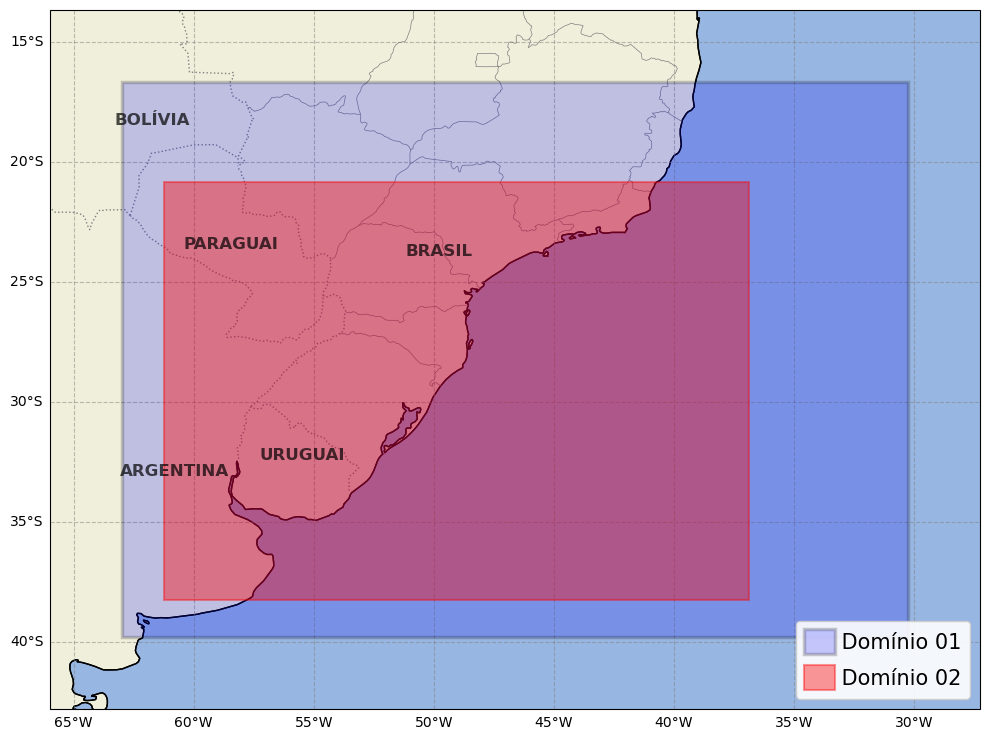

Concluído.


In [53]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Polygon, Patch
import cartopy.io.shapereader as shapereader
import numpy as np
from shapely.geometry import box

# ==============================================================================
# CONFIGURAÇÃO - USUÁRIO
# ==============================================================================
# Caminho para os seus arquivos geo_em gerados pelo WPS
file_d01 = '/home/jovyan/privado/Build_WRF/WPS-4.6.0/geo_em.d01.nc'
file_d02 = '/home/jovyan/privado/Build_WRF/WPS-4.6.0/geo_em.d02.nc'

# Buffer (borda extra) em graus ao redor do d01 para visualização
buffer_deg = 3.0
# ==============================================================================

def get_wrf_projections(ds):
    """
    Lê os atributos globais do NetCDF do WRF e retorna a projeção Cartopy nativa.
    """
    map_proj = ds.attrs['MAP_PROJ']
    stand_lon = ds.attrs['STAND_LON']
    moad_cen_lat = ds.attrs['MOAD_CEN_LAT']
    
    data_crs = ccrs.PlateCarree()
    
    if map_proj == 1:
        plot_crs = ccrs.LambertConformal(
            central_longitude=stand_lon, 
            central_latitude=moad_cen_lat,
            standard_parallels=(ds.attrs['TRUELAT1'], ds.attrs['TRUELAT2'])
        )
    elif map_proj == 2:
        plot_crs = ccrs.NorthPolarStereo(
            central_longitude=stand_lon,
            true_scale_latitude=ds.attrs['TRUELAT1']
        )
    elif map_proj == 3:
        plot_crs = ccrs.Mercator(
            central_longitude=stand_lon, 
            latitude_true_scale=moad_cen_lat
        )
    else:
        raise ValueError(f"Projeção MAP_PROJ={map_proj} não suportada.")
        
    return plot_crs, data_crs

def get_domain_corners(ds):
    """
    Extrai as coordenadas (Lat/Lon) dos 4 cantos do domínio mass (stagger M).
    """
    lats = ds['XLAT_M'].isel(Time=0).values
    lons = ds['XLONG_M'].isel(Time=0).values
    
    lon_corners = [lons[0,0], lons[0,-1], lons[-1,-1], lons[-1,0], lons[0,0]]
    lat_corners = [lats[0,0], lats[0,-1], lats[-1,-1], lats[-1,0], lats[0,0]]
    
    return np.array(list(zip(lon_corners, lat_corners)))

# ------------------------------------------------------------------------------
# PROCESSAMENTO PRINCIPAL
# ------------------------------------------------------------------------------
print("Lendo arquivos WRF...")
try:
    ds1 = xr.open_dataset(file_d01)
    ds2 = xr.open_dataset(file_d02)
except FileNotFoundError as e:
    print(f"\nERRO CRÍTICO: Arquivo não encontrado. Verifique os caminhos.\n{e}")
    exit(1)

# Extração de dados da grade
wrf_p_crs, wrf_d_crs = get_wrf_projections(ds1)
corners_d01 = get_domain_corners(ds1)
corners_d02 = get_domain_corners(ds2)

# Configuração da Figura
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Camadas base do mapa
ax.add_feature(cfeature.OCEAN.with_scale('50m'), zorder=0)
ax.add_feature(cfeature.LAND.with_scale('50m'), edgecolor='black', zorder=1)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle=':', edgecolor='gray', zorder=2)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), zorder=2)

states_provinces = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lines',
    scale='50m', facecolor='none'
)
ax.add_feature(states_provinces, edgecolor='gray', linewidth=0.5, zorder=2)

# 1. Desenho do Domínio 01 (Sombreado azul, borda preta grossa)
print("Desenhando d01...")
poly_d01 = Polygon(
    corners_d01, facecolor='blue', alpha=0.2, edgecolor='black', 
    linewidth=2.5, transform=wrf_d_crs, zorder=4
)
ax.add_patch(poly_d01)

# 2. Desenho do Domínio 02 (Sombreado vermelho, borda vermelha)
print("Desenhando d02...")
poly_d02 = Polygon(
    corners_d02, facecolor='red', alpha=0.4, edgecolor='red', 
    linewidth=1.5, transform=wrf_d_crs, zorder=5
)
ax.add_patch(poly_d02)

# 3. Configuração de Zoom e Extensão (+3 graus buffer)
print(f"Configurando zoom (+{buffer_deg} graus)...")
lon_min, lat_min = corners_d01.min(axis=0)
lon_max, lat_max = corners_d01.max(axis=0)

ax.set_extent(
    [lon_min - buffer_deg, lon_max + buffer_deg, lat_min - buffer_deg, lat_max + buffer_deg], 
    crs=wrf_d_crs
)

# 4. Adicionar NOMES DOS PAÍSES (Corrigido com Ajuste Manual de Posição)
print("Adicionando nomes dos países visíveis...")
shpfilename = shapereader.natural_earth(resolution='50m', category='cultural', name='admin_0_countries')
reader = shapereader.Reader(shpfilename)
countries = reader.records()

current_extent = ax.get_extent(crs=wrf_d_crs)
extent_box = box(current_extent[0], current_extent[2], current_extent[1], current_extent[3])

for country in countries:
    name = country.attributes.get('NAME_PT', country.attributes.get('NAME', ''))
    
    try:
        if country.geometry.intersects(extent_box):
            visible_geom = country.geometry.intersection(extent_box)
            
            # Cálculo do centro base
            minx, miny, maxx, maxy = visible_geom.bounds
            lon_c = (minx + maxx) / 2.0
            lat_c = (miny + maxy) / 2.0
            
            # --- Configuração do Ajuste Manual (Offset) ---
            lon_offset = 0.0
            lat_offset = 0.0
            
            # Oportunidade de Melhoria: Separar as legendas do Rio da Prata
            # Empurramos o Uruguai para Leste (+0.3) e Norte (+0.3)
            if name == 'Uruguai':
                lon_offset = 0.3
                lat_offset = 0.3
            # Empurramos a Argentina para Oeste (-1.0) e Sul (-0.5)
            elif name == 'Argentina':
                lon_offset = -1.0
                lat_offset = -0.5
            # --- Fim do Ajuste Manual ---

            # Plota o texto usando o offset calculado
            ax.text(
                lon_c + lon_offset, lat_c + lat_offset, name.upper(), transform=wrf_d_crs,
                ha='center', va='center', fontsize=12, color='black',
                fontweight='bold', alpha=0.7, zorder=10
            )
            
    except Exception as e:
        print(f"Aviso: Ignorando rótulo para '{name}' -> Erro: {e}")
        continue
# 5. Linhas de Grade
gl = ax.gridlines(
    draw_labels=True, dms=True, x_inline=False, y_inline=False,
    linestyle='--', color='gray', alpha=0.5, zorder=3
)
gl.top_labels = False
gl.right_labels = False

legend_handles = [
    Patch(facecolor='blue', alpha=0.2, edgecolor='black', linewidth=2.5, label=' Domínio 01'),
    Patch(facecolor='red', alpha=0.4, edgecolor='red', linewidth=1.5, label=' Domínio 02')
]
ax.legend(
    handles=legend_handles, loc='lower right', framealpha=0.9, 
    handlelength=1.5, handleheight=1.5, handletextpad=0, fontsize=15
)

# 7. Finalização e Exportação
output_name = 'grade_wrf_tcc.png'
print(f"Salvando imagem: {output_name}")
plt.savefig(output_name, dpi=300, bbox_inches='tight')
plt.show()
print("Concluído.")

=== INICIANDO CRUZAMENTO (OBS vs WRF vs MPAS) | Estação: A858 ===
Extraindo dados WRF (Média 3x3)...
Extraindo dados MPAS (Média 3x3)...

--- DIAGNÓSTICO DE SINCRONIZAÇÃO TEMPORAL ---
[OBS INMET] 48 registros | Início: 2023-08-11 00:00:00 | Fim: 2023-08-12 23:00:00
[MODELO WRF] 43 registros | Início: 2023-08-11 00:00:00 | Fim: 2023-08-12 18:00:00
[MODELO MPAS] 43 registros | Início: 2023-08-11 00:00:00 | Fim: 2023-08-12 18:00:00
---------------------------------------------
Gerando gráfico unificado...

Concluído! Gráfico final salvo em: /home/jovyan/privado/Saidas/Comparacao_Modelos/grafico_validacao_COMPLET_A858_3x3.png


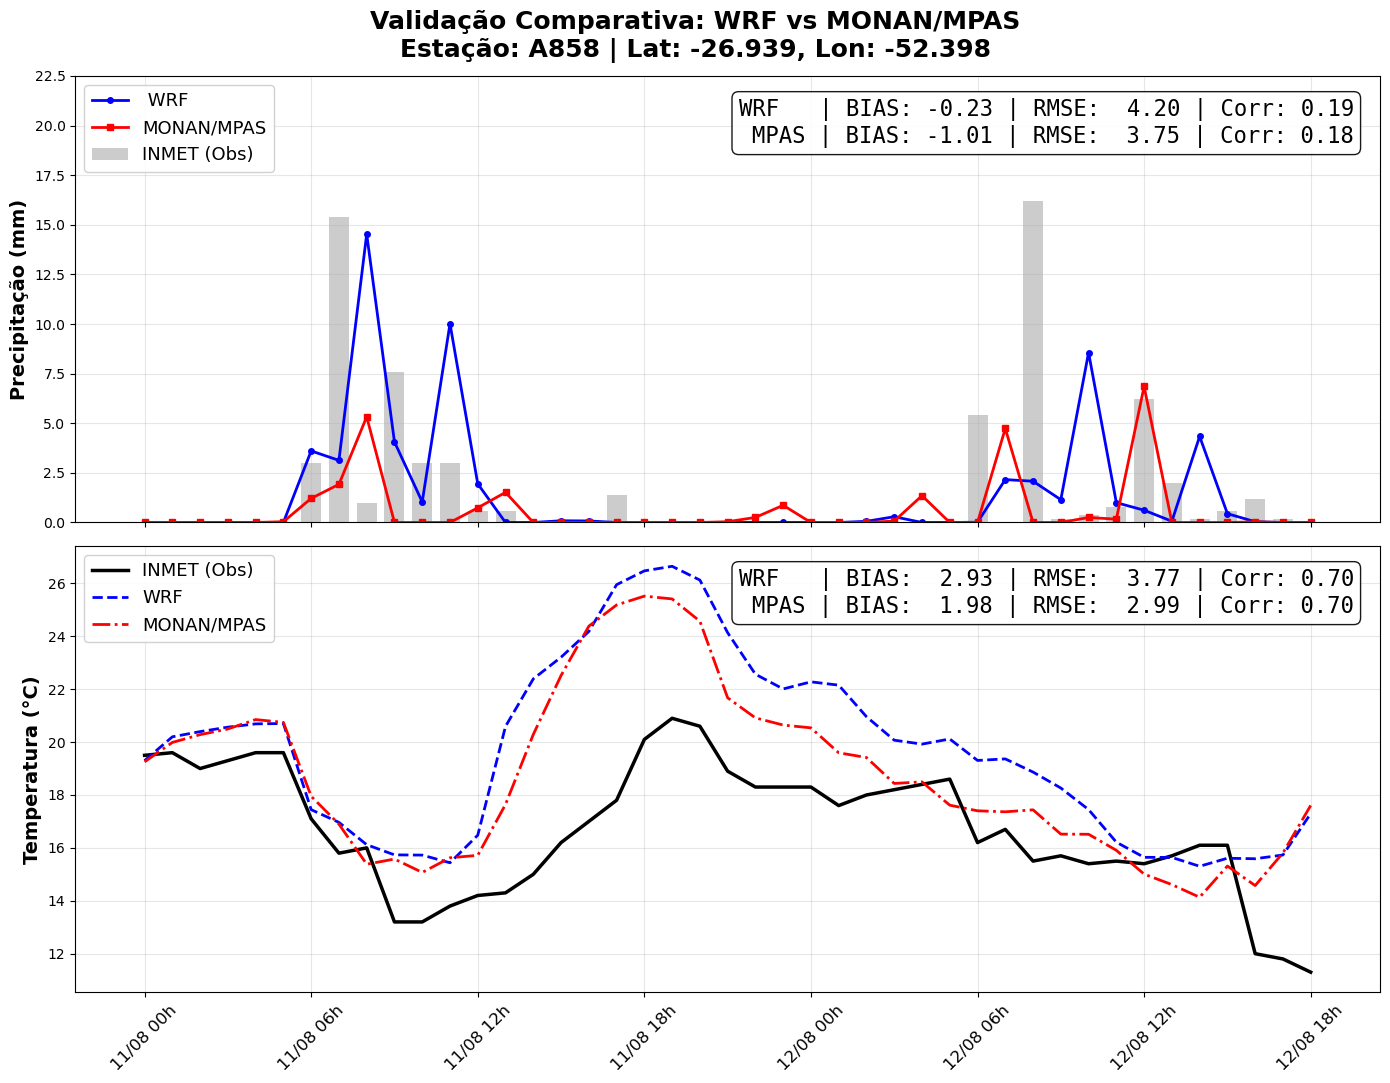

In [78]:
#Estações 3x3 MONAN vs WRF
import os
import glob
import sys
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import gc

# Ignorar avisos
warnings.filterwarnings("ignore")

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================
ESTACOES_DIR = '/home/jovyan/privado/Estações INMET/Estações2023'

# Diretórios dos Modelos
MODEL_DIR_WRF = '/home/jovyan/compartilhado/Paulo/20230811.2'
MODEL_DIR_MPAS = '/home/jovyan/privado/MONAN/202308'

WRF_PATTERN = 'wrfout_d02*' 
DATA_INICIO = '2023-08-11'
DATA_FIM = '2023-08-12'

# Escolha a estação alvo (ex: A816 ou A895)
ESTACAO_ALVO = 'A858' 

# Configuração de Saída
DIR_SAIDA_IMAGENS = '/home/jovyan/privado/Saidas/Comparacao_Modelos'
NOME_ARQUIVO_SAIDA = os.path.join(DIR_SAIDA_IMAGENS, f'grafico_validacao_COMPLET_{ESTACAO_ALVO}_3x3.png')

LIMITES_FISICOS = {
    'temp': (-80, 60), 
    'prec': (0, 500)
}

# ==============================================================================
# 2. FUNÇÕES AUXILIARES
# ==============================================================================

# --- ESTAÇÃO INMET ---
def encontrar_arquivo_estacao(diretorio, codigo):
    padrao = os.path.join(diretorio, f'*{codigo}*.CSV')
    arquivos = glob.glob(padrao)
    if not arquivos:
        padrao = os.path.join(diretorio, f'*{codigo}*.csv')
        arquivos = glob.glob(padrao)
    return arquivos[0] if arquivos else None

def carregar_dados_estacao(caminho_arquivo):
    try:
        with open(caminho_arquivo, 'r', encoding='latin-1') as f:
            linhas = f.readlines()
            lat = float(linhas[4].split(';')[1].replace(',', '.'))
            lon = float(linhas[5].split(';')[1].replace(',', '.'))

        df = pd.read_csv(
            caminho_arquivo, sep=';', skiprows=8, decimal=',',
            encoding='latin-1', engine='python', na_values=['-9999', 'null', '', 'nan']
        )
        
        if 'Data' in df.columns and 'Hora UTC' in df.columns:
            df['Data'] = df['Data'].astype(str).str.replace('/', '-')
            df['Hora UTC'] = df['Hora UTC'].astype(str).str.replace(' UTC', '').str.replace(':', '').str.strip().str.zfill(4)
            datetime_str = df['Data'] + ' ' + df['Hora UTC']
            df['datetime'] = pd.to_datetime(datetime_str, format='%Y-%m-%d %H%M', errors='coerce')
        else:
            df['datetime'] = pd.to_datetime(df.iloc[:,0], errors='coerce')

        df = df.dropna(subset=['datetime']).set_index('datetime').sort_index()
        df.index = df.index.round('1h')
        if df.index.tz is not None: df.index = df.index.tz_localize(None)
        
        df = df[DATA_INICIO:DATA_FIM]

        cols_map = {
            'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'prec_obs',
            'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'temp_obs'
        }
        cols = {k: v for k, v in cols_map.items() if k in df.columns}
        df = df[cols.keys()].rename(columns=cols)
        
        for c in df.columns: df[c] = pd.to_numeric(df[c], errors='coerce')
        return df, lat, lon
    except Exception as e:
        print(f"Erro ao ler estação: {e}")
        return None, None, None

# --- MODELO WRF ---
def obter_indices_wrf(arquivo_exemplo, lat_alvo, lon_alvo):
    try:
        with xr.open_dataset(arquivo_exemplo) as ds:
            if 'XLAT' in ds:
                lats = ds['XLAT'].isel(Time=0).values
                lons = ds['XLONG'].isel(Time=0).values
            else:
                lats = ds['XLAT_M'].values
                lons = ds['XLONG_M'].values
            
            dist = (lats - lat_alvo)**2 + (lons - lon_alvo)**2
            idx_min = dist.argmin()
            iy, ix = np.unravel_index(idx_min, dist.shape)
            
            ny, nx = lats.shape
            if iy < 1 or iy > ny-2 or ix < 1 or ix > nx-2:
                print("ERRO WRF: Estação muito próxima da borda do domínio.")
                return None, None
            return int(iy), int(ix)
    except Exception as e:
        print(f"Erro WRF índices: {e}")
        return None, None

def extrair_dados_wrf_iterativo(arquivos, iy, ix):
    print("Extraindo dados WRF (Média 3x3)...")
    dados_list = []
    slice_y = slice(iy - 1, iy + 2)
    slice_x = slice(ix - 1, ix + 2)
    
    for arq in arquivos:
        try:
            with xr.open_dataset(arq) as ds:
                bloco = ds.isel(south_north=slice_y, west_east=slice_x, Time=0)
                t2_mean = float(bloco['T2'].mean().values) - 273.15
                rain_total_grid = bloco['RAINC'] + bloco['RAINNC']
                rain_acum_mean = float(rain_total_grid.mean().values)
                
                # --- TRATAMENTO DE TEMPO CORRIGIDO (O GARGALO) ---
                raw_val = ds['Times'].isel(Time=0).values
                
                # Desempacota array de bytes do WRF
                if isinstance(raw_val, np.ndarray):
                    if raw_val.size > 1:
                        time_str = b''.join(raw_val).decode('utf-8')
                    else:
                        val = raw_val.item()
                        time_str = val.decode('utf-8') if isinstance(val, bytes) else str(val)
                elif isinstance(raw_val, bytes):
                    time_str = raw_val.decode('utf-8')
                else:
                    time_str = str(raw_val)
                
                # Limpeza final de segurança: remove o 'b', aspas e troca o underline por espaço
                time_str = time_str.replace("b'", "").replace("'", "").replace("_", " ")
                # -------------------------------------------------
                
                dados_list.append({
                    'datetime': pd.to_datetime(time_str),
                    'temp_wrf': t2_mean,
                    'rain_acum_wrf': rain_acum_mean
                })
        except Exception as e:
            print(f"Aviso: Erro ao ler arquivo {os.path.basename(arq)} -> {e}")
            continue
            
    if not dados_list: return pd.DataFrame() 
    
    df = pd.DataFrame(dados_list).set_index('datetime').sort_index()
    df = df[~df.index.duplicated(keep='first')]
    
    # Cálculo da chuva horária do WRF
    df['prec_wrf'] = df['rain_acum_wrf'].diff().fillna(0).clip(lower=0)
    
    return df[['temp_wrf', 'prec_wrf']]
# --- MODELO MONAN/MPAS ---
def extrair_dados_mpas_3x3(diretorio_modelo, lat_alvo, lon_alvo):
    print("Extraindo dados MPAS (Média 3x3)...")
    try:
        ds = xr.open_mfdataset(os.path.join(diretorio_modelo, '*.nc'), combine='by_coords', engine='netcdf4')
        
        if 'longitude' in ds.coords and ds['longitude'].max() > 180:
            ds.coords['longitude'] = (ds.coords['longitude'] + 180) % 360 - 180
            ds = ds.sortby('longitude')
        
        lats = ds['latitude'].values
        lons = ds['longitude'].values
        lat_idx = np.abs(lats - lat_alvo).argmin()
        lon_idx = np.abs(lons - lon_alvo).argmin()
        
        if lat_idx < 1 or lat_idx >= len(lats)-1 or lon_idx < 1 or lon_idx >= len(lons)-1:
            print("ERRO MPAS: Estação muito próxima da borda.")
            return pd.DataFrame()

        vizinhanca = ds.isel(latitude=slice(lat_idx - 1, lat_idx + 2), longitude=slice(lon_idx - 1, lon_idx + 2))
        subset = vizinhanca[['t2m', 'prec']].load()
        
        temp_area_mean = subset['t2m'].mean(dim=['latitude', 'longitude']) - 273.15
        prec_area_mean = subset['prec'].mean(dim=['latitude', 'longitude'])
        
        df_mod = pd.DataFrame({
            'temp_mpas': temp_area_mean.values,
            'prec_acum_mpas': prec_area_mean.values
        }, index=pd.to_datetime(subset.Time.values))
        
        df_mod = df_mod[~df_mod.index.duplicated(keep='first')]
        df_mod['prec_mpas'] = df_mod['prec_acum_mpas'].diff().fillna(0).clip(lower=0)
        
        return df_mod[['temp_mpas', 'prec_mpas']]
    except Exception as e:
        print(f"Erro MPAS: {e}")
        return pd.DataFrame()

# --- ESTATÍSTICAS ---
def calcular_stats(obs, mod):
    # Se uma das séries estiver zerada e o std for zero, correlação vira NaN. Tratamos isso.
    diff = mod - obs
    bias = diff.mean()
    rmse = np.sqrt((diff**2).mean())
    corr = obs.corr(mod)
    if pd.isna(corr): corr = 0.0
    return bias, rmse, corr

# ==============================================================================
# 3. ROTINA PRINCIPAL
# ==============================================================================
if __name__ == "__main__":
    gc.collect()
    
    if not os.path.exists(DIR_SAIDA_IMAGENS): os.makedirs(DIR_SAIDA_IMAGENS, exist_ok=True)
    
    print(f"=== INICIANDO CRUZAMENTO (OBS vs WRF vs MPAS) | Estação: {ESTACAO_ALVO} ===")
    
    # 1. ESTAÇÃO INMET
    arq_estacao = encontrar_arquivo_estacao(ESTACOES_DIR, ESTACAO_ALVO)
    if not arq_estacao: sys.exit("Estação não encontrada.")
    df_obs, lat, lon = carregar_dados_estacao(arq_estacao)
    if df_obs is None or df_obs.empty: sys.exit("Sem dados na estação.")

    # 2. WRF
    arquivos_wrf = sorted(glob.glob(os.path.join(MODEL_DIR_WRF, WRF_PATTERN)))
    if not arquivos_wrf: sys.exit("Sem arquivos WRF.")
    iy, ix = obter_indices_wrf(arquivos_wrf[0], lat, lon)
    df_wrf = extrair_dados_wrf_iterativo(arquivos_wrf, iy, ix) if iy is not None else pd.DataFrame()
    if not df_wrf.empty:
        df_wrf.index = df_wrf.index.round('1h')
        if df_wrf.index.tz is not None: df_wrf.index = df_wrf.index.tz_localize(None)

    # 3. MPAS
    df_mpas = extrair_dados_mpas_3x3(MODEL_DIR_MPAS, lat, lon)
    if not df_mpas.empty:
        df_mpas.index = df_mpas.index.round('1h')
        if df_mpas.index.tz is not None: df_mpas.index = df_mpas.index.tz_localize(None)

    # 4. # 4. MERGE TOTAL E DIAGNÓSTICO
    print("\n--- DIAGNÓSTICO DE SINCRONIZAÇÃO TEMPORAL ---")
    
    # Verifica a Estação
    if not df_obs.empty:
        print(f"[OBS INMET] {len(df_obs)} registros | Início: {df_obs.index.min()} | Fim: {df_obs.index.max()}")
    else:
        print("[OBS INMET] VAZIO!")

    # Verifica o WRF
    if not df_wrf.empty:
        print(f"[MODELO WRF] {len(df_wrf)} registros | Início: {df_wrf.index.min()} | Fim: {df_wrf.index.max()}")
    else:
        print("[MODELO WRF] VAZIO! (Falha na extração ou arquivos não encontrados)")

    # Verifica o MPAS
    if not df_mpas.empty:
        print(f"[MODELO MPAS] {len(df_mpas)} registros | Início: {df_mpas.index.min()} | Fim: {df_mpas.index.max()}")
    else:
        print("[MODELO MPAS] VAZIO! (Falha na extração do NetCDF)")
    
    print("---------------------------------------------")

    # Executa o cruzamento flexível (Outer Join para não perder dados prematuramente)
    df_final = df_obs.copy()
    if not df_wrf.empty: df_final = df_final.join(df_wrf, how='outer')
    if not df_mpas.empty: df_final = df_final.join(df_mpas, how='outer')
    
    # Remove as linhas onde não há dado de precipitação do modelo (simulando o inner join com segurança)
    if 'prec_wrf' in df_final.columns and 'prec_mpas' in df_final.columns:
        df_final = df_final.dropna(subset=['prec_wrf', 'prec_mpas'])
        
    if df_final.empty:
        print("\n[ERRO CRÍTICO] Após alinhar os horários, o resultado foi zero.")
        print("Visualização das primeiras 5 linhas do DataFrame desalinhado (antes do corte):")
        
        # Faz um join outer cru apenas para imprimir e você ver o desalinhamento
        df_debug = df_obs.copy().join(df_wrf, how='outer').join(df_mpas, how='outer')
        print(df_debug[['prec_obs', 'prec_wrf', 'prec_mpas']].head(10))
        
        sys.exit("\nExecute novamente e analise a tabela acima.")

    # 5. PLOTAGEM
    print("Gerando gráfico unificado...")
    fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)
    
    # Configurações de cores: WRF (Azul/Ciano), MPAS (Vermelho/Laranja)
    configs = [
        ('Precipitação', 'prec_obs', 'prec_wrf', 'prec_mpas', 'mm', 'blue', 'red'),
        ('Temperatura', 'temp_obs', 'temp_wrf', 'temp_mpas', '°C', 'blue', 'red')
    ]

    for i, (nome, obs_col, wrf_col, mpas_col, unid, cor_wrf, cor_mpas) in enumerate(configs):
        ax = axes[i]
        
        if obs_col in df_final:
            lim = LIMITES_FISICOS[nome.lower()[:4]]
            df_p = df_final[
                (df_final[obs_col].between(lim[0], lim[1])) & 
                (df_final[wrf_col].between(lim[0], lim[1])) &
                (df_final[mpas_col].between(lim[0], lim[1]))
            ]
            
            if df_p.empty:
                ax.text(0.5, 0.5, "Sem dados válidos", ha='center', transform=ax.transAxes); continue

            # Estatísticas WRF e MPAS
            bw, rw, cw = calcular_stats(df_p[obs_col], df_p[wrf_col])
            bm, rm, cm = calcular_stats(df_p[obs_col], df_p[mpas_col])
            
            stats_str = (
                f"WRF   | BIAS: {bw:5.2f} | RMSE: {rw:5.2f} | Corr: {cw:4.2f}\n"
                f"MPAS | BIAS: {bm:5.2f} | RMSE: {rm:5.2f} | Corr: {cm:4.2f}"
            )
            
            # Plotagem das Séries
            if nome == 'Precipitação':
                ax.bar(df_p.index, df_p[obs_col], color='gray', alpha=0.4, label='INMET (Obs)', width=0.03)
                ax.plot(df_p.index, df_p[wrf_col], color=cor_wrf, label=' WRF', linewidth=2, marker='o', markersize=4)
                ax.plot(df_p.index, df_p[mpas_col], color=cor_mpas, label='MONAN/MPAS', linewidth=2, marker='s', markersize=4)
                ax.set_ylim(0, max(22.5, df_p[[obs_col, wrf_col, mpas_col]].max().max() * 1.2)) # Dinâmico com mínimo de 22.5
            else:
                ax.plot(df_p.index, df_p[obs_col], 'k-', label='INMET (Obs)', linewidth=2.5)
                ax.plot(df_p.index, df_p[wrf_col], color=cor_wrf, label='WRF', linewidth=2, linestyle='--')
                ax.plot(df_p.index, df_p[mpas_col], color=cor_mpas, label='MONAN/MPAS', linewidth=2, linestyle='-.')

            ax.set_ylabel(f"{nome} ({unid})", fontweight='bold', fontsize=14)
            ax.legend(loc='upper left', fontsize=13, framealpha=0.9)
            ax.grid(True, alpha=0.3)
            
            # Caixa de texto de estatísticas com fonte monoespaçada para alinhar a tabela
            ax.text(0.98, 0.95, stats_str, transform=ax.transAxes, 
                    ha='right', va='top', bbox=dict(boxstyle="round", fc="w", alpha=0.9), 
                    fontsize=16, family='monospace')

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %Hh'))
    plt.xticks(rotation=45, fontsize=12)
    plt.suptitle(f"Validação Comparativa: WRF vs MONAN/MPAS\nEstação: {ESTACAO_ALVO} | Lat: {lat:.3f}, Lon: {lon:.3f}", fontsize=18, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.savefig(NOME_ARQUIVO_SAIDA, dpi=300)
    print(f"\nConcluído! Gráfico final salvo em: {NOME_ARQUIVO_SAIDA}")

=== INICIANDO CRUZAMENTO MULTIVARIADO | Estação: A858 ===
Extraindo dados WRF...
Extraindo dados MPAS...
Gerando painel com 5 variáveis...

Concluído! Gráfico salvo em: /home/jovyan/privado/Saidas/Comparacao_Modelos/grafico_validacao_5VAR_Q2_A858_3x3.png


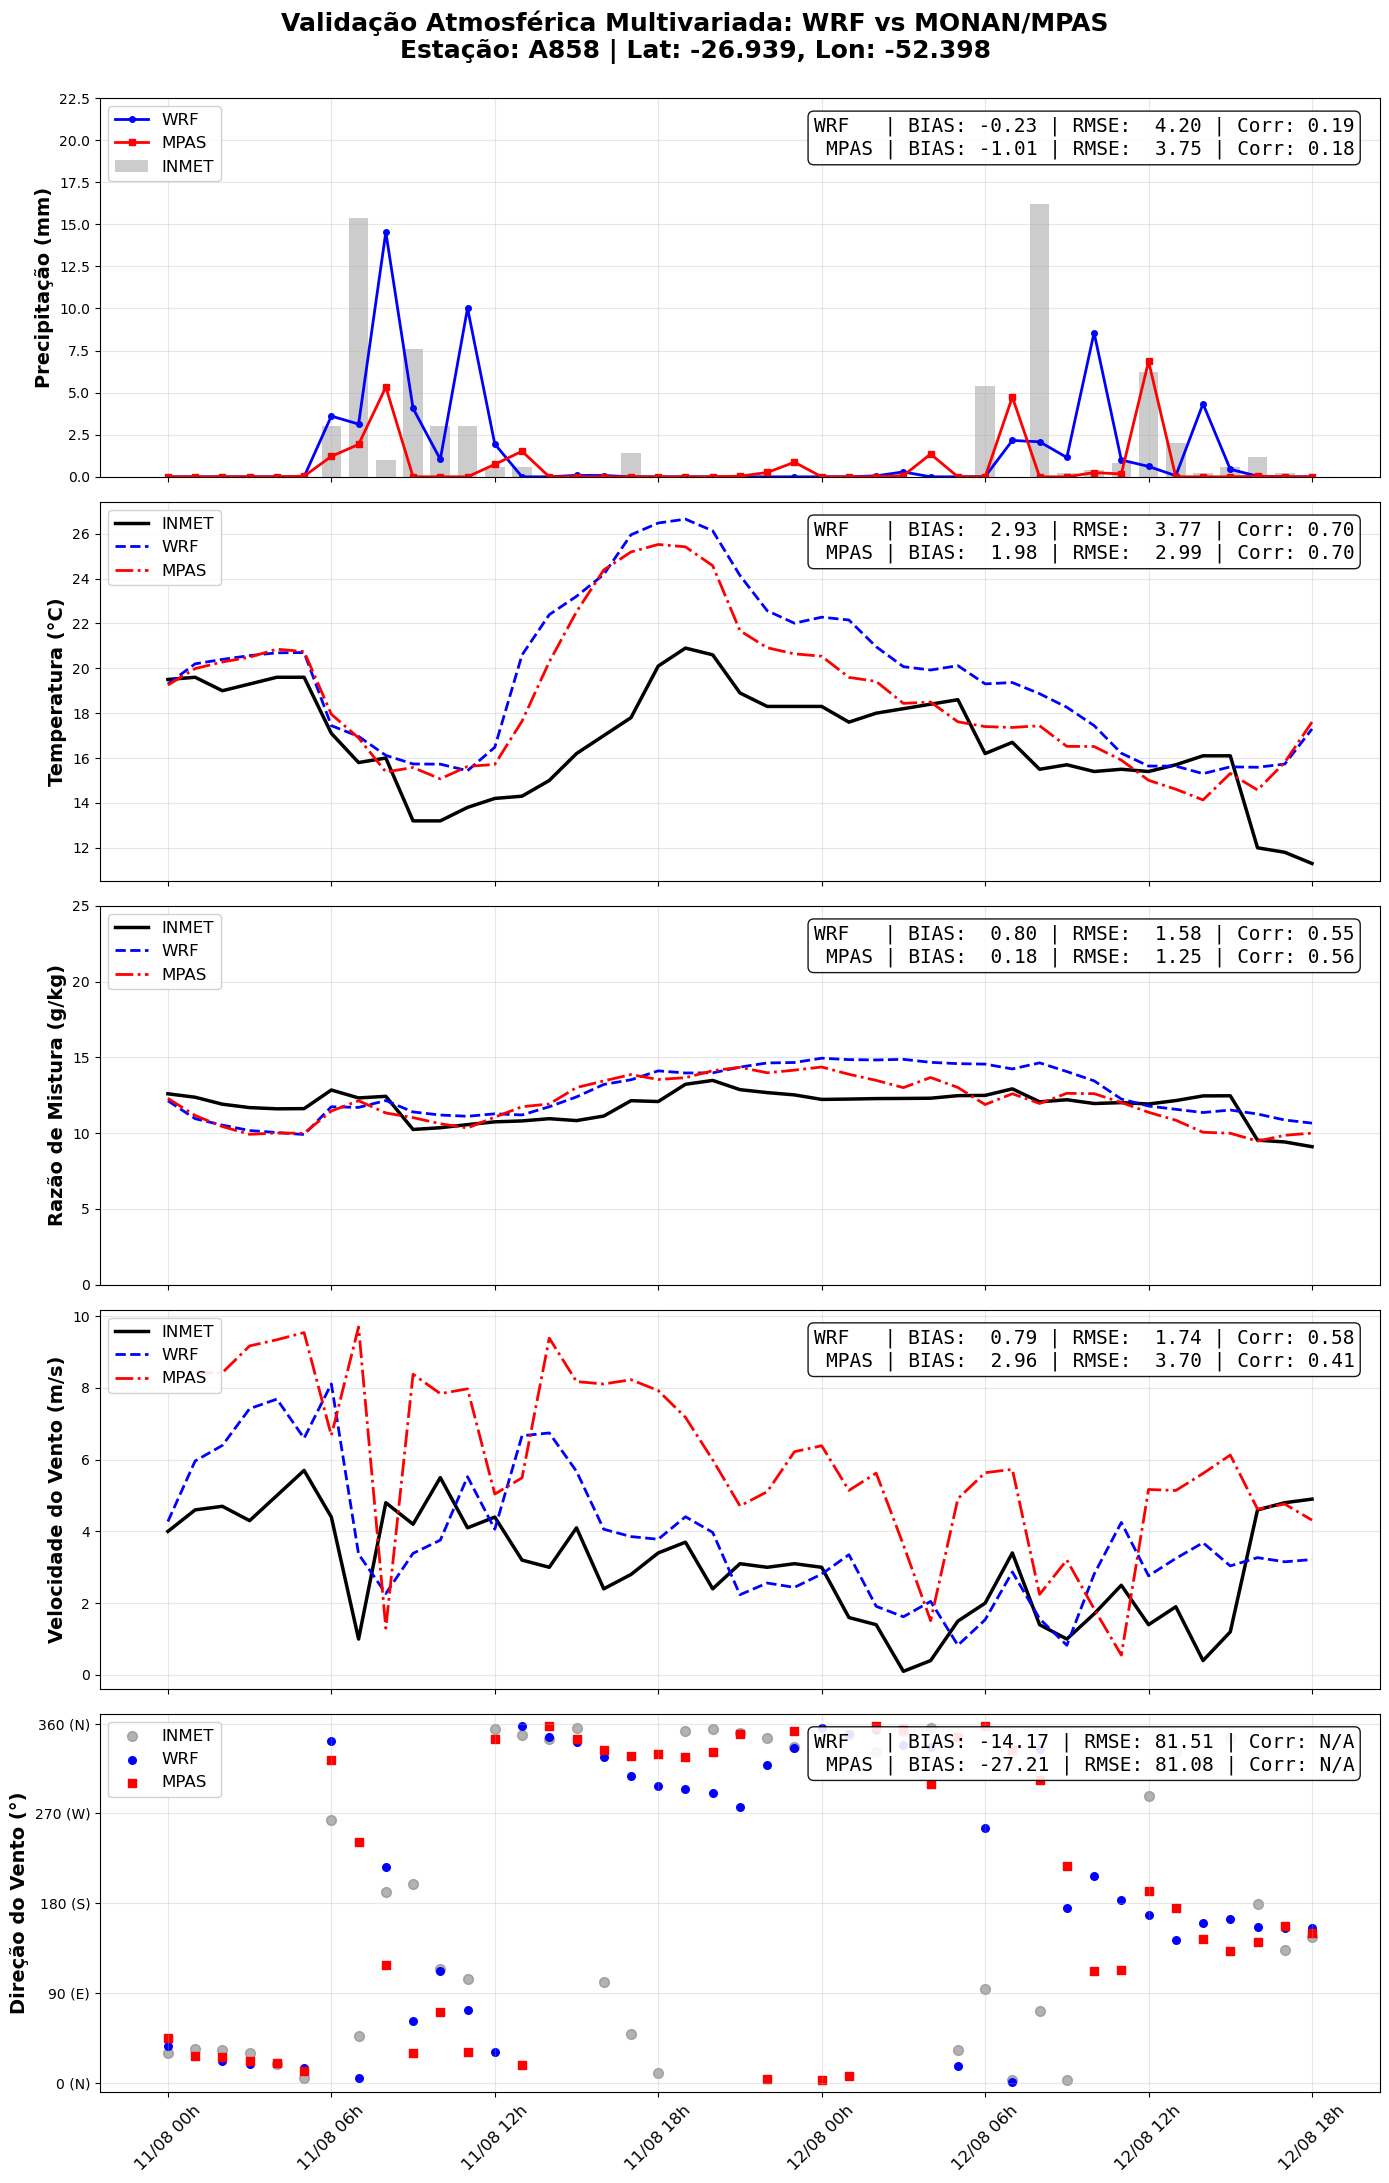

In [80]:
import os
import glob
import sys
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import gc

# Ignorar avisos
warnings.filterwarnings("ignore")

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================
ESTACOES_DIR = '/home/jovyan/privado/Estações INMET/Estações2023'
MODEL_DIR_WRF = '/home/jovyan/compartilhado/Paulo/20230811.2'
MODEL_DIR_MPAS = '/home/jovyan/privado/MONAN/202308'

WRF_PATTERN = 'wrfout_d02*'
DATA_INICIO = '2023-08-11'
DATA_FIM = '2023-08-12'

ESTACAO_ALVO = 'A858'

DIR_SAIDA_IMAGENS = '/home/jovyan/privado/Saidas/Comparacao_Modelos'
NOME_ARQUIVO_SAIDA = os.path.join(DIR_SAIDA_IMAGENS, f'grafico_validacao_5VAR_Q2_{ESTACAO_ALVO}_3x3.png')

LIMITES_FISICOS = {
    'prec': (0, 500),
    'temp': (-10, 50),
    'q2':   (0, 25),
    'velo': (0, 40),
    'dire': (-10, 370)
}

# ==============================================================================
# 2. FUNÇÕES AUXILIARES
# ==============================================================================
def encontrar_arquivo_estacao(diretorio, codigo):
    padrao = os.path.join(diretorio, f'*{codigo}*.CSV')
    arquivos = glob.glob(padrao)
    if not arquivos: arquivos = glob.glob(os.path.join(diretorio, f'*{codigo}*.csv'))
    return arquivos[0] if arquivos else None

def carregar_dados_estacao(caminho_arquivo):
    try:
        with open(caminho_arquivo, 'r', encoding='latin-1') as f:
            linhas = f.readlines()
            lat = float(linhas[4].split(';')[1].replace(',', '.'))
            lon = float(linhas[5].split(';')[1].replace(',', '.'))

        df = pd.read_csv(
            caminho_arquivo, sep=';', skiprows=8, decimal=',',
            encoding='latin-1', engine='python', na_values=['-9999', 'null', '', 'nan']
        )

        if 'Data' in df.columns and 'Hora UTC' in df.columns:
            df['Data'] = df['Data'].astype(str).str.replace('/', '-')
            df['Hora UTC'] = df['Hora UTC'].astype(str).str.replace(' UTC', '').str.replace(':', '').str.strip().str.zfill(4)
            df['datetime'] = pd.to_datetime(df['Data'] + ' ' + df['Hora UTC'], format='%Y-%m-%d %H%M', errors='coerce')
        else:
            df['datetime'] = pd.to_datetime(df.iloc[:,0], errors='coerce')

        df = df.dropna(subset=['datetime']).set_index('datetime').sort_index()
        df.index = df.index.round('1h').tz_localize(None)
        df = df[DATA_INICIO:DATA_FIM]

        cols_map = {
            'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'prec_obs',
            'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'temp_obs',
            'UMIDADE RELATIVA DO AR, HORARIA (%)': 'umid_obs',
            'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)': 'pres_obs',
            'VENTO, VELOCIDADE HORARIA (m/s)': 'velo_obs',
            'VENTO, DIREÇÃO HORARIA (gr) (° (gr))': 'dire_obs'
        }
        cols = {k: v for k, v in cols_map.items() if k in df.columns}
        df = df[cols.keys()].rename(columns=cols)
        for c in df.columns: df[c] = pd.to_numeric(df[c], errors='coerce')

        if 'pres_obs' not in df.columns: df['pres_obs'] = 950.0

        if 'temp_obs' in df.columns and 'umid_obs' in df.columns:
            es = 6.112 * np.exp((17.67 * df['temp_obs']) / (df['temp_obs'] + 243.5))
            e = (df['umid_obs'] / 100.0) * es
            df['q2_obs'] = (0.622 * e / (df['pres_obs'] - 0.378 * e)) * 1000
        else:
            df['q2_obs'] = np.nan

        # Sanitiza infinitos gerados por divisões problemáticas
        df.replace([np.inf, -np.inf], np.nan, inplace=True)

        return df, lat, lon
    except Exception as e:
        print(f"Erro ao ler estação: {e}")
        return None, None, None

def obter_indices_wrf(arquivo_exemplo, lat_alvo, lon_alvo):
    try:
        with xr.open_dataset(arquivo_exemplo) as ds:
            lats = ds['XLAT'].isel(Time=0).values if 'XLAT' in ds else ds['XLAT_M'].values
            lons = ds['XLONG'].isel(Time=0).values if 'XLONG' in ds else ds['XLONG_M'].values
            dist = (lats - lat_alvo)**2 + (lons - lon_alvo)**2
            iy, ix = np.unravel_index(dist.argmin(), dist.shape)
            return int(iy), int(ix)
    except Exception as e:
        print(f"Erro WRF índices: {e}")
        return None, None

def extrair_dados_wrf_iterativo(arquivos, iy, ix):
    print("Extraindo dados WRF...")
    dados_list = []
    slice_y = slice(iy - 1, iy + 2)
    slice_x = slice(ix - 1, ix + 2)

    for arq in arquivos:
        try:
            with xr.open_dataset(arq) as ds:
                bloco = ds.isel(south_north=slice_y, west_east=slice_x, Time=0)

                t2_mean = float(bloco['T2'].mean().values) - 273.15
                rain_acum_mean = float((bloco['RAINC'] + bloco['RAINNC']).mean().values)

                u10 = float(bloco['U10'].mean().values)
                v10 = float(bloco['V10'].mean().values)
                ws_wrf = np.sqrt(u10**2 + v10**2)
                wd_wrf = (270 - np.rad2deg(np.arctan2(v10, u10))) % 360

                q2_wrf = float(bloco['Q2'].mean().values) * 1000

                raw_val = ds['Times'].isel(Time=0).values
                time_str = b''.join(raw_val).decode('utf-8') if isinstance(raw_val, np.ndarray) and raw_val.size > 1 else (raw_val.item().decode('utf-8') if isinstance(raw_val, np.ndarray) else (raw_val.decode('utf-8') if isinstance(raw_val, bytes) else str(raw_val)))
                time_str = time_str.replace("b'", "").replace("'", "").replace("_", " ")

                dados_list.append({'datetime': pd.to_datetime(time_str), 'temp_wrf': t2_mean, 'rain_acum_wrf': rain_acum_mean, 'q2_wrf': q2_wrf, 'velo_wrf': ws_wrf, 'dire_wrf': wd_wrf})
        except Exception:
            continue

    if not dados_list: return pd.DataFrame()
    df = pd.DataFrame(dados_list).set_index('datetime').sort_index()
    df = df[~df.index.duplicated(keep='first')]
    df['prec_wrf'] = df['rain_acum_wrf'].diff().fillna(0).clip(lower=0)

    # Sanitiza infinitos
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    return df[['temp_wrf', 'prec_wrf', 'q2_wrf', 'velo_wrf', 'dire_wrf']]

def extrair_dados_mpas_3x3(diretorio_modelo, lat_alvo, lon_alvo):
    print("Extraindo dados MPAS...")
    try:
        ds = xr.open_mfdataset(os.path.join(diretorio_modelo, '*.nc'), combine='by_coords', engine='netcdf4')
        if 'longitude' in ds.coords and ds['longitude'].max() > 180:
            ds.coords['longitude'] = (ds.coords['longitude'] + 180) % 360 - 180
            ds = ds.sortby('longitude')

        lats = ds['latitude'].values
        lons = ds['longitude'].values
        lat_idx, lon_idx = np.abs(lats - lat_alvo).argmin(), np.abs(lons - lon_alvo).argmin()
        vizinhanca = ds.isel(latitude=slice(lat_idx - 1, lat_idx + 2), longitude=slice(lon_idx - 1, lon_idx + 2))

        df_mod = pd.DataFrame(index=pd.to_datetime(vizinhanca.Time.values))

        if 't2m' in vizinhanca: df_mod['temp_mpas'] = vizinhanca['t2m'].mean(dim=['latitude', 'longitude']).values - 273.15
        else: df_mod['temp_mpas'] = np.nan

        if 'prec' in vizinhanca: df_mod['prec_acum_mpas'] = vizinhanca['prec'].mean(dim=['latitude', 'longitude']).values
        else: df_mod['prec_acum_mpas'] = np.nan

        if 'u10' in vizinhanca and 'v10' in vizinhanca:
            u10 = vizinhanca['u10'].mean(dim=['latitude', 'longitude']).values
            v10 = vizinhanca['v10'].mean(dim=['latitude', 'longitude']).values
            df_mod['velo_mpas'] = np.sqrt(u10**2 + v10**2)
            df_mod['dire_mpas'] = (270 - np.rad2deg(np.arctan2(v10, u10))) % 360
        else:
            df_mod['velo_mpas'], df_mod['dire_mpas'] = np.nan, np.nan

        if 'q2' in vizinhanca:
            df_mod['q2_mpas'] = vizinhanca['q2'].mean(dim=['latitude', 'longitude']).values * 1000
        else:
            df_mod['q2_mpas'] = np.nan

        df_mod = df_mod[~df_mod.index.duplicated(keep='first')]
        if 'prec_acum_mpas' in df_mod: df_mod['prec_mpas'] = df_mod['prec_acum_mpas'].diff().fillna(0).clip(lower=0)

        # ✅ CORREÇÃO: sanitiza infinitos gerados por cálculos com dados inválidos
        df_mod.replace([np.inf, -np.inf], np.nan, inplace=True)

        cols_final = [c for c in ['temp_mpas', 'prec_mpas', 'q2_mpas', 'velo_mpas', 'dire_mpas'] if c in df_mod.columns]
        return df_mod[cols_final]
    except Exception as e:
        print(f"Erro fatal ao processar MPAS: {e}")
        return pd.DataFrame()

# ✅ CORREÇÃO PRINCIPAL: filtro de NaN + inf simultâneo nas duas séries
def calcular_stats(obs, mod, is_wd=False):
    # Filtro robusto "Pairwise": exclui NaN e infinitos nas duas séries ao mesmo tempo
    valid = (
        ~np.isnan(obs) & ~np.isnan(mod) &
        ~np.isinf(obs) & ~np.isinf(mod)
    )

    # Exige no mínimo 2 pontos válidos para não dar erro na correlação de Pearson
    if valid.sum() < 2:
        return np.nan, np.nan, np.nan

    obs_val = obs[valid]
    mod_val = mod[valid]

    if is_wd:
        diff = (mod_val - obs_val + 180) % 360 - 180
        return diff.mean(), np.sqrt((diff**2).mean()), np.nan
    else:
        diff = mod_val - obs_val
        corr = obs_val.corr(mod_val)
        return diff.mean(), np.sqrt((diff**2).mean()), 0.0 if pd.isna(corr) else corr

# ==============================================================================
# 3. ROTINA PRINCIPAL
# ==============================================================================
if __name__ == "__main__":
    gc.collect()
    if not os.path.exists(DIR_SAIDA_IMAGENS): os.makedirs(DIR_SAIDA_IMAGENS, exist_ok=True)
    print(f"=== INICIANDO CRUZAMENTO MULTIVARIADO | Estação: {ESTACAO_ALVO} ===")

    arq_estacao = encontrar_arquivo_estacao(ESTACOES_DIR, ESTACAO_ALVO)
    df_obs, lat, lon = carregar_dados_estacao(arq_estacao)

    arquivos_wrf = sorted(glob.glob(os.path.join(MODEL_DIR_WRF, WRF_PATTERN)))
    iy, ix = obter_indices_wrf(arquivos_wrf[0], lat, lon)
    df_wrf = extrair_dados_wrf_iterativo(arquivos_wrf, iy, ix) if iy is not None else pd.DataFrame()
    if not df_wrf.empty: df_wrf.index = df_wrf.index.round('1h').tz_localize(None)

    df_mpas = extrair_dados_mpas_3x3(MODEL_DIR_MPAS, lat, lon)
    if not df_mpas.empty: df_mpas.index = df_mpas.index.round('1h').tz_localize(None)

    df_final = df_obs.copy()
    if not df_wrf.empty: df_final = df_final.join(df_wrf, how='outer')
    if not df_mpas.empty: df_final = df_final.join(df_mpas, how='outer')

    cols_modelo = [c for c in ['prec_wrf', 'prec_mpas'] if c in df_final.columns]
    if cols_modelo: df_final = df_final.dropna(subset=cols_modelo, how='all')

    print("Gerando painel com 5 variáveis...")
    fig, axes = plt.subplots(5, 1, figsize=(14, 22), sharex=True)

    configs = [
        ('Precipitação', 'prec_obs', 'prec_wrf', 'prec_mpas', 'mm', 'bar', 'prec'),
        ('Temperatura', 'temp_obs', 'temp_wrf', 'temp_mpas', '°C', 'line', 'temp'),
        ('Razão de Mistura', 'q2_obs', 'q2_wrf', 'q2_mpas', 'g/kg', 'line', 'q2'),
        ('Velocidade do Vento', 'velo_obs', 'velo_wrf', 'velo_mpas', 'm/s', 'line', 'velo'),
        ('Direção do Vento', 'dire_obs', 'dire_wrf', 'dire_mpas', '°', 'scatter', 'dire')
    ]

    for i, (nome, obs_col, wrf_col, mpas_col, unid, tipo_grafico, lim_key) in enumerate(configs):
        ax = axes[i]

        if obs_col in df_final:
            tem_wrf = wrf_col in df_final.columns
            tem_mpas = mpas_col in df_final.columns

            lim = LIMITES_FISICOS[lim_key]
            df_p = df_final[(df_final[obs_col].between(lim[0], lim[1]))]
            if df_p.empty:
                ax.text(0.5, 0.5, "Sem dados de observação", ha='center', transform=ax.transAxes); continue

            is_wd = (nome == 'Direção do Vento')

            stats_str = ""
            if tem_wrf:
                bw, rw, cw = calcular_stats(df_p[obs_col], df_p[wrf_col], is_wd)
                stats_str += f"WRF   | BIAS: {bw:5.2f} | RMSE: {rw:5.2f} | Corr: {'N/A' if is_wd else f'{cw:4.2f}'}\n"
            if tem_mpas:
                bm, rm, cm = calcular_stats(df_p[obs_col], df_p[mpas_col], is_wd)
                stats_str += f"MPAS | BIAS: {bm:5.2f} | RMSE: {rm:5.2f} | Corr: {'N/A' if is_wd else f'{cm:4.2f}'}"

            if tipo_grafico == 'bar':
                ax.bar(df_p.index, df_p[obs_col], color='gray', alpha=0.4, label='INMET', width=0.03)
                if tem_wrf: ax.plot(df_p.index, df_p[wrf_col], color='blue', label='WRF', lw=2, marker='o', ms=4)
                if tem_mpas: ax.plot(df_p.index, df_p[mpas_col], color='red', label='MPAS', lw=2, marker='s', ms=4)
                max_val = df_p[[obs_col]].max().max()
                if tem_wrf: max_val = max(max_val, df_p[[wrf_col]].max().max())
                if tem_mpas: max_val = max(max_val, df_p[[mpas_col]].max().max())
                ax.set_ylim(0, max(22.5, max_val * 1.2))

            elif tipo_grafico == 'scatter':
                ax.scatter(df_p.index, df_p[obs_col], color='gray', label='INMET', alpha=0.6, s=50)
                if tem_wrf: ax.scatter(df_p.index, df_p[wrf_col], color='blue', label='WRF', marker='o', s=30)
                if tem_mpas: ax.scatter(df_p.index, df_p[mpas_col], color='red', label='MPAS', marker='s', s=30)
                ax.set_ylim(-10, 370)
                ax.set_yticks([0, 90, 180, 270, 360])
                ax.set_yticklabels(['0 (N)', '90 (E)', '180 (S)', '270 (W)', '360 (N)'])

            else:
                ax.plot(df_p.index, df_p[obs_col], 'k-', label='INMET', lw=2.5)
                if tem_wrf: ax.plot(df_p.index, df_p[wrf_col], color='blue', label='WRF', lw=2, ls='--')
                if tem_mpas: ax.plot(df_p.index, df_p[mpas_col], color='red', label='MPAS', lw=2, ls='-.')
                if lim_key == 'q2': ax.set_ylim(0, 25)

            ax.set_ylabel(f"{nome} ({unid})", fontweight='bold', fontsize=14)
            ax.legend(loc='upper left', fontsize=12, framealpha=0.9)
            ax.grid(True, alpha=0.3)

            if stats_str:
                ax.text(0.98, 0.95, stats_str, transform=ax.transAxes, ha='right', va='top', bbox=dict(boxstyle="round", fc="w", alpha=0.9), fontsize=14, family='monospace')

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %Hh'))
    plt.xticks(rotation=45, fontsize=12)
    plt.suptitle(f"Validação Atmosférica Multivariada: WRF vs MONAN/MPAS\nEstação: {ESTACAO_ALVO} | Lat: {lat:.3f}, Lon: {lon:.3f}", fontsize=18, fontweight='bold', y=0.99)
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.savefig(NOME_ARQUIVO_SAIDA, dpi=300)
    print(f"\nConcluído! Gráfico salvo em: {NOME_ARQUIVO_SAIDA}")